# Face Modification with Generative Models

## Cell 1: Setup and Data Utilities

Imports, Config class, CelebA Dataset with attribute filtering, data loaders, training logger, and visualization functions.

In [1]:
# %pip install matplotlib
# %pip install torch torchvision

# ============================================================================
# IMPORTS
# ============================================================================
import os
import json
from pathlib import Path
from datetime import datetime
from typing import Optional, List, Tuple, Dict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, datasets
from torchvision.utils import save_image, make_grid

import matplotlib.pyplot as plt

# ============================================================================
# CONFIGURATION
# ============================================================================

class Config:
    """Global configuration for all models"""
    
    # Data Configuration
    DATA_ROOT = './data'
    IMAGE_SIZE = 64
    IMAGE_CHANNELS = 3
    
    # Model Configuration
    LATENT_DIM = 128
    
    # Training Configuration
    BATCH_SIZE = 128
    NUM_WORKERS = 0  # Set to 0 for Jupyter notebooks (2-4 for scripts)
    LEARNING_RATE = 1e-4
    
    # Directory Configuration
    CHECKPOINT_DIR = './checkpoints'
    LOG_DIR = './logs'
    SAMPLE_DIR = './samples'
    
    @staticmethod
    def setup_directories():
        """Create necessary directories"""
        for directory in [Config.CHECKPOINT_DIR, Config.LOG_DIR, Config.SAMPLE_DIR]:
            Path(directory).mkdir(parents=True, exist_ok=True)

# ============================================================================
# DATASET UTILITIES
# ============================================================================

class CelebADataset(Dataset):
    """Enhanced CelebA Dataset with attribute filtering"""
    
    # CelebA attribute names
    ATTR_NAMES = [
        '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes',
        'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair',
        'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin',
        'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones',
        'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard',
        'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline',
        'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair',
        'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace',
        'Wearing_Necktie', 'Young'
    ]
    
    def __init__(
        self,
        root: str = Config.DATA_ROOT,
        split: str = 'train',
        image_size: int = Config.IMAGE_SIZE,
        transform: Optional[transforms.Compose] = None,
        target_attributes: Optional[List[str]] = None,
        attribute_values: Optional[List[int]] = None
    ):
        """
        Initialize CelebA dataset with optional attribute filtering.
        
        Args:
            root: Root directory of dataset
            split: One of 'train', 'valid', or 'test'
            image_size: Target image size (64 or 128)
            transform: Image transformations (uses default if None)
            target_attributes: List of attribute names to filter by
            attribute_values: Corresponding values for each attribute (0 or 1)
        
        Example:
            dataset = CelebADataset(
                image_size=128,
                target_attributes=['Smiling'],
                attribute_values=[1]
            )
        """
        self.root = root
        self.split = split
        self.image_size = image_size
        self.attr_names = self.ATTR_NAMES
        
        # Setup transform
        self.transform = transform or self._get_default_transform(image_size)
        
        # Verify dataset exists
        self._verify_dataset()
        
        # Load dataset
        self.dataset = self._load_dataset()
        
        # Apply attribute filtering
        self.indices = self._filter_by_attributes(target_attributes, attribute_values)
    
    def _get_default_transform(self, image_size: int) -> transforms.Compose:
        """Get default image transformation pipeline"""
        return transforms.Compose([
            transforms.Resize(image_size),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
        ])
    
    def _verify_dataset(self):
        """Verify that dataset files exist"""
        data_path = Path(self.root) / 'celeba'
        required_files = ['img_align_celeba', 'list_attr_celeba.txt', 'list_eval_partition.txt']
        missing_files = [f for f in required_files if not (data_path / f).exists()]
        
        if missing_files:
            error_msg = (
                f"\n{'='*80}\n"
                f"❌ CelebA Dataset Not Found!\n"
                f"{'='*80}\n"
                f"Missing: {', '.join(missing_files)}\n\n"
                f"📋 DOWNLOAD INSTRUCTIONS:\n"
                f"1. Visit: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset\n"
                f"2. Download and extract to: {data_path.absolute()}\n"
                f"{'='*80}\n"
            )
            raise FileNotFoundError(error_msg)
    
    def _load_dataset(self):
        """Load CelebA dataset using torchvision"""
        try:
            return datasets.CelebA(
                root=self.root,
                split=self.split,
                target_type='attr',
                download=False,
                transform=self.transform
            )
        except Exception as e:
            error_msg = (
                f"\n{'='*80}\n"
                f"❌ Error loading CelebA: {str(e)}\n"
                f"{'='*80}\n"
            )
            raise RuntimeError(error_msg) from e
    
    def _filter_by_attributes(
        self,
        target_attributes: Optional[List[str]],
        attribute_values: Optional[List[int]]
    ) -> List[int]:
        """Filter dataset indices by attribute values"""
        if target_attributes is None:
            return list(range(len(self.dataset)))
        
        if len(target_attributes) != len(attribute_values):
            raise ValueError("target_attributes and attribute_values must have same length")
        
        # Get attribute indices
        attr_indices = [self.attr_names.index(attr) for attr in target_attributes]
        
        # Filter indices
        return [
            i for i in range(len(self.dataset))
            if all(self.dataset[i][1][idx] == val for idx, val in zip(attr_indices, attribute_values))
        ]
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, attrs = self.dataset[real_idx]
        return img, attrs

# ============================================================================
# DATA LOADER
# ============================================================================

def get_celeba_dataloader(
    split: str = 'train',
    batch_size: int = Config.BATCH_SIZE,
    shuffle: bool = True,
    target_attributes: Optional[List[str]] = None,
    attribute_values: Optional[List[int]] = None,
    image_size: int = Config.IMAGE_SIZE
) -> DataLoader:
    """
    Get a DataLoader for CelebA dataset with optional attribute filtering.
    
    Args:
        split: One of 'train', 'valid', or 'test'
        batch_size: Batch size for the dataloader
        shuffle: Whether to shuffle the data
        target_attributes: List of attribute names to filter by
        attribute_values: Corresponding values for each attribute (0 or 1)
        image_size: Image size (64 or 128)
    
    Returns:
        DataLoader: PyTorch DataLoader object
    
    Example:
        # Load all training data
        train_loader = get_celeba_dataloader(split='train')
        
        # Load smiling faces
        smiling_loader = get_celeba_dataloader(
            target_attributes=['Smiling'],
            attribute_values=[1]
        )
    """
    dataset = CelebADataset(
        split=split,
        image_size=image_size,
        target_attributes=target_attributes,
        attribute_values=attribute_values
    )
    
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=Config.NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def get_device() -> torch.device:
    """Get the best available device (CUDA > MPS > CPU)"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    elif torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')


def count_parameters(model: nn.Module) -> int:
    """Count total trainable parameters in a model"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
# ============================================================================
# TRAINING LOGGER
# ============================================================================

class TrainingLogger:
    """Unified logging for all model training"""
    
    def __init__(self, model_name: str, experiment_name: Optional[str] = None):
        """
        Initialize training logger.
        
        Args:
            model_name: Name of the model (e.g., 'VAE', 'BetaVAE')
            experiment_name: Optional experiment name (uses timestamp if None)
        """
        self.model_name = model_name
        self.experiment_name = experiment_name or datetime.now().strftime("%Y%m%d_%H%M%S")
        self.start_time = datetime.now()
        self.timestamp = self.start_time.strftime("%Y%m%d_%H%M%S")
        
        # Setup directories
        self.exp_dir = Path(Config.LOG_DIR) / model_name / self.experiment_name
        self.sample_dir = self.exp_dir / 'samples'
        self.checkpoint_dir = self.exp_dir / 'checkpoints'
        
        for directory in [self.exp_dir, self.sample_dir, self.checkpoint_dir]:
            directory.mkdir(parents=True, exist_ok=True)
        
        # Initialize metrics storage
        self.batch_losses = []
        self.epoch_metrics = {}
        
        print(f"📂 Logging to: {self.exp_dir}")
    
    def log_batch_loss(self, loss: float):
        """Log loss for a single batch"""
        self.batch_losses.append(loss)
    
    def log_metrics(self, epoch: int, metrics: Dict[str, float]):
        """Log metrics for an epoch"""
        for key, value in metrics.items():
            if key not in self.epoch_metrics:
                self.epoch_metrics[key] = []
            self.epoch_metrics[key].append(value)
        
        # Print progress
        metrics_str = " | ".join([f"{k}: {v:.4f}" for k, v in metrics.items()])
        print(f"Epoch {epoch}: {metrics_str}")
    
    def save_samples(self, epoch: int, images: torch.Tensor, nrow: int = 8):
        """Save sample images"""
        save_image(
            images,
            self.sample_dir / f'epoch_{epoch:04d}.png',
            nrow=nrow,
            normalize=True,
            value_range=(0, 1)
        )
    
    def save_reconstructions(self, epoch: int, originals: torch.Tensor, reconstructions: torch.Tensor):
        """Save original and reconstructed images side by side"""
        n = min(len(originals), len(reconstructions))
        comparison = torch.stack([originals[:n], reconstructions[:n]], dim=1).flatten(0, 1)
        
        save_image(
            comparison,
            self.sample_dir / f'recon_epoch_{epoch:04d}.png',
            nrow=n,
            normalize=True,
            value_range=(0, 1)
        )
    
    def save_checkpoint(
        self,
        epoch: int,
        model: nn.Module,
        optimizer: optim.Optimizer,
        metrics: dict = None,
        is_best: bool = False
    ):
        """Save model checkpoint"""
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'metrics': metrics or self.epoch_metrics
        }
        
        # Save regular checkpoint
        checkpoint_path = self.checkpoint_dir / f'checkpoint_epoch_{epoch:04d}.pt'
        torch.save(checkpoint, checkpoint_path)
        
        # Save as best model if applicable
        if is_best:
            best_path = self.checkpoint_dir / 'best_model.pth'
            torch.save(checkpoint, best_path)
            print(f"  💾 Saved best model (epoch {epoch})")
    
    def save_history(self):
        """Save training history to JSON"""
        duration = datetime.now() - self.start_time
        
        history = {
            'model_name': self.model_name,
            'experiment_name': self.experiment_name,
            'duration_seconds': duration.total_seconds(),
            'epoch_metrics': self.epoch_metrics,
            'batch_losses': self.batch_losses,
            'timestamp': self.timestamp
        }
        
        history_path = self.exp_dir / 'training_history.json'
        with open(history_path, 'w') as f:
            json.dump(history, f, indent=2)
        
        print(f"💾 Training history saved to {history_path}")
    
    def plot_losses(self):
        """Plot and save training curves"""
        if not self.epoch_metrics:
            return
        
        num_metrics = len(self.epoch_metrics)
        fig, axes = plt.subplots(1, num_metrics, figsize=(6 * num_metrics, 4))
        
        if num_metrics == 1:
            axes = [axes]
        
        for ax, (metric_name, values) in zip(axes, self.epoch_metrics.items()):
            ax.plot(values, linewidth=2)
            ax.set_title(f'{metric_name}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.set_ylabel(metric_name)
            ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plot_path = self.exp_dir / 'training_curves.png'
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        plt.close()
        
        print(f"📊 Training curves saved to {plot_path}")

# ============================================================================
# INITIALIZATION
# ============================================================================

Config.setup_directories()
device = get_device()

print("="*80)
print("✓ Setup Complete")
print("="*80)
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
print(f"Data root: {Config.DATA_ROOT}")
print(f"Latent dim: {Config.LATENT_DIM}")
print(f"Batch size: {Config.BATCH_SIZE}")
print("="*80)

# ============================================================================
# DATA VISUALIZATION FUNCTIONS
# ============================================================================

def show_training_samples():
    """Load and visualize all training data"""
    print("\n" + "="*80)
    print("Example 1: Load all training data")
    print("="*80)
    
    train_loader = get_celeba_dataloader(split='train', batch_size=64)
    print(f"✓ Total batches: {len(train_loader)}")
    
    images, attributes = next(iter(train_loader))
    print(f"✓ Batch shape: {images.shape}")
    print(f"✓ Attributes shape: {attributes.shape}")
    
    # Visualize
    grid = make_grid(images[:16], nrow=4, normalize=True)
    plt.figure(figsize=(10, 10))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.title('Sample Training Images', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("="*80)


def show_smiling_faces():
    """Load and visualize filtered data (smiling faces)"""
    print("\n" + "="*80)
    print("Example 2: Filtered data (smiling faces)")
    print("="*80)
    
    smiling_loader = get_celeba_dataloader(
        split='train',
        batch_size=64,
        target_attributes=['Smiling'],
        attribute_values=[1]
    )
    print(f"✓ Total smiling face batches: {len(smiling_loader)}")
    
    images, _ = next(iter(smiling_loader))
    grid = make_grid(images[:16], nrow=4, normalize=True)
    plt.figure(figsize=(10, 10))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.title('Smiling Faces', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("="*80)


def show_filtered_samples():
    """Multiple attribute filtering (young males with glasses)"""
    print("\n" + "="*80)
    print("Example 3: Young males with glasses")
    print("="*80)
    
    complex_loader = get_celeba_dataloader(
        split='train',
        batch_size=64,
        target_attributes=['Young', 'Male', 'Eyeglasses'],
        attribute_values=[1, 1, 1]
    )
    print(f"✓ Total filtered batches: {len(complex_loader)}")
    
    images, _ = next(iter(complex_loader))
    grid = make_grid(images[:16], nrow=4, normalize=True)
    plt.figure(figsize=(10, 10))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.title('Young Males with Glasses', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("="*80)


print("\n✓ Visualization functions available:")
print("  - show_training_samples()")
print("  - show_smiling_faces()")
print("  - show_filtered_samples()")
print("\nReady for model training!")


✓ Setup Complete
PyTorch version: 2.10.0
Device: mps
Data root: ./data
Latent dim: 128
Batch size: 128

✓ Visualization functions available:
  - show_training_samples()
  - show_smiling_faces()
  - show_filtered_samples()

Ready for model training!


## Cell 2: Convolutional VAE

ConvVAE and Beta-VAE models with encoder/decoder architecture, training function, latent space interpolation, and face generation utilities.

In [2]:
# ============================================================================
# CONVOLUTIONAL VAE (Beta-VAE)
# ============================================================================
# ============================================================================
# CONVOLUTIONAL VAE MODEL
# ============================================================================

class ConvVAE(nn.Module):
    """
    Convolutional Variational Autoencoder with Beta parameter.
    Supports 64x64 RGB images (CelebA).
    
    Architecture:
        - Encoder: 64x64 -> 2x2 (5 conv layers with stride 2)
        - Latent space: Gaussian distribution
        - Decoder: 2x2 -> 64x64 (5 transposed conv layers)
    """
    
    def __init__(
        self,
        latent_dim: int = Config.LATENT_DIM,
        input_channels: int = Config.IMAGE_CHANNELS,
        hidden_dims: List[int] = None
    ):
        """
        Initialize ConvVAE.
        
        Args:
            latent_dim: Dimension of latent space (default: 128)
            input_channels: Number of input channels (default: 3 for RGB)
            hidden_dims: List of hidden dimensions for conv layers
        """
        super(ConvVAE, self).__init__()
        
        self.latent_dim = latent_dim
        self.hidden_dims = hidden_dims or [32, 64, 128, 256, 512]
        
        # Build encoder
        self.encoder = self._build_encoder(input_channels)
        
        # Calculate flattened size: 64/(2^5) = 2x2
        self.flatten_size = self.hidden_dims[-1] * 2 * 2
        
        # Latent space projection
        self.fc_mu = nn.Linear(self.flatten_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_size, latent_dim)
        
        # Build decoder
        self.decoder_input = nn.Linear(latent_dim, self.flatten_size)
        self.decoder = self._build_decoder(input_channels)
    
    def _build_encoder(self, input_channels: int) -> nn.Sequential:
        """Build encoder network"""
        layers = []
        in_channels = input_channels
        
        for h_dim in self.hidden_dims:
            layers.append(nn.Sequential(
                nn.Conv2d(in_channels, h_dim, kernel_size=3, stride=2, padding=1),
                nn.BatchNorm2d(h_dim),
                nn.LeakyReLU(0.2)
            ))
            in_channels = h_dim
        
        return nn.Sequential(*layers)
    
    def _build_decoder(self, input_channels: int) -> nn.Sequential:
        """Build decoder network"""
        layers = []
        hidden_dims_reversed = self.hidden_dims[::-1]
        
        # Hidden layers
        for i in range(len(hidden_dims_reversed) - 1):
            layers.append(nn.Sequential(
                nn.ConvTranspose2d(
                    hidden_dims_reversed[i],
                    hidden_dims_reversed[i + 1],
                    kernel_size=3,
                    stride=2,
                    padding=1,
                    output_padding=1
                ),
                nn.BatchNorm2d(hidden_dims_reversed[i + 1]),
                nn.LeakyReLU(0.2)
            ))
        
        # Output layer
        layers.append(nn.Sequential(
            nn.ConvTranspose2d(
                hidden_dims_reversed[-1],
                input_channels,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.Sigmoid()
        ))
        
        return nn.Sequential(*layers)
    
    def encode(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """Encode input to latent distribution parameters (mu, logvar)"""
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)
    
    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        """Reparameterization trick: z = mu + sigma * epsilon"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """Decode latent vector to image"""
        h = self.decoder_input(z)
        h = h.view(h.size(0), self.hidden_dims[-1], 2, 2)
        return self.decoder(h)
    
    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Forward pass: returns (reconstructed, mu, logvar)"""
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar
    
    def sample(self, num_samples: int, device: torch.device) -> torch.Tensor:
        """Sample from prior N(0, I)"""
        z = torch.randn(num_samples, self.latent_dim).to(device)
        return self.decode(z)


# ============================================================================
# VAE LOSS FUNCTION
# ============================================================================

def vae_loss_function(
    recon_x: torch.Tensor,
    x: torch.Tensor,
    mu: torch.Tensor,
    logvar: torch.Tensor,
    beta: float = 1.0
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Beta-VAE loss: Loss = Reconstruction_Loss + beta * KL_Divergence
    
    Args:
        recon_x: Reconstructed images
        x: Original images
        mu: Mean of latent distribution
        logvar: Log variance of latent distribution
        beta: Weight for KL divergence (beta=1 for standard VAE)
    
    Returns:
        (total_loss, reconstruction_loss, kl_divergence)
    """
    # Reconstruction loss (Binary Cross Entropy)
    recon_loss = nn.functional.binary_cross_entropy(
        recon_x.view(-1, 3 * 64 * 64),
        x.view(-1, 3 * 64 * 64),
        reduction='sum'
    )
    
    # KL divergence: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    # Total loss with beta weighting
    return recon_loss + beta * kl_div, recon_loss, kl_div


# ============================================================================
# VAE TRAINING FUNCTION
# ============================================================================


def train_vae(
    model: ConvVAE,
    train_loader: DataLoader,
    num_epochs: int = 50,
    learning_rate: float = Config.LEARNING_RATE,
    beta: float = 1.0,
    device: torch.device = None,
    experiment_name: str = None,
    run_demos: bool = False
):
    """
    Train the VAE model.
    
    Args:
        model: ConvVAE model instance
        train_loader: Training data loader
        num_epochs: Number of training epochs
        learning_rate: Learning rate for optimizer
        beta: Beta parameter for KL divergence weighting (1.0 = standard VAE)
        device: Device to train on (auto-detected if None)
        experiment_name: Name for logging (timestamp if None)
        run_demos: If True, run demonstrations after training
    """
    device = device or get_device()
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Setup logging
    model_name = f'BetaVAE_beta{beta}' if beta != 1.0 else 'VAE'
    logger = TrainingLogger(model_name, experiment_name)
    
    print("\n" + "="*80)
    print(f"Training {model_name}")
    print("="*80)
    print(f"Parameters: {count_parameters(model):,}")
    print(f"Beta: {beta}")
    print(f"Epochs: {num_epochs}")
    print(f"Learning rate: {learning_rate}")
    print(f"Device: {device}")
    print("="*80 + "\n")
    
    best_loss = float('inf')
    
    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss = 0
        train_recon_loss = 0
        train_kl_loss = 0
        
        for batch_idx, (images, _) in enumerate(train_loader):
            images = images.to(device)
            
            # Forward pass
            recon_images, mu, logvar = model(images)
            
            # Compute loss
            loss, recon_loss, kl_loss = vae_loss_function(
                recon_images, images, mu, logvar, beta
            )
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Accumulate losses
            train_loss += loss.item()
            train_recon_loss += recon_loss.item()
            train_kl_loss += kl_loss.item()
            
            # Log batch loss
            logger.log_batch_loss(loss.item() / len(images))
        
        # Average losses
        avg_loss = train_loss / len(train_loader.dataset)
        avg_recon_loss = train_recon_loss / len(train_loader.dataset)
        avg_kl_loss = train_kl_loss / len(train_loader.dataset)
        
        # Log metrics
        metrics = {
            'total_loss': avg_loss,
            'recon_loss': avg_recon_loss,
            'kl_loss': avg_kl_loss
        }
        logger.log_metrics(epoch, metrics)
        
        # Print epoch progress
        print(f"Epoch [{epoch}/{num_epochs}] - Total Loss: {avg_loss:.4f}, "
              f"Recon Loss: {avg_recon_loss:.4f}, KL Loss: {avg_kl_loss:.4f}")
        
        # Save reconstructions and samples
        model.eval()
        with torch.no_grad():
            # Reconstructions
            sample_images = images[:8]
            recon_images, _, _ = model(sample_images)
            logger.save_reconstructions(epoch, sample_images, recon_images)
            
            # Generated samples
            samples = model.sample(64, device)
            logger.save_samples(epoch, samples)
        
        # Save checkpoint
        is_best = avg_loss < best_loss
        if is_best:
            best_loss = avg_loss
        
        if epoch % 10 == 0 or is_best:
            logger.save_checkpoint(epoch, model, optimizer, metrics, is_best)
        
        # Plot losses
        if epoch % 10 == 0:
            logger.plot_losses()
    
    # Save final history
    logger.save_history()
    print(f"\nTraining complete! Best loss: {best_loss:.4f}")
    
    # Run post-training demonstrations if requested
    if run_demos:
        print("\n" + "="*80)
        print("🎨 RUNNING POST-TRAINING DEMONSTRATIONS")
        print("="*80)
        
        demo_dir = logger.exp_dir / 'demonstrations'
        demo_dir.mkdir(exist_ok=True)
        
        try:
            # 1. Reconstructions
            print("\n1️⃣  Generating reconstruction visualization...")
            test_loader = get_celeba_dataloader(split='test', batch_size=8)
            test_images, _ = next(iter(test_loader))
            test_images = test_images.to(device)
            
            model.eval()
            with torch.no_grad():
                recon_images, _, _ = model(test_images)
            
            comparison = torch.cat([test_images, recon_images])
            grid = make_grid(comparison, nrow=8, padding=2, normalize=True)
            
            plt.figure(figsize=(20, 5))
            plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
            plt.axis('off')
            plt.title('Post-Training Reconstructions\nTop: Original | Bottom: Reconstructed', fontsize=14)
            plt.savefig(str(demo_dir / 'final_reconstructions.png'), bbox_inches='tight', dpi=150)
            plt.show()
            print(f"   ✓ Saved to: {demo_dir / 'final_reconstructions.png'}")
            
            # 2. Interpolation
            print("\n2️⃣  Generating latent space interpolation...")
            image1 = test_images[0]
            image2 = test_images[1]
            
            model.eval()
            with torch.no_grad():
                image1_batch = image1.unsqueeze(0).to(device)
                image2_batch = image2.unsqueeze(0).to(device)
                
                mu1, _ = model.encode(image1_batch)
                mu2, _ = model.encode(image2_batch)
                
                alphas = torch.linspace(0, 1, 10).to(device)
                interpolated_images = []
                
                for alpha in alphas:
                    z_interp = (1 - alpha) * mu1 + alpha * mu2
                    recon = model.decode(z_interp)
                    interpolated_images.append(recon.squeeze(0))
                
                interpolated_images = torch.stack(interpolated_images)
            
            grid = make_grid(interpolated_images, nrow=10, padding=2, normalize=True)
            
            plt.figure(figsize=(20, 3))
            plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
            plt.axis('off')
            plt.title('Latent Space Interpolation (10 steps)', fontsize=14)
            plt.savefig(str(demo_dir / 'final_interpolation.png'), bbox_inches='tight', dpi=150)
            plt.show()
            print(f"   ✓ Saved to: {demo_dir / 'final_interpolation.png'}")
            
            # 3. Attribute Modification (Smiling)
            print("\n3️⃣  Computing 'Smiling' attribute vector and generating modifications...")
            
            # Get positive and negative samples
            pos_loader = get_celeba_dataloader(
                split='train', batch_size=64,
                target_attributes=['Smiling'], attribute_values=[1]
            )
            neg_loader = get_celeba_dataloader(
                split='train', batch_size=64,
                target_attributes=['Smiling'], attribute_values=[0]
            )
            
            # Compute attribute vector (simplified for speed)
            pos_latents = []
            neg_latents = []
            
            model.eval()
            with torch.no_grad():
                # Get 200 positive samples
                count = 0
                for images, _ in pos_loader:
                    images = images.to(device)
                    mu, _ = model.encode(images)
                    pos_latents.append(mu)  # Keep on GPU
                    count += len(images)
                    if count >= 200:
                        break
                
                # Get 200 negative samples
                count = 0
                for images, _ in neg_loader:
                    images = images.to(device)
                    mu, _ = model.encode(images)
                    neg_latents.append(mu)  # Keep on GPU
                    count += len(images)
                    if count >= 200:
                        break
            
            pos_mean = torch.cat(pos_latents, dim=0)[:200].mean(dim=0)
            neg_mean = torch.cat(neg_latents, dim=0)[:200].mean(dim=0)
            smile_vector = pos_mean - neg_mean
            
            print(f"   ✓ Attribute vector computed (norm: {smile_vector.norm().item():.4f})")
            
            # Apply to test images
            strengths = [-2, -1, 0, 1, 2]
            test_image = test_images[2]  # Use 3rd test image
            
            modified_images = []
            model.eval()
            with torch.no_grad():
                test_batch = test_image.unsqueeze(0).to(device)
                mu, _ = model.encode(test_batch)
                
                for strength in strengths:
                    z_modified = mu + strength * smile_vector
                    modified = model.decode(z_modified)
                    modified_images.append(modified.squeeze(0))
            
            modified_images = torch.stack(modified_images)
            grid = make_grid(modified_images, nrow=len(strengths), padding=2, normalize=True)
            
            plt.figure(figsize=(15, 3))
            plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
            plt.axis('off')
            title = f'Attribute Modification: Smiling\nStrengths: {strengths}'
            plt.title(title, fontsize=14)
            plt.savefig(str(demo_dir / 'final_attribute_smiling.png'), bbox_inches='tight', dpi=150)
            plt.show()
            print(f"   ✓ Saved to: {demo_dir / 'final_attribute_smiling.png'}")
            
            print("\n" + "="*80)
            print("✅ POST-TRAINING DEMONSTRATIONS COMPLETED!")
            print("="*80)
            print(f"\n📁 All demonstrations saved to: {demo_dir}")
            print("\n🎯 Generated visualizations:")
            print("   1. ✓ Reconstructions (original vs reconstructed)")
            print("   2. ✓ Latent interpolation (smooth transitions)")
            print("   3. ✓ Attribute modification (smiling)")
            
        except Exception as e:
            print(f"\n⚠️  Error during demonstrations: {str(e)}")
            print("   Training completed successfully, but demonstrations failed.")
            import traceback
            traceback.print_exc()
    
    return model, logger


# ============================================================================
# LATENT SPACE MANIPULATION
# ============================================================================

def latent_interpolation(
    model: ConvVAE,
    image1: torch.Tensor,
    image2: torch.Tensor,
    num_steps: int = 10,
    device: torch.device = None
) -> torch.Tensor:
    """
    Perform linear interpolation in latent space between two images
    
    Args:
        model: Trained VAE model
        image1: First image [C, H, W]
        image2: Second image [C, H, W]
        num_steps: Number of interpolation steps
        device: Device to use
    
    Returns:
        Interpolated images [num_steps, C, H, W]
    """
    if device is None:
        device = get_device()
    
    model.eval()
    model = model.to(device)
    
    # Add batch dimension
    image1 = image1.unsqueeze(0).to(device)
    image2 = image2.unsqueeze(0).to(device)
    
    with torch.no_grad():
        # Encode to latent space
        mu1, logvar1 = model.encode(image1)
        mu2, logvar2 = model.encode(image2)
        
        # Use mean (no sampling for deterministic interpolation)
        z1 = mu1
        z2 = mu2
        
        # Linear interpolation
        alphas = torch.linspace(0, 1, num_steps).to(device)
        interpolated_images = []
        
        for alpha in alphas:
            z_interp = (1 - alpha) * z1 + alpha * z2
            recon = model.decode(z_interp)
            interpolated_images.append(recon.squeeze(0))
        
        interpolated_images = torch.stack(interpolated_images)
    
    return interpolated_images


def compute_attribute_vector(
    model: ConvVAE,
    dataloader_positive: DataLoader,
    dataloader_negative: DataLoader,
    num_samples: int = 1000,
    device: torch.device = None
) -> torch.Tensor:
    """
    Compute attribute vector by averaging latent representations
    
    Args:
        model: Trained VAE model
        dataloader_positive: DataLoader with positive attribute (e.g., smiling)
        dataloader_negative: DataLoader with negative attribute (e.g., not smiling)
        num_samples: Number of samples to use for computing average
        device: Device to use
    
    Returns:
        Attribute vector in latent space [latent_dim]
    """
    if device is None:
        device = get_device()
    
    model.eval()
    model = model.to(device)
    
    def get_latent_mean(dataloader, n_samples):
        latents = []
        count = 0
        
        with torch.no_grad():
            for batch in dataloader:
                # Unpack the batch - it returns (images, attributes)
                if isinstance(batch, (list, tuple)) and len(batch) >= 2:
                    images, attributes = batch[0], batch[1]
                elif isinstance(batch, (list, tuple)) and len(batch) == 1:
                    images = batch[0]
                else:
                    images = batch
                
                # Ensure images is a tensor
                if not isinstance(images, torch.Tensor):
                    raise TypeError(f"Expected images to be a tensor, got {type(images)}. "
                                  f"Batch type: {type(batch)}, Batch length: {len(batch) if isinstance(batch, (list, tuple)) else 'N/A'}. "
                                  f"This might indicate an issue with the dataloader or dataset.")
                
                images = images.to(device)
                mu, _ = model.encode(images)
                # Keep on GPU for efficiency - only move final result to CPU if needed
                latents.append(mu)
                count += len(images)
                
                if count >= n_samples:
                    break
        
        if len(latents) == 0:
            raise ValueError(f"No samples found in dataloader. The filtered dataset might be empty.")
        
        latents = torch.cat(latents, dim=0)[:n_samples]
        return latents.mean(dim=0)
    
    # Compute average latent vectors
    print("Computing positive attribute latent mean...")
    z_positive = get_latent_mean(dataloader_positive, num_samples)
    
    print("Computing negative attribute latent mean...")
    z_negative = get_latent_mean(dataloader_negative, num_samples)
    
    # Attribute vector is the difference
    attribute_vector = z_positive - z_negative
    
    print(f"Attribute vector computed: shape {attribute_vector.shape}")
    print(f"Vector norm: {attribute_vector.norm().item():.4f}")
    
    return attribute_vector.to(device)


def apply_attribute_vector(
    model: ConvVAE,
    image: torch.Tensor,
    attribute_vector: torch.Tensor,
    strength: float = 1.0,
    device: torch.device = None
) -> torch.Tensor:
    """
    Apply attribute vector to modify an image
    
    Args:
        model: Trained VAE model
        image: Input image [C, H, W]
        attribute_vector: Attribute vector in latent space [latent_dim]
        strength: Strength of attribute modification (can be negative)
        device: Device to use
    
    Returns:
        Modified image [C, H, W]
    """
    if device is None:
        device = get_device()
    
    model.eval()
    model = model.to(device)
    
    # Add batch dimension
    image = image.unsqueeze(0).to(device)
    
    with torch.no_grad():
        # Encode to latent space
        mu, _ = model.encode(image)
        
        # Apply attribute vector
        z_modified = mu + strength * attribute_vector
        
        # Decode
        modified_image = model.decode(z_modified)
        modified_image = modified_image.squeeze(0)
    
    return modified_image


def attribute_manipulation_demo(
    model: ConvVAE,
    image: torch.Tensor,
    attribute_vector: torch.Tensor,
    strengths: List[float] = None,
    device: torch.device = None
) -> torch.Tensor:
    """
    Demonstrate attribute manipulation with multiple strengths
    
    Args:
        model: Trained VAE model
        image: Input image [C, H, W]
        attribute_vector: Attribute vector
        strengths: List of strengths to apply (e.g., [-3, -2, -1, 0, 1, 2, 3])
        device: Device to use
    
    Returns:
        Grid of modified images [len(strengths), C, H, W]
    """
    if strengths is None:
        strengths = [-3, -2, -1, 0, 1, 2, 3]
    
    if device is None:
        device = get_device()
    
    modified_images = []
    
    for strength in strengths:
        modified = apply_attribute_vector(model, image, attribute_vector, strength, device)
        modified_images.append(modified)
    
    return torch.stack(modified_images)


# ============================================================================
# VISUALIZATION UTILITIES
# ============================================================================

def visualize_interpolation(
    interpolated_images: torch.Tensor,
    save_path: str = None
):
    """Visualize latent interpolation"""
    grid = make_grid(interpolated_images, nrow=len(interpolated_images), padding=2)
    
    plt.figure(figsize=(20, 3))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis('off')
    plt.title('Latent Space Interpolation')
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()


def visualize_attribute_manipulation(
    modified_images: torch.Tensor,
    strengths: List[float],
    attribute_name: str = 'Attribute',
    save_path: str = None
):
    """Visualize attribute manipulation"""
    grid = make_grid(modified_images, nrow=len(modified_images), padding=2)
    
    plt.figure(figsize=(20, 3))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis('off')
    
    # Add strength labels
    for i, strength in enumerate(strengths):
        x_pos = (i + 0.5) / len(strengths)
        plt.text(x_pos, 1.05, f'{strength:+.1f}', 
                transform=plt.gca().transAxes,
                ha='center', fontsize=10)
    
    plt.title(f'{attribute_name} Manipulation')
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

## Cell 2.1: VAE Demonstrations

Functions to load UI-trained models and generate visualizations: reconstructions, latent interpolation, and attribute modification using vector arithmetic.

In [3]:
# ============================================================================
# VAE DEMONSTRATION FUNCTIONS WITH VISUALIZATIONS
# ============================================================================

def find_latest_vae_checkpoint(model_type='VAE', base_dir='./logs'):
    """
    Find the latest trained VAE or Beta-VAE model checkpoint
    
    Args:
        model_type: 'VAE' or 'BetaVAE_beta4' or 'BetaVAE'
        base_dir: Base directory where logs are stored
    
    Returns:
        Path to best_model.pth or None if not found
    """
    from pathlib import Path
    import os
    
    base_path = Path(base_dir) / model_type
    
    if not base_path.exists():
        return None
    
    # Find all timestamp directories
    timestamp_dirs = [d for d in base_path.iterdir() if d.is_dir()]
    
    if not timestamp_dirs:
        return None
    
    # Sort by modification time (most recent first)
    timestamp_dirs.sort(key=lambda x: x.stat().st_mtime, reverse=True)
    
    # Look for best_model.pth in the most recent directory
    for timestamp_dir in timestamp_dirs:
        checkpoint_dir = timestamp_dir / 'checkpoints'
        if checkpoint_dir.exists():
            best_model_path = checkpoint_dir / 'best_model.pth'
            if best_model_path.exists():
                return str(best_model_path)
    
    return None


def load_vae_model(checkpoint_path, latent_dim=128, device=None):
    """
    Load a trained VAE model from checkpoint
    
    Args:
        checkpoint_path: Path to checkpoint file
        latent_dim: Latent dimension (default: 128)
        device: Device to load model on
    
    Returns:
        Loaded VAE model in eval mode
    """
    if device is None:
        device = get_device()
    
    model = ConvVAE(latent_dim=latent_dim)
    
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        
        # Handle different checkpoint formats
        if 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
            print(f"✓ Loaded model from checkpoint (epoch {checkpoint.get('epoch', 'unknown')})")
        elif 'state_dict' in checkpoint:
            model.load_state_dict(checkpoint['state_dict'])
            print(f"✓ Loaded model from checkpoint")
        else:
            model.load_state_dict(checkpoint)
            print(f"✓ Loaded model from checkpoint")
        
        model = model.to(device)
        model.eval()
        
        return model
    
    except Exception as e:
        print(f"❌ Error loading model: {str(e)}")
        raise


def demo_vae_from_training(
    model_type='VAE',
    latent_dim=128,
    checkpoint_path=None,
    device=None
):
    """
    Run all VAE demonstrations using a model trained from the UI dashboard
    
    This is the RECOMMENDED way to run demonstrations after training via UI.
    
    Args:
        model_type: 'VAE', 'BetaVAE_beta4', or 'BetaVAE' (used to find checkpoint if path not provided)
        latent_dim: Latent dimension used during training (default: 128)
        checkpoint_path: Optional explicit path to checkpoint. If None, finds latest automatically
        device: Device to use
    
    Returns:
        Loaded model
    """
    print("\n🎨 Starting VAE Demonstrations...")

    if device is None:
        device = get_device()
    
    print("\n" + "="*80)
    print("🎨 VAE DEMONSTRATIONS FROM UI-TRAINED MODEL")
    print("="*80)
    
    # Find checkpoint if not provided
    if checkpoint_path is None:
        print(f"\n🔍 Searching for latest {model_type} checkpoint...")
        checkpoint_path = find_latest_vae_checkpoint(model_type=model_type)
        
        if checkpoint_path is None:
            print(f"\n❌ No checkpoint found for {model_type}")
            print(f"\nℹ️  Please ensure you have trained the model using the dashboard first.")
            print(f"   Looking in: ./logs/{model_type}/")
            print(f"\n💡 To train a model:")
            print(f"   1. Run the dashboard cell (Cell 6)")
            print(f"   2. Go to 'Model Training' tab")
            print(f"   3. Configure and add {model_type} to queue")
            print(f"   4. Start the queue and wait for training to complete")
            print(f"   5. Then run this function again")
            return None
        
        print(f"✓ Found checkpoint: {checkpoint_path}")
    else:
        print(f"\n📂 Using provided checkpoint: {checkpoint_path}")
    
    # Load model
    print(f"\n📥 Loading model...")
    model = load_vae_model(checkpoint_path, latent_dim=latent_dim, device=device)
    
    # Create output directory
    output_dir = Path('./samples/vae_demonstrations')
    output_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"💾 Output directory: {output_dir}")
    
    # Run all demonstrations
    print("\n" + "="*80)
    print("RUNNING DEMONSTRATIONS")
    print("="*80)
    
    # 1. Reconstructions
    print("\n" + "="*80)
    print("1️⃣  VISUALIZING RECONSTRUCTIONS")
    print("="*80)
    demo_vae_reconstructions(
        model, 
        num_images=8,
        device=device,
        save_path=str(output_dir / f'{model_type}_reconstructions.png')
    )
    
    # 2. Interpolation
    print("\n" + "="*80)
    print("2️⃣  LATENT SPACE INTERPOLATION")
    print("="*80)
    demo_vae_interpolation(
        model,
        num_interpolations=3,
        num_steps=10,
        device=device,
        save_path=str(output_dir / f'{model_type}_interpolation.png')
    )
    
    # 3. Attribute Modification
    print("\n" + "="*80)
    print("3️⃣  ATTRIBUTE MODIFICATION")
    print("="*80)
    
    attributes = ['Smiling', 'Eyeglasses', 'Male']
    for attr in attributes:
        try:
            print(f"\n--- Demonstrating: {attr} ---")
            demo_vae_attribute_modification(
                model,
                attribute_name=attr,
                num_samples=300,
                num_demo_images=4,
                strengths=[-2, -1, 0, 1, 2],
                device=device,
                save_path=str(output_dir / f'{model_type}_attribute_{attr.lower()}.png')
            )
        except Exception as e:
            print(f"⚠️ Could not demonstrate {attr}: {str(e)}")
            continue
    
    print("\n" + "="*80)
    print("✅ ALL DEMONSTRATIONS COMPLETED!")
    print("="*80)
    print(f"\n📁 All visualizations saved to: {output_dir}")
    print(f"📁 Model checkpoint used: {checkpoint_path}")
    
    print("\n🎯 Generated Visualizations:")
    print(f"   1. ✓ Reconstructions - {model_type}_reconstructions.png")
    print(f"   2. ✓ Interpolation - {model_type}_interpolation.png")
    print(f"   3. ✓ Attribute: Smiling - {model_type}_attribute_smiling.png")
    print(f"   4. ✓ Attribute: Eyeglasses - {model_type}_attribute_eyeglasses.png")
    print(f"   5. ✓ Attribute: Male - {model_type}_attribute_male.png")
    
    return model


def demo_vae_reconstructions(
    model: ConvVAE,
    num_images: int = 8,
    device: torch.device = None,
    save_path: str = None
):
    """
    Demonstrate VAE reconstructions with side-by-side comparison
    
    Args:
        model: Trained VAE model
        num_images: Number of images to reconstruct
        device: Device to use
        save_path: Optional path to save the figure
    """
    if device is None:
        device = get_device()
    
    print("\n🎨 Inside demo_vae_reconstructions...")
    
    model.eval()
    model = model.to(device)


    
    print("\n🎨 Generating reconstruction visualization...")
    
    # Get test images
    test_loader = get_celeba_dataloader(split='test', batch_size=num_images)
    images, _ = next(iter(test_loader))
    images = images.to(device)
    
    # Generate reconstructions
    with torch.no_grad():
        recon_images, mu, logvar = model(images)
    
    # Create comparison grid
    comparison = torch.cat([images[:num_images], recon_images[:num_images]])
    grid = make_grid(comparison, nrow=num_images, padding=2, normalize=True)
    
    # Plot
    plt.figure(figsize=(20, 5))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis('off')
    plt.title('VAE Reconstructions\nTop Row: Original Images | Bottom Row: Reconstructions', 
              fontsize=14, pad=20)
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"✓ Saved to: {save_path}")
    
    plt.show()
    
    # Compute reconstruction quality metrics
    mse = nn.functional.mse_loss(recon_images, images)
    print(f"\n📊 Reconstruction Quality:")
    print(f"   Mean Squared Error: {mse.item():.6f}")
    print(f"   Latent space dimension: {mu.shape[1]}")
    print(f"   Average latent mean: {mu.mean().item():.4f}")
    print(f"   Average latent std: {torch.exp(0.5 * logvar).mean().item():.4f}")
    
    return images, recon_images


def demo_vae_interpolation(
    model: ConvVAE,
    num_interpolations: int = 3,
    num_steps: int = 10,
    device: torch.device = None,
    save_path: str = None
):
    """
    Demonstrate latent space interpolation between pairs of faces
    
    Args:
        model: Trained VAE model
        num_interpolations: Number of interpolation pairs to show
        num_steps: Number of steps in each interpolation
        device: Device to use
        save_path: Optional path to save the figure
    """
    if device is None:
        device = get_device()
    
    model.eval()
    model = model.to(device)
    
    print("\n🔄 Generating latent space interpolations...")
    
    # Get test images
    test_loader = get_celeba_dataloader(split='test', batch_size=num_interpolations * 2)
    images, _ = next(iter(test_loader))
    
    all_interpolations = []
    
    for i in range(num_interpolations):
        image1 = images[i * 2]
        image2 = images[i * 2 + 1]
        
        # Perform interpolation
        interpolated = latent_interpolation(
            model, image1, image2, num_steps=num_steps, device=device
        )
        all_interpolations.append(interpolated)
        
        print(f"✓ Completed interpolation {i+1}/{num_interpolations}")
    
    # Stack all interpolations
    all_interpolations = torch.cat(all_interpolations, dim=0)
    
    # Create grid
    grid = make_grid(all_interpolations, nrow=num_steps, padding=2, normalize=True)
    
    # Plot
    plt.figure(figsize=(20, 4 * num_interpolations))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis('off')
    plt.title(f'Latent Space Interpolation ({num_steps} steps)\n'
              f'Each row shows smooth transition from left face to right face', 
              fontsize=14, pad=20)
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"✓ Saved to: {save_path}")
    
    plt.show()
    
    print(f"\n📊 Interpolation Statistics:")
    print(f"   Number of interpolation pairs: {num_interpolations}")
    print(f"   Steps per interpolation: {num_steps}")
    print(f"   Total images generated: {num_interpolations * num_steps}")
    
    return all_interpolations


def demo_vae_attribute_modification(
    model: ConvVAE,
    attribute_name: str = 'Smiling',
    num_samples: int = 500,
    num_demo_images: int = 5,
    strengths: list = None,
    device: torch.device = None,
    save_path: str = None
):
    """
    Demonstrate attribute modification using vector arithmetic in latent space
    
    Args:
        model: Trained VAE model
        attribute_name: Name of attribute to modify (e.g., 'Smiling', 'Male', 'Eyeglasses')
        num_samples: Number of samples to use for computing attribute vector
        num_demo_images: Number of images to demonstrate modification on
        strengths: List of modification strengths (e.g., [-3, -2, -1, 0, 1, 2, 3])
        device: Device to use
        save_path: Optional path to save the figure
    """
    if device is None:
        device = get_device()
    
    if strengths is None:
        strengths = [-3, -2, -1, 0, 1, 2, 3]
    
    #model.eval()
    #model = model.to(device)
    
    print(f"\n✨ Computing '{attribute_name}' attribute vector...")
    print(f"   Using {num_samples} positive samples")
    print(f"   Using {num_samples} negative samples")
    
    # Get dataloaders for positive and negative samples
    positive_loader = get_celeba_dataloader(
        split='train',
        batch_size=64,
        target_attributes=[attribute_name],
        attribute_values=[1]
    )
    
    negative_loader = get_celeba_dataloader(
        split='train',
        batch_size=64,
        target_attributes=[attribute_name],
        attribute_values=[0]
    )
    
    # Compute attribute vector
    attribute_vector = compute_attribute_vector(
        model, positive_loader, negative_loader, 
        num_samples=num_samples, device=device
    )
    
    print(f"✓ Attribute vector computed successfully")
    print(f"   Vector norm: {attribute_vector.norm().item():.4f}")
    
    # Get test images (neutral images without the attribute)
    test_loader = get_celeba_dataloader(
        split='test',
        batch_size=num_demo_images,
        target_attributes=[attribute_name],
        attribute_values=[0]  # Start with images without the attribute
    )
    
    try:
        test_images, _ = next(iter(test_loader))
    except StopIteration:
        # If no neutral images available, use random test images
        print("   Note: Using random test images (no neutral samples available)")
        test_loader = get_celeba_dataloader(split='test', batch_size=num_demo_images)
        test_images, _ = next(iter(test_loader))
    
    # Apply attribute modification to each image
    print(f"\n🎨 Applying attribute modification with {len(strengths)} strength levels...")
    all_modifications = []
    
    for idx in range(num_demo_images):
        image = test_images[idx]
        modified_images = attribute_manipulation_demo(
            model, image, attribute_vector, 
            strengths=strengths, device=device
        )
        all_modifications.append(modified_images)
        print(f"✓ Processed image {idx+1}/{num_demo_images}")
    
    # Stack all modifications
    all_modifications = torch.cat(all_modifications, dim=0)
    
    # Create grid
    grid = make_grid(all_modifications, nrow=len(strengths), padding=2, normalize=True)
    
    # Plot
    plt.figure(figsize=(20, 4 * num_demo_images))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis('off')
    
    # Add title with strength labels
    title = f'Attribute Modification: {attribute_name}\n'
    title += f'Each row shows the same face with different modification strengths\n'
    title += f'Strengths: {strengths}'
    plt.title(title, fontsize=14, pad=20)
    
    # Add strength labels above each column
    for i, strength in enumerate(strengths):
        x_pos = (i + 0.5) / len(strengths)
        plt.text(x_pos, -0.02, f'{strength:+.1f}', 
                transform=plt.gca().transAxes,
                ha='center', va='top', fontsize=12, fontweight='bold')
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"✓ Saved to: {save_path}")
    
    plt.show()
    
    print(f"\n📊 Attribute Modification Statistics:")
    print(f"   Attribute: {attribute_name}")
    print(f"   Number of test images: {num_demo_images}")
    print(f"   Strength levels: {strengths}")
    print(f"   Total modified images: {num_demo_images * len(strengths)}")
    
    return all_modifications, attribute_vector

## Cell 2.2: Execute VAE Demonstrations

Run demonstrations on UI-trained models. Automatically finds latest checkpoint and generates reconstruction, interpolation, and attribute modification visualizations.


🎨 Starting VAE Demonstrations...

🎨 VAE DEMONSTRATIONS FROM UI-TRAINED MODEL

🔍 Searching for latest VAE checkpoint...
✓ Found checkpoint: logs/VAE/20260204_233100/checkpoints/best_model.pth

📥 Loading model...
✓ Loaded model from checkpoint (epoch 20)
💾 Output directory: samples/vae_demonstrations

RUNNING DEMONSTRATIONS

1️⃣  VISUALIZING RECONSTRUCTIONS

🎨 Inside demo_vae_reconstructions...

🎨 Generating reconstruction visualization...
✓ Saved to: samples/vae_demonstrations/VAE_reconstructions.png
✓ Saved to: samples/vae_demonstrations/VAE_reconstructions.png


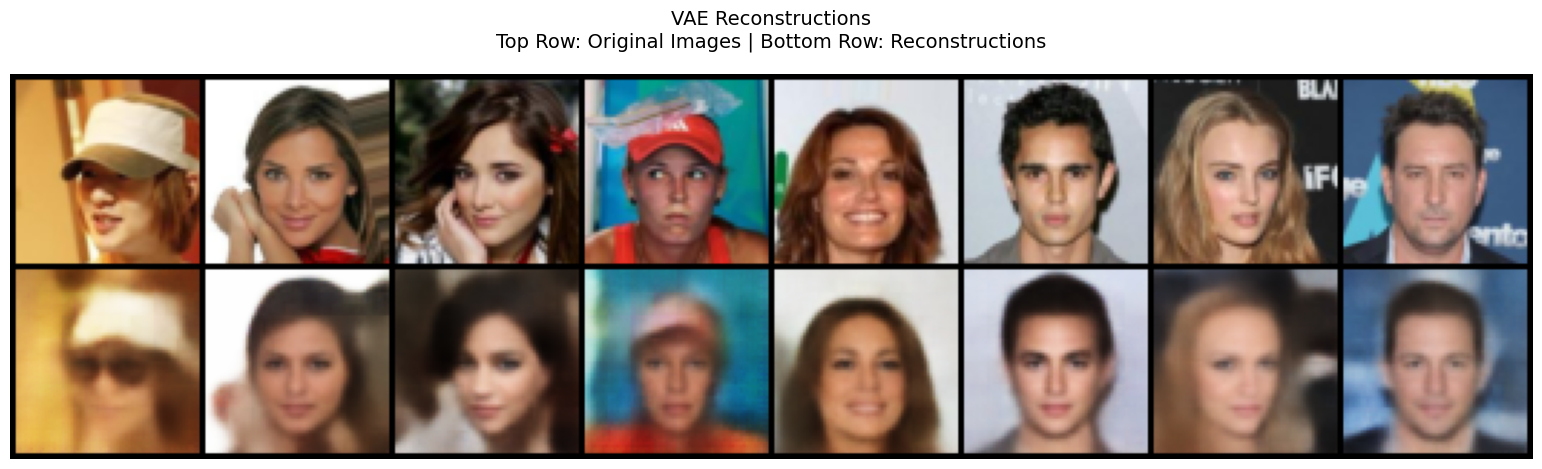


📊 Reconstruction Quality:
   Mean Squared Error: 0.008275
   Latent space dimension: 128
   Average latent mean: -0.0173
   Average latent std: 0.4835

2️⃣  LATENT SPACE INTERPOLATION

🔄 Generating latent space interpolations...
✓ Completed interpolation 1/3
✓ Completed interpolation 2/3
✓ Completed interpolation 3/3
✓ Saved to: samples/vae_demonstrations/VAE_interpolation.png
✓ Completed interpolation 1/3
✓ Completed interpolation 2/3
✓ Completed interpolation 3/3
✓ Saved to: samples/vae_demonstrations/VAE_interpolation.png


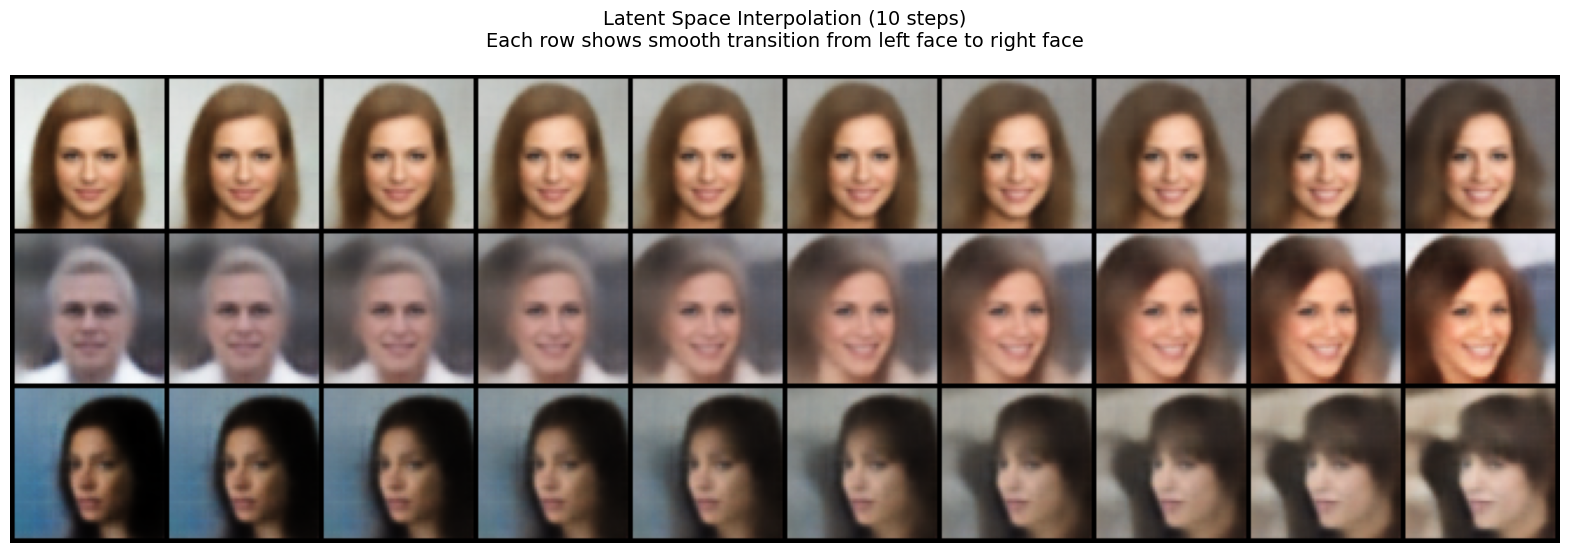


📊 Interpolation Statistics:
   Number of interpolation pairs: 3
   Steps per interpolation: 10
   Total images generated: 30

3️⃣  ATTRIBUTE MODIFICATION

--- Demonstrating: Smiling ---

✨ Computing 'Smiling' attribute vector...
   Using 300 positive samples
   Using 300 negative samples
Computing positive attribute latent mean...
Computing negative attribute latent mean...
Computing positive attribute latent mean...
Computing negative attribute latent mean...
Attribute vector computed: shape torch.Size([128])
Vector norm: 1.7687
✓ Attribute vector computed successfully
   Vector norm: 1.7687
Attribute vector computed: shape torch.Size([128])
Vector norm: 1.7687
✓ Attribute vector computed successfully
   Vector norm: 1.7687

🎨 Applying attribute modification with 5 strength levels...
✓ Processed image 1/4
✓ Processed image 2/4
✓ Processed image 3/4
✓ Processed image 4/4
✓ Saved to: samples/vae_demonstrations/VAE_attribute_smiling.png

🎨 Applying attribute modification with 5 strength

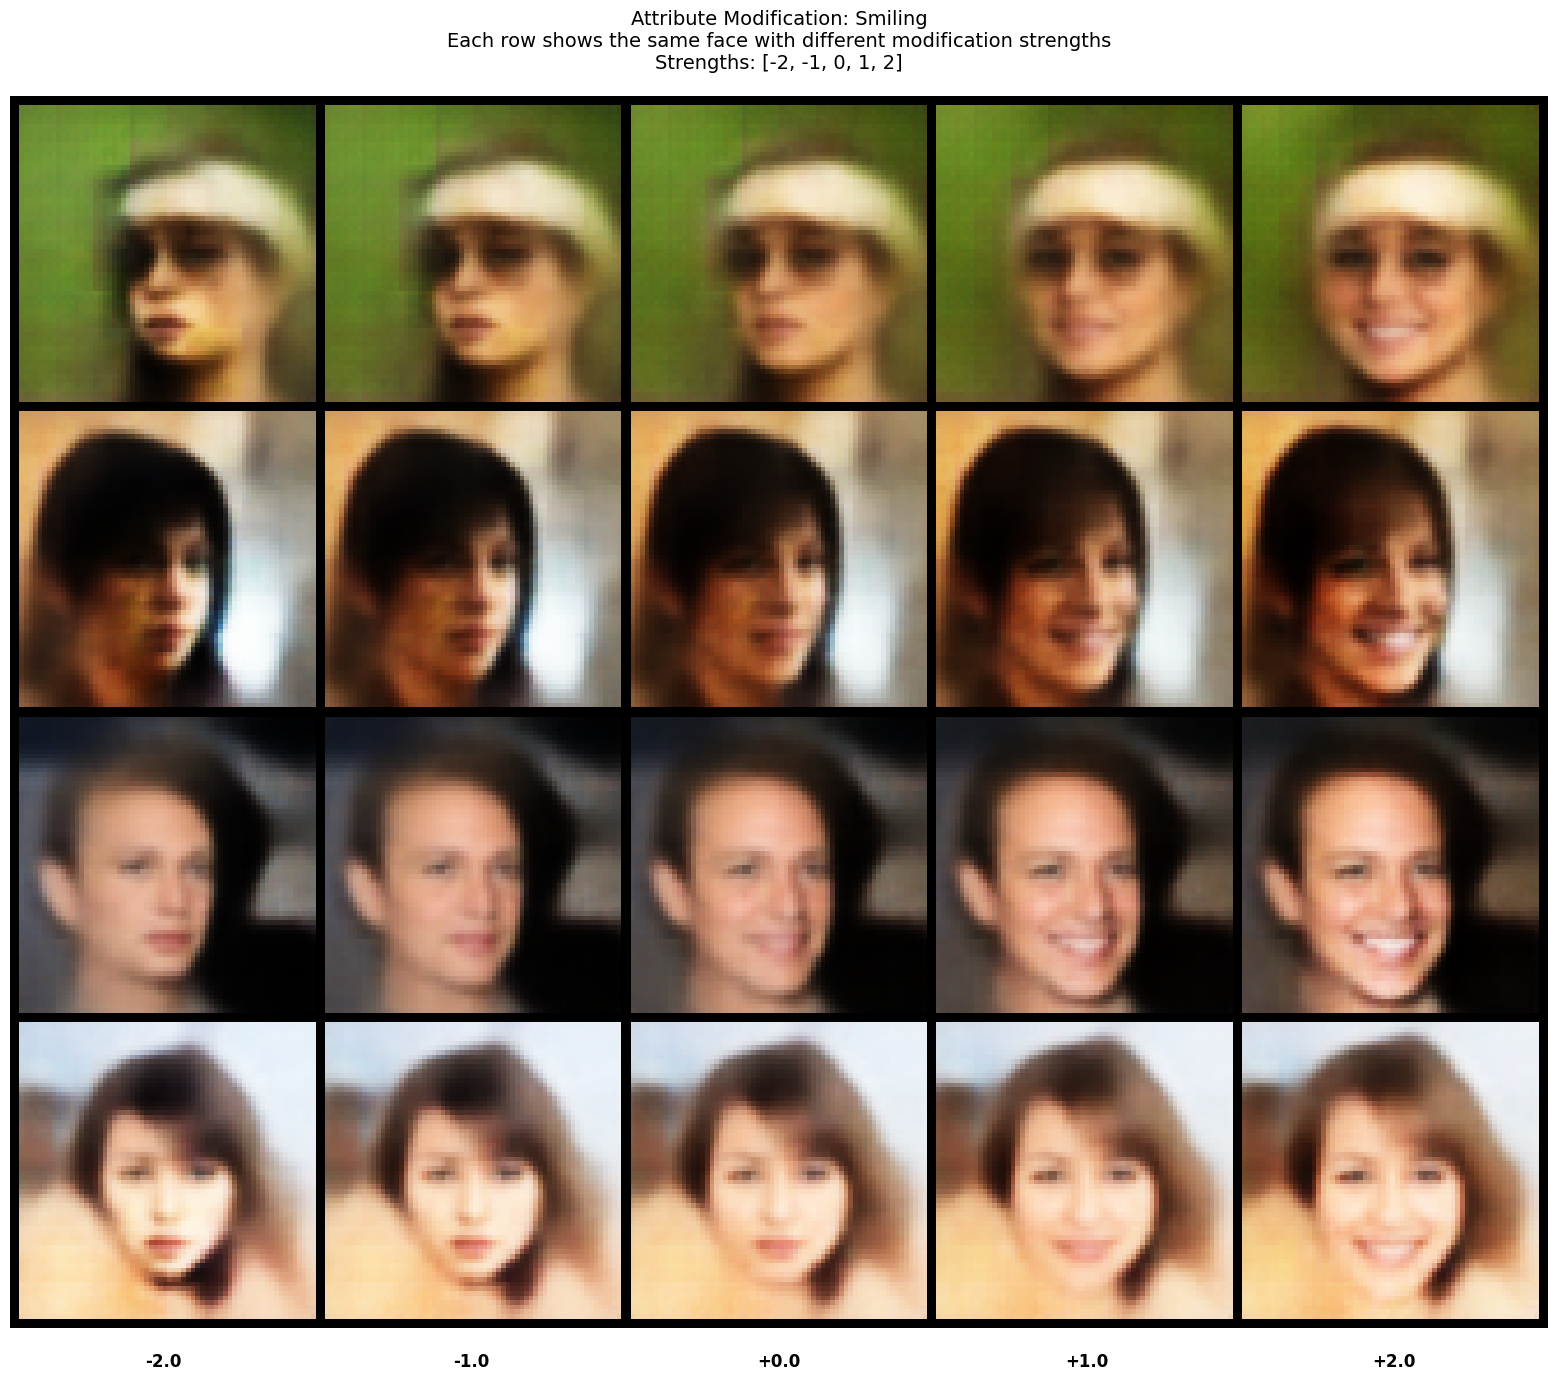


📊 Attribute Modification Statistics:
   Attribute: Smiling
   Number of test images: 4
   Strength levels: [-2, -1, 0, 1, 2]
   Total modified images: 20

--- Demonstrating: Eyeglasses ---

✨ Computing 'Eyeglasses' attribute vector...
   Using 300 positive samples
   Using 300 negative samples
Computing positive attribute latent mean...
Computing negative attribute latent mean...
Computing positive attribute latent mean...
Computing negative attribute latent mean...
Attribute vector computed: shape torch.Size([128])
Vector norm: 2.1075
✓ Attribute vector computed successfully
   Vector norm: 2.1075
Attribute vector computed: shape torch.Size([128])
Vector norm: 2.1075
✓ Attribute vector computed successfully
   Vector norm: 2.1075

🎨 Applying attribute modification with 5 strength levels...
✓ Processed image 1/4
✓ Processed image 2/4
✓ Processed image 3/4
✓ Processed image 4/4
✓ Saved to: samples/vae_demonstrations/VAE_attribute_eyeglasses.png

🎨 Applying attribute modification with 5

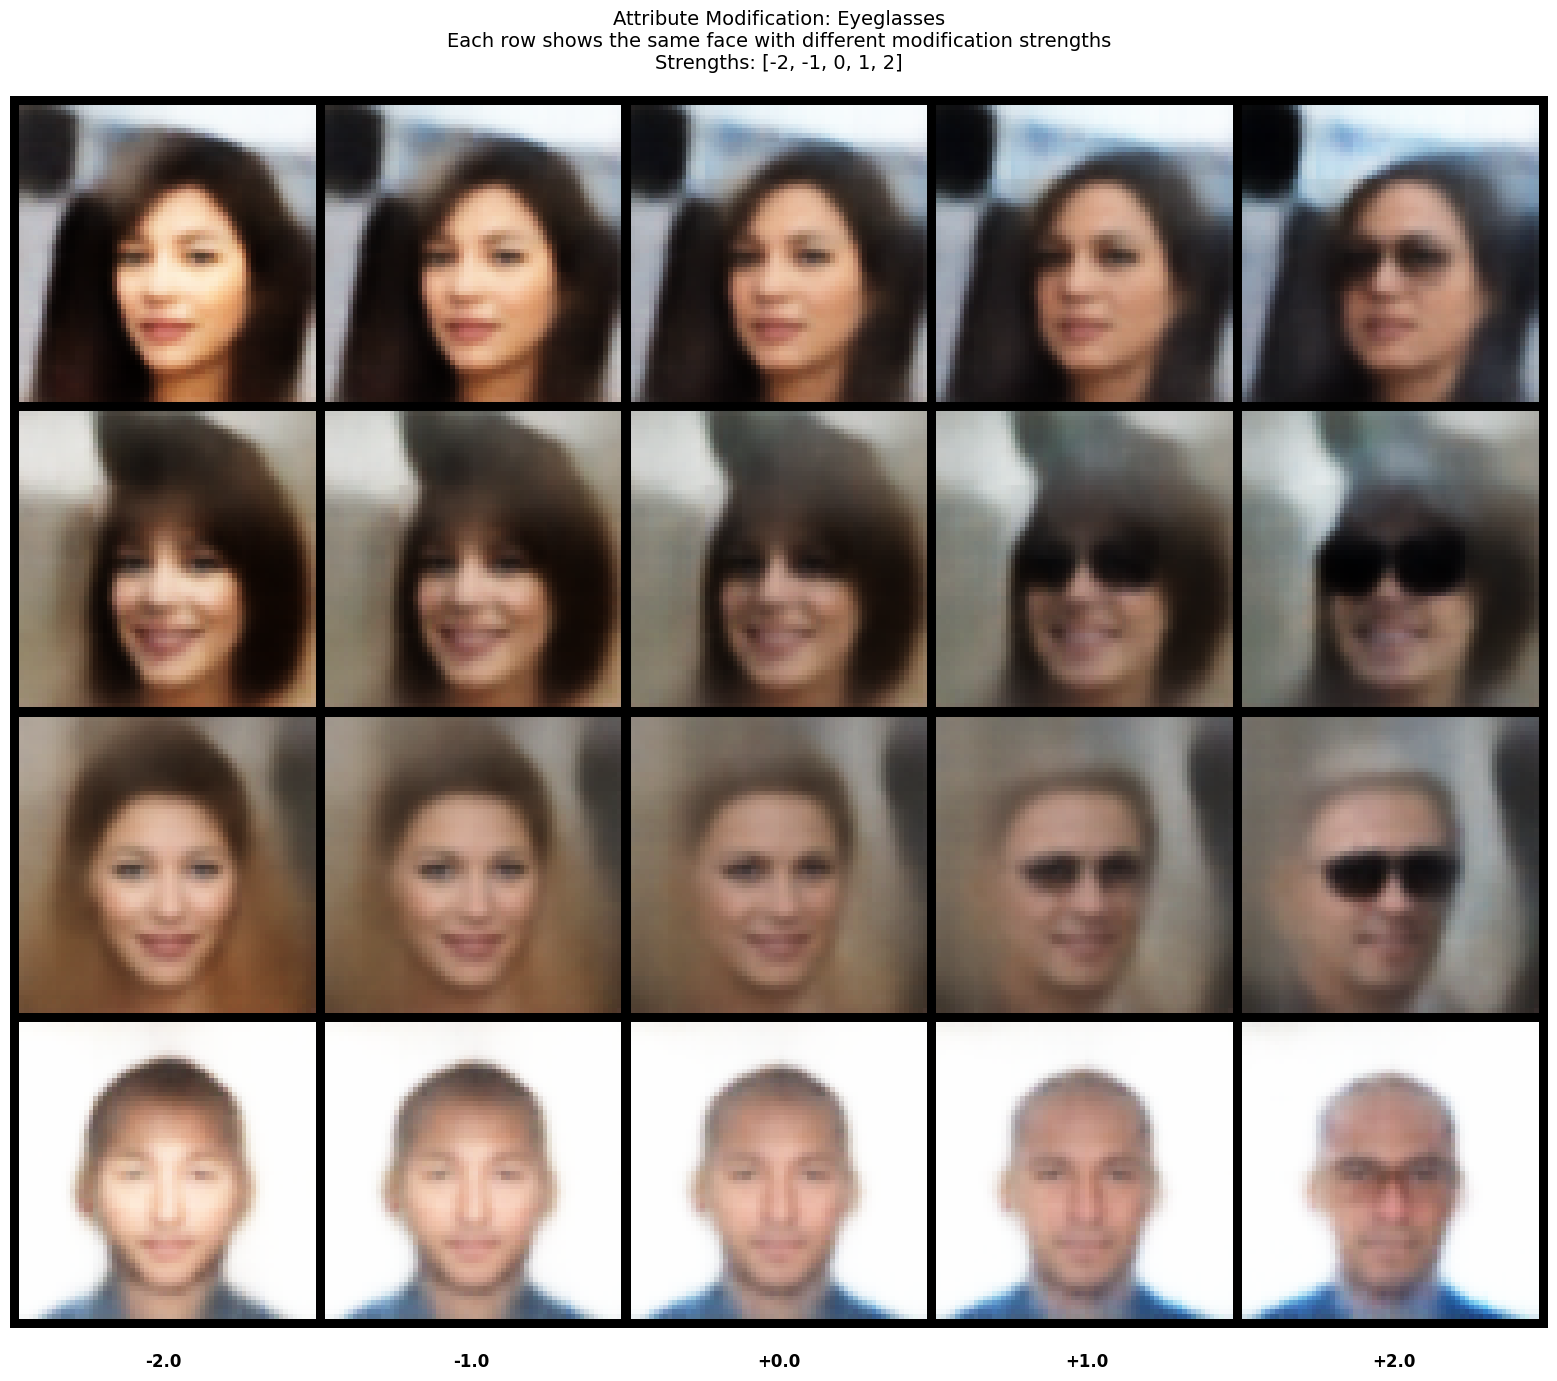


📊 Attribute Modification Statistics:
   Attribute: Eyeglasses
   Number of test images: 4
   Strength levels: [-2, -1, 0, 1, 2]
   Total modified images: 20

--- Demonstrating: Male ---

✨ Computing 'Male' attribute vector...
   Using 300 positive samples
   Using 300 negative samples
Computing positive attribute latent mean...
Computing negative attribute latent mean...
Computing positive attribute latent mean...
Computing negative attribute latent mean...
Attribute vector computed: shape torch.Size([128])
Vector norm: 1.6253
✓ Attribute vector computed successfully
   Vector norm: 1.6253
Attribute vector computed: shape torch.Size([128])
Vector norm: 1.6253
✓ Attribute vector computed successfully
   Vector norm: 1.6253

🎨 Applying attribute modification with 5 strength levels...
✓ Processed image 1/4
✓ Processed image 2/4
✓ Processed image 3/4
✓ Processed image 4/4
✓ Saved to: samples/vae_demonstrations/VAE_attribute_male.png

🎨 Applying attribute modification with 5 strength level

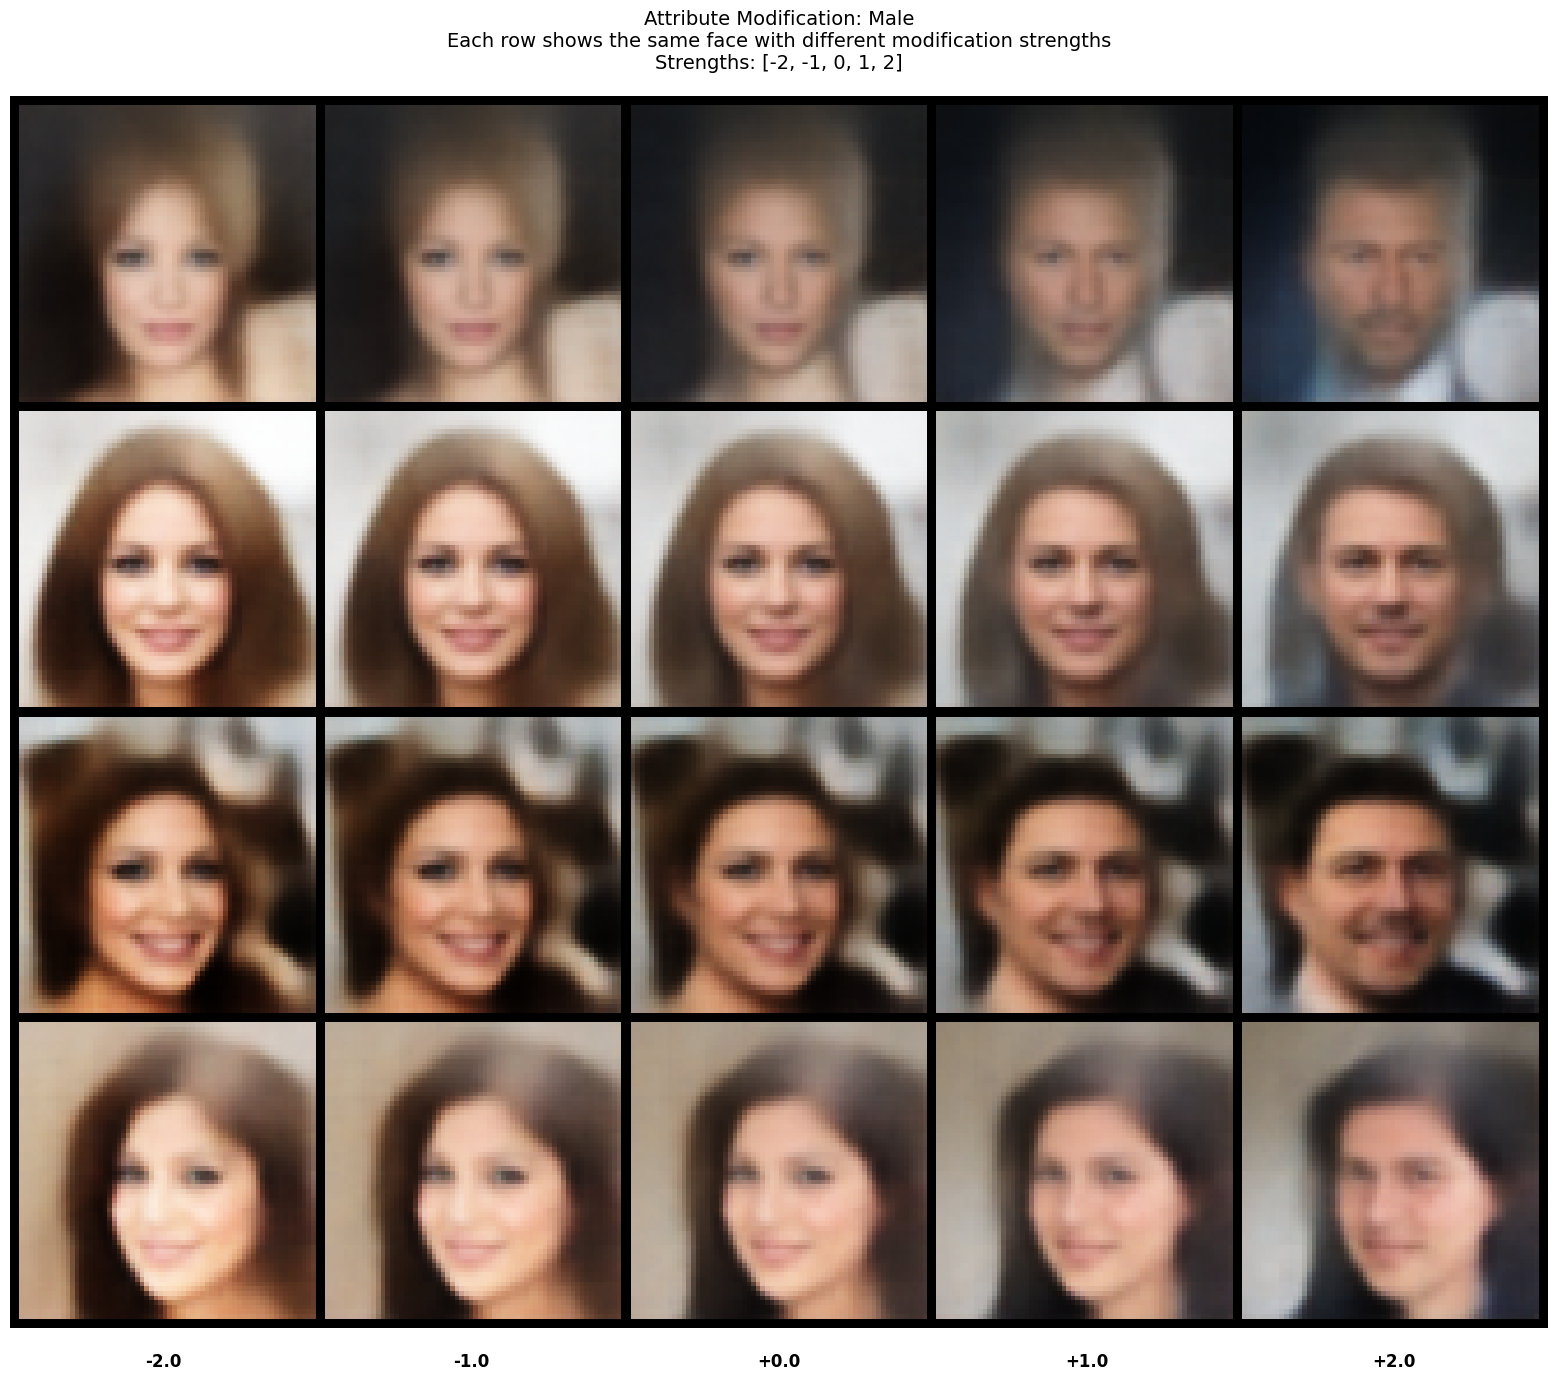


📊 Attribute Modification Statistics:
   Attribute: Male
   Number of test images: 4
   Strength levels: [-2, -1, 0, 1, 2]
   Total modified images: 20

✅ ALL DEMONSTRATIONS COMPLETED!

📁 All visualizations saved to: samples/vae_demonstrations
📁 Model checkpoint used: logs/VAE/20260204_233100/checkpoints/best_model.pth

🎯 Generated Visualizations:
   1. ✓ Reconstructions - VAE_reconstructions.png
   2. ✓ Interpolation - VAE_interpolation.png
   3. ✓ Attribute: Smiling - VAE_attribute_smiling.png
   4. ✓ Attribute: Eyeglasses - VAE_attribute_eyeglasses.png
   5. ✓ Attribute: Male - VAE_attribute_male.png


ConvVAE(
  (encoder): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (3): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (4): Sequentia

In [4]:
# ============================================================================
# EXECUTE VAE DEMONSTRATIONS ON UI-TRAINED MODEL
# ============================================================================

# RECOMMENDED: Use model trained from the dashboard
# This will automatically find and load your latest trained VAE model

# For VAE (beta=1.0):
demo_vae_from_training(model_type='VAE', latent_dim=128)

# For Beta-VAE (beta=4.0):
# demo_vae_from_training(model_type='BetaVAE_beta4', latent_dim=128)

# ============================================================================
# OR: Specify exact checkpoint path
# ============================================================================

# If you want to use a specific checkpoint:
# checkpoint_path = './logs/VAE/20260203_100943/checkpoints/best_model.pth'
# demo_vae_from_training(checkpoint_path=checkpoint_path, latent_dim=128)

# ============================================================================
# OR: Load model and run individual demonstrations
# ============================================================================

# Load the model first:
# model = load_vae_model('./logs/VAE/20260203_100943/checkpoints/best_model.pth', latent_dim=128)

# Then run individual demonstrations:
# demo_vae_reconstructions(model, num_images=8)
# demo_vae_interpolation(model, num_interpolations=3, num_steps=10)
# demo_vae_attribute_modification(model, attribute_name='Smiling', num_demo_images=4)

# ============================================================================
# NOTES
# ============================================================================
# 
# ⚠️  If you get "No checkpoint found" error:
#    1. Make sure you trained the model using the dashboard first (Cell 6)
#    2. Check that training completed successfully
#    3. Verify the model type name matches what you trained
#
# 💡 Model Type Names:
#    - 'VAE' - Standard VAE (beta=1.0)
#    - 'BetaVAE_beta4' - Beta-VAE with beta=4.0
#
# 📁 Checkpoints are saved to: ./logs/[MODEL_TYPE]/[TIMESTAMP]/checkpoints/
# 📁 Visualizations are saved to: ./samples/vae_demonstrations/
#

## Cell 3: Beta-VAE Analysis - Latent Traversal & Disentanglement

This cell implements comprehensive β-VAE analysis functionality:

### Core Functions:
1. **`latent_traversal()`** - Systematically vary individual latent dimensions
2. **`identify_attribute_dimensions()`** - Find which dimensions control specific attributes
3. **`train_multiple_beta_vaes()`** - Train models with β ∈ {2, 4, 10}
4. **`compute_disentanglement_metrics()`** - Measure disentanglement quality
5. **`compare_beta_tradeoff()`** - Analyze reconstruction vs disentanglement trade-off

### Key Features:
- **Dimension-wise traversal**: Vary one dimension while keeping others fixed
- **Attribute identification**: Discover which dimensions control smile, gender, pose, etc.
- **Multi-β training**: Automatically train and compare models with different β values
- **Trade-off analysis**: Quantify reconstruction quality vs disentanglement
- **Comprehensive visualization**: Grid plots showing attribute control per dimension

In [ ]:
# ============================================================================
# BETA-VAE ANALYSIS: LATENT TRAVERSAL & DISENTANGLEMENT
# ============================================================================

import numpy as np
from typing import List, Dict, Tuple
from pathlib import Path
import json

def latent_traversal(
    model: ConvVAE,
    base_image: torch.Tensor = None,
    dim_index: int = 0,
    traversal_range: Tuple[float, float] = (-3.0, 3.0),
    num_steps: int = 11,
    device: torch.device = None
) -> torch.Tensor:
    """
    Perform latent traversal by varying a single dimension while keeping others fixed.
    
    Args:
        model: Trained VAE model
        base_image: Base image to encode [C, H, W]. If None, uses random latent.
        dim_index: Which latent dimension to traverse
        traversal_range: (min, max) range for traversal
        num_steps: Number of steps in traversal
        device: Device to use
    
    Returns:
        Traversed images [num_steps, C, H, W]
    """
    if device is None:
        device = get_device()
    
    model.eval()
    model = model.to(device)
    
    with torch.no_grad():
        # Get base latent code
        if base_image is not None:
            base_image = base_image.unsqueeze(0).to(device)
            mu, _ = model.encode(base_image)
            z_base = mu.squeeze(0)
        else:
            # Use zero vector as base
            z_base = torch.zeros(model.latent_dim).to(device)
        
        # Create traversal values
        traversal_values = torch.linspace(
            traversal_range[0], 
            traversal_range[1], 
            num_steps
        ).to(device)
        
        # Generate images by varying single dimension
        traversed_images = []
        for value in traversal_values:
            z = z_base.clone()
            z[dim_index] = value
            recon = model.decode(z.unsqueeze(0))
            traversed_images.append(recon.squeeze(0))
        
        traversed_images = torch.stack(traversed_images)
    
    return traversed_images


def latent_traversal_grid(
    model: ConvVAE,
    base_image: torch.Tensor = None,
    num_dims: int = 10,
    traversal_range: Tuple[float, float] = (-3.0, 3.0),
    num_steps: int = 7,
    device: torch.device = None
) -> torch.Tensor:
    """
    Create a grid showing traversal across multiple dimensions.
    
    Args:
        model: Trained VAE model
        base_image: Base image [C, H, W]
        num_dims: Number of dimensions to visualize
        traversal_range: Range for each dimension
        num_steps: Steps per dimension
        device: Device to use
    
    Returns:
        Grid of images [num_dims, num_steps, C, H, W]
    """
    if device is None:
        device = get_device()
    
    all_traversals = []
    for dim_idx in range(num_dims):
        traversal = latent_traversal(
            model, base_image, dim_idx, 
            traversal_range, num_steps, device
        )
        all_traversals.append(traversal)
    
    return torch.stack(all_traversals)


def identify_attribute_dimensions(
    model: ConvVAE,
    attribute_name: str,
    train_loader: DataLoader = None,
    num_dims_to_check: int = 20,
    num_samples: int = 500,
    device: torch.device = None
) -> Dict[str, any]:
    """
    Identify which latent dimensions are most correlated with a specific attribute.
    
    Args:
        model: Trained VAE model
        attribute_name: Name of attribute to analyze (e.g., 'Smiling', 'Male')
        train_loader: DataLoader with full dataset (will filter internally)
        num_dims_to_check: Number of top dimensions to return
        num_samples: Number of samples to use for analysis
        device: Device to use
    
    Returns:
        Dictionary with:
            - 'top_dimensions': List of (dim_index, correlation_score)
            - 'attribute_vector': Computed attribute vector
            - 'mean_positive': Mean latent code for positive samples
            - 'mean_negative': Mean latent code for negative samples
    """
    if device is None:
        device = get_device()
    
    model.eval()
    model = model.to(device)
    
    print(f"\n{'='*80}")
    print(f"Identifying dimensions for attribute: {attribute_name}")
    print(f"{'='*80}\n")
    
    # Get positive and negative samples
    if train_loader is None:
        train_loader = get_celeba_dataloader(split='train', batch_size=128)
    
    pos_loader = get_celeba_dataloader(
        split='train', batch_size=128,
        target_attributes=[attribute_name], 
        attribute_values=[1]
    )
    neg_loader = get_celeba_dataloader(
        split='train', batch_size=128,
        target_attributes=[attribute_name], 
        attribute_values=[0]
    )
    
    # Collect latent codes
    pos_latents = []
    neg_latents = []
    
    print("Encoding positive samples...")
    with torch.no_grad():
        count = 0
        for images, _ in pos_loader:
            images = images.to(device)
            mu, _ = model.encode(images)
            pos_latents.append(mu)
            count += len(images)
            if count >= num_samples:
                break
        pos_latents = torch.cat(pos_latents, dim=0)[:num_samples]
    
    print("Encoding negative samples...")
    with torch.no_grad():
        count = 0
        for images, _ in neg_loader:
            images = images.to(device)
            mu, _ = model.encode(images)
            neg_latents.append(mu)
            count += len(images)
            if count >= num_samples:
                break
        neg_latents = torch.cat(neg_latents, dim=0)[:num_samples]
    
    # Compute statistics
    mean_pos = pos_latents.mean(dim=0)
    mean_neg = neg_latents.mean(dim=0)
    
    # Attribute vector (direction in latent space)
    attribute_vector = mean_pos - mean_neg
    
    # Compute per-dimension difference (absolute value for ranking)
    dim_differences = torch.abs(attribute_vector).cpu().numpy()
    
    # Rank dimensions by importance
    ranked_dims = np.argsort(dim_differences)[::-1]
    top_dims = [(int(dim), float(dim_differences[dim])) 
                for dim in ranked_dims[:num_dims_to_check]]
    
    print(f"\nTop {num_dims_to_check} dimensions for '{attribute_name}':")
    print("-" * 60)
    for rank, (dim, score) in enumerate(top_dims[:10], 1):
        print(f"  {rank:2d}. Dimension {dim:3d}: {score:.4f}")
    
    print(f"\nAttribute vector norm: {attribute_vector.norm().item():.4f}")
    print(f"Number of positive samples: {len(pos_latents)}")
    print(f"Number of negative samples: {len(neg_latents)}")
    
    return {
        'top_dimensions': top_dims,
        'attribute_vector': attribute_vector,
        'mean_positive': mean_pos,
        'mean_negative': mean_neg,
        'all_dim_scores': dim_differences
    }


def train_multiple_beta_vaes(
    beta_values: List[float] = [2.0, 4.0, 10.0],
    latent_dim: int = 128,
    num_epochs: int = 20,
    learning_rate: float = 1e-4,
    batch_size: int = 128,
    device: torch.device = None,
    save_dir: str = './logs'
) -> Dict[float, Tuple[ConvVAE, Dict]]:
    """
    Train multiple β-VAE models with different β values.
    
    Args:
        beta_values: List of β values to train
        latent_dim: Latent dimension size
        num_epochs: Training epochs per model
        learning_rate: Learning rate
        batch_size: Batch size
        device: Device to use
        save_dir: Directory to save models
    
    Returns:
        Dictionary mapping β -> (trained_model, training_history)
    """
    if device is None:
        device = get_device()
    
    results = {}
    train_loader = get_celeba_dataloader(split='train', batch_size=batch_size)
    
    print(f"\n{'='*80}")
    print(f"Training {len(beta_values)} β-VAE models")
    print(f"β values: {beta_values}")
    print(f"{'='*80}\n")
    
    for beta in beta_values:
        print(f"\n{'#'*80}")
        print(f"# Training β-VAE with β = {beta}")
        print(f"{'#'*80}\n")
        
        # Initialize model
        model = ConvVAE(latent_dim=latent_dim)
        
        # Train
        trained_model, logger = train_vae(
            model=model,
            train_loader=train_loader,
            num_epochs=num_epochs,
            learning_rate=learning_rate,
            beta=beta,
            device=device,
            experiment_name=f"beta_{beta}",
            run_demos=False  # Don't run demos during batch training
        )
        
        # Load training history
        history_path = logger.exp_dir / 'training_history.json'
        with open(history_path, 'r') as f:
            history = json.load(f)
        
        results[beta] = (trained_model, history, logger)
        
        print(f"\n✓ Completed training for β = {beta}")
        print(f"  Final loss: {history['total_loss'][-1]:.4f}")
        print(f"  Saved to: {logger.exp_dir}")
    
    print(f"\n{'='*80}")
    print(f"✓ All {len(beta_values)} models trained successfully!")
    print(f"{'='*80}\n")
    
    return results


def compute_disentanglement_metrics(
    model: ConvVAE,
    test_loader: DataLoader,
    num_samples: int = 1000,
    device: torch.device = None
) -> Dict[str, float]:
    """
    Compute disentanglement metrics for a trained model.
    
    Metrics:
        - reconstruction_error: MSE on test set
        - latent_std: Standard deviation across latent dimensions
        - latent_mean_abs: Mean absolute value of latent codes
        
    Args:
        model: Trained VAE model
        test_loader: Test data loader
        num_samples: Number of samples for evaluation
        device: Device to use
    
    Returns:
        Dictionary of metrics
    """
    if device is None:
        device = get_device()
    
    model.eval()
    model = model.to(device)
    
    recon_errors = []
    latent_codes = []
    
    with torch.no_grad():
        count = 0
        for images, _ in test_loader:
            images = images.to(device)
            recon, mu, logvar = model(images)
            
            # Reconstruction error
            mse = nn.functional.mse_loss(recon, images, reduction='none')
            mse = mse.view(len(images), -1).mean(dim=1)
            recon_errors.extend(mse.cpu().numpy())
            
            # Latent codes
            latent_codes.append(mu)
            
            count += len(images)
            if count >= num_samples:
                break
    
    latent_codes = torch.cat(latent_codes, dim=0)[:num_samples]
    
    # Compute statistics
    latent_std = latent_codes.std(dim=0).mean().item()
    latent_mean_abs = latent_codes.abs().mean().item()
    avg_recon_error = np.mean(recon_errors[:num_samples])
    
    metrics = {
        'reconstruction_error': avg_recon_error,
        'latent_std': latent_std,
        'latent_mean_abs': latent_mean_abs,
        'num_samples': min(count, num_samples)
    }
    
    return metrics


def compare_beta_tradeoff(
    trained_models: Dict[float, Tuple[ConvVAE, Dict]],
    test_loader: DataLoader = None,
    attributes_to_test: List[str] = ['Smiling', 'Male', 'Young'],
    device: torch.device = None,
    save_path: str = None
) -> Dict[float, Dict]:
    """
    Compare reconstruction vs disentanglement trade-off across different β values.
    
    Args:
        trained_models: Dict mapping β -> (model, history, logger)
        test_loader: Test data loader
        attributes_to_test: Attributes to analyze for disentanglement
        device: Device to use
        save_path: Path to save comparison plots
    
    Returns:
        Dictionary with comparison results
    """
    if device is None:
        device = get_device()
    
    if test_loader is None:
        test_loader = get_celeba_dataloader(split='test', batch_size=128)
    
    print(f"\n{'='*80}")
    print("COMPARING β-VAE MODELS: Reconstruction vs Disentanglement Trade-off")
    print(f"{'='*80}\n")
    
    results = {}
    
    for beta, (model, history, logger) in trained_models.items():
        print(f"\nAnalyzing β = {beta}...")
        
        # Compute metrics
        metrics = compute_disentanglement_metrics(model, test_loader, device=device)
        
        # Get training history metrics
        if history and isinstance(history, dict):
            final_recon_loss = history.get('recon_loss', [0])[-1] if history.get('recon_loss') else 0
            final_kl_loss = history.get('kl_loss', [0])[-1] if history.get('kl_loss') else 0
            final_total_loss = history.get('total_loss', [0])[-1] if history.get('total_loss') else 0
        else:
            print(f"  ⚠️  Warning: Training history not available for β = {beta}")
            final_recon_loss = None
            final_kl_loss = None
            final_total_loss = None
        
        # Analyze attribute dimensions
        attribute_analysis = {}
        for attr in attributes_to_test:
            try:
                attr_info = identify_attribute_dimensions(
                    model, attr, num_dims_to_check=5, num_samples=200, device=device
                )
                # Store top dimension and its score
                attribute_analysis[attr] = {
                    'top_dim': attr_info['top_dimensions'][0][0],
                    'top_score': attr_info['top_dimensions'][0][1],
                    'vector_norm': attr_info['attribute_vector'].norm().item()
                }
            except Exception as e:
                print(f"  Warning: Could not analyze {attr}: {e}")
                attribute_analysis[attr] = None
        
        results[beta] = {
            'reconstruction_error': metrics['reconstruction_error'],
            'latent_std': metrics['latent_std'],
            'latent_mean_abs': metrics['latent_mean_abs'],
            'final_recon_loss': final_recon_loss,
            'final_kl_loss': final_kl_loss,
            'final_total_loss': final_total_loss,
            'attribute_analysis': attribute_analysis
        }
        
        print(f"  ✓ Reconstruction Error: {metrics['reconstruction_error']:.6f}")
        print(f"  ✓ Latent Std: {metrics['latent_std']:.4f}")
        if final_kl_loss is not None:
            print(f"  ✓ Final KL Loss: {final_kl_loss:.4f}")
        else:
            print(f"  ⚠️  Final KL Loss: Not available (history not loaded)")
    
    # Create comparison visualizations
    print(f"\n{'='*80}")
    print("SUMMARY COMPARISON")
    print(f"{'='*80}\n")
    
    print(f"{'β Value':<10} {'Recon Error':<15} {'KL Loss':<15} {'Latent Std':<15}")
    print("-" * 60)
    for beta in sorted(results.keys()):
        r = results[beta]
        kl_str = f"{r['final_kl_loss']:<15.4f}" if r['final_kl_loss'] is not None else "N/A            "
        print(f"{beta:<10.1f} {r['reconstruction_error']:<15.6f} "
              f"{kl_str} {r['latent_std']:<15.4f}")
    
    # Plot trade-off curves
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    betas = sorted(results.keys())
    recon_errors = [results[b]['reconstruction_error'] for b in betas]
    kl_losses = [results[b]['final_kl_loss'] for b in betas if results[b]['final_kl_loss'] is not None]
    kl_betas = [b for b in betas if results[b]['final_kl_loss'] is not None]
    latent_stds = [results[b]['latent_std'] for b in betas]
    
    # Plot 1: Reconstruction Error vs β
    axes[0].plot(betas, recon_errors, 'o-', linewidth=2, markersize=8)
    axes[0].set_xlabel('β Value', fontsize=12)
    axes[0].set_ylabel('Reconstruction Error (MSE)', fontsize=12)
    axes[0].set_title('Reconstruction Quality vs β', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    for b, r in zip(betas, recon_errors):
        axes[0].text(b, r, f'{r:.6f}', ha='center', va='bottom', fontsize=9)
    
    # Plot 2: KL Loss vs β
    if kl_losses:  # Only plot if we have KL loss data
        axes[1].plot(kl_betas, kl_losses, 'o-', linewidth=2, markersize=8, color='orange')
        axes[1].set_xlabel('β Value', fontsize=12)
        axes[1].set_ylabel('KL Divergence Loss', fontsize=12)
        axes[1].set_title('Disentanglement Pressure vs β', fontsize=14, fontweight='bold')
        axes[1].grid(True, alpha=0.3)
        for b, k in zip(kl_betas, kl_losses):
            axes[1].text(b, k, f'{k:.2f}', ha='center', va='bottom', fontsize=9)
    else:
        axes[1].text(0.5, 0.5, 'KL Loss data not available\n(Training history not found)',
                    ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
        axes[1].set_title('Disentanglement Pressure vs β', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n{'='*80}")
    print("KEY OBSERVATIONS:")
    print(f"{'='*80}")
    print("• Higher β → Better disentanglement (lower KL) but worse reconstruction")
    print("• Lower β → Better reconstruction but less disentangled representations")
    print("• Optimal β depends on task requirements (generation vs interpretation)")
    print(f"{'='*80}\n")
    
    return results


def visualize_latent_traversal_comparison(
    trained_models: Dict[float, Tuple[ConvVAE, Dict]],
    base_image: torch.Tensor,
    dim_index: int = 0,
    num_steps: int = 7,
    traversal_range: Tuple[float, float] = (-3.0, 3.0),
    device: torch.device = None,
    save_path: str = None
):
    """
    Visualize latent traversal for the same dimension across different β values.
    
    Args:
        trained_models: Dict mapping β -> (model, history, logger)
        base_image: Base image to traverse [C, H, W]
        dim_index: Dimension to traverse
        num_steps: Number of steps
        traversal_range: Range for traversal
        device: Device to use
        save_path: Path to save figure
    """
    if device is None:
        device = get_device()
    
    fig, axes = plt.subplots(len(trained_models), 1, 
                             figsize=(20, 4 * len(trained_models)))
    
    if len(trained_models) == 1:
        axes = [axes]
    
    for idx, (beta, (model, _, _)) in enumerate(sorted(trained_models.items())):
        traversal = latent_traversal(
            model, base_image, dim_index, 
            traversal_range, num_steps, device
        )
        
        grid = make_grid(traversal, nrow=num_steps, padding=2, normalize=True)
        axes[idx].imshow(grid.permute(1, 2, 0).cpu().numpy())
        axes[idx].axis('off')
        axes[idx].set_title(f'β = {beta} | Dimension {dim_index} Traversal', 
                           fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ============================================================================
# EXAMPLE USAGE AND COMPLETE WORKFLOW
# ============================================================================

print("\n" + "="*80)
print("β-VAE ANALYSIS TOOLKIT - COMPLETE")
print("="*80)
print("\nFunctions added:")
print("  1. ✓ latent_traversal() - Vary single dimension")
print("  2. ✓ latent_traversal_grid() - Multi-dimension visualization")
print("  3. ✓ identify_attribute_dimensions() - Find attribute controllers")
print("  4. ✓ train_multiple_beta_vaes() - Train models with multiple β values")
print("  5. ✓ compute_disentanglement_metrics() - Quantify disentanglement")
print("  6. ✓ compare_beta_tradeoff() - Analyze reconstruction vs disentanglement")
print("  7. ✓ visualize_latent_traversal_comparison() - Compare traversals across β")
print("="*80)

print("\n" + "="*80)
print("COMPLETE WORKFLOW EXAMPLE:")
print("="*80)
print("""
# Step 1: Train multiple β-VAE models
trained_models = train_multiple_beta_vaes(
    beta_values=[2.0, 4.0, 10.0],
    latent_dim=128,
    num_epochs=20,
    batch_size=128
)

# Step 2: Compare reconstruction vs disentanglement trade-off
comparison_results = compare_beta_tradeoff(
    trained_models,
    attributes_to_test=['Smiling', 'Male', 'Young'],
    save_path='./beta_comparison.png'
)

# Step 3: Perform latent traversal for each model
test_loader = get_celeba_dataloader(split='test', batch_size=1)
test_image, _ = next(iter(test_loader))
test_image = test_image[0]

for beta, (model, _, _) in trained_models.items():
    print(f"\\nLatent traversal for β = {beta}")
    
    # Single dimension traversal
    traversal = latent_traversal(model, test_image, dim_index=0)
    visualize_interpolation(traversal, save_path=f'traversal_beta_{beta}.png')
    
    # Multi-dimension grid
    grid = latent_traversal_grid(model, test_image, num_dims=10, num_steps=7)
    # Visualize grid...

# Step 4: Identify dimensions controlling specific attributes
for beta, (model, _, _) in trained_models.items():
    print(f"\\n{'='*80}")
    print(f"Attribute analysis for β = {beta}")
    print(f"{'='*80}")
    
    for attribute in ['Smiling', 'Male', 'Young']:
        attr_info = identify_attribute_dimensions(
            model, attribute, num_dims_to_check=10
        )
        
        # Visualize top dimension
        top_dim = attr_info['top_dimensions'][0][0]
        traversal = latent_traversal(model, test_image, dim_index=top_dim)
        visualize_attribute_manipulation(
            traversal, 
            strengths=[-3, -2, -1, 0, 1, 2, 3],
            attribute_name=f'{attribute} (β={beta}, dim={top_dim})',
            save_path=f'{attribute}_beta_{beta}.png'
        )

# Step 5: Compare same dimension across different β values
visualize_latent_traversal_comparison(
    trained_models,
    base_image=test_image,
    dim_index=0,
    save_path='dimension_comparison_across_beta.png'
)
""")


β-VAE ANALYSIS TOOLKIT - COMPLETE

Functions added:
  1. ✓ latent_traversal() - Vary single dimension
  2. ✓ latent_traversal_grid() - Multi-dimension visualization
  3. ✓ identify_attribute_dimensions() - Find attribute controllers
  4. ✓ train_multiple_beta_vaes() - Train models with multiple β values
  5. ✓ compute_disentanglement_metrics() - Quantify disentanglement
  6. ✓ compare_beta_tradeoff() - Analyze reconstruction vs disentanglement
  7. ✓ visualize_latent_traversal_comparison() - Compare traversals across β

COMPLETE WORKFLOW EXAMPLE:

# Step 1: Train multiple β-VAE models
trained_models = train_multiple_beta_vaes(
    beta_values=[2.0, 4.0, 10.0],
    latent_dim=128,
    num_epochs=20,
    batch_size=128
)

# Step 2: Compare reconstruction vs disentanglement trade-off
comparison_results = compare_beta_tradeoff(
    trained_models,
    attributes_to_test=['Smiling', 'Male', 'Young'],
    save_path='./beta_comparison.png'
)

# Step 3: Perform latent traversal for each model

## Cell 3.1: β-VAE Experiments - Run Complete Analysis

Execute the complete β-VAE analysis pipeline:
1. Train models with β ∈ {2, 4, 10}
2. Perform latent traversal across dimensions
3. Identify dimensions controlling smile, gender, and pose
4. Compare reconstruction vs disentanglement trade-off

**Note**: Training takes time. For quick testing, reduce `num_epochs` to 5-10.

LOADING AND ANALYZING β-VAE MODELS FROM UI TRAINING

Configuration:
  β values to load: [2.0, 4.0, 10.0]
  Latent dimensions: 128
  Attributes to analyze: ['Smiling', 'Male', 'Young']


################################################################################
# STEP 1: LOADING TRAINED MODELS FROM UI
################################################################################


Searching for β = 2.0 model...
  ⚠️  Warning: No directory found at logs/BetaVAE_beta2
  Skipping β = 2.0

Searching for β = 4.0 model...
  ✓ Found training run: logs/BetaVAE_beta4/20260203_103843
  Loading model from: logs/BetaVAE_beta4/20260203_103843/checkpoints/best_model.pth
  ✅ Successfully loaded β = 4.0 model
     Epoch: 2
     Metrics: {'total_loss': 6571.991143561467, 'recon_loss': 6397.65440422068, 'kl_loss': 43.584185528156105}

Searching for β = 10.0 model...
  ⚠️  Warning: No directory found at logs/BetaVAE_beta10
  Skipping β = 10.0

✅ STEP 1 COMPLETE: Successfully loaded 1 models!
   Lo

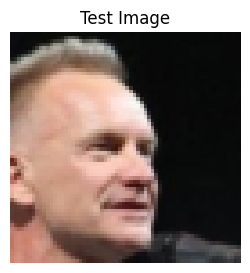


Latent Traversal for β = 4.0

1. Single dimension traversal (dimension 0)...


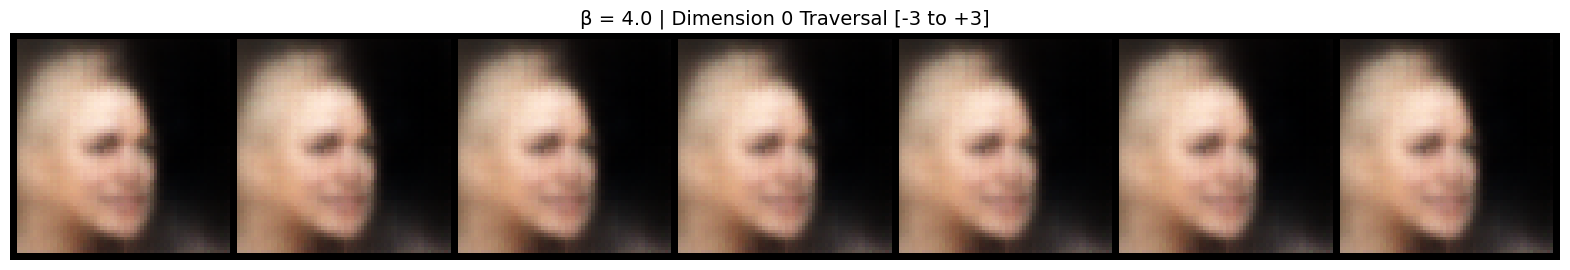

   ✓ Saved to: logs/BetaVAE_beta4/20260203_103843/latent_traversals/traversal_dim0_beta4.0.png
2. Multi-dimension traversal grid (dimensions 0-7)...


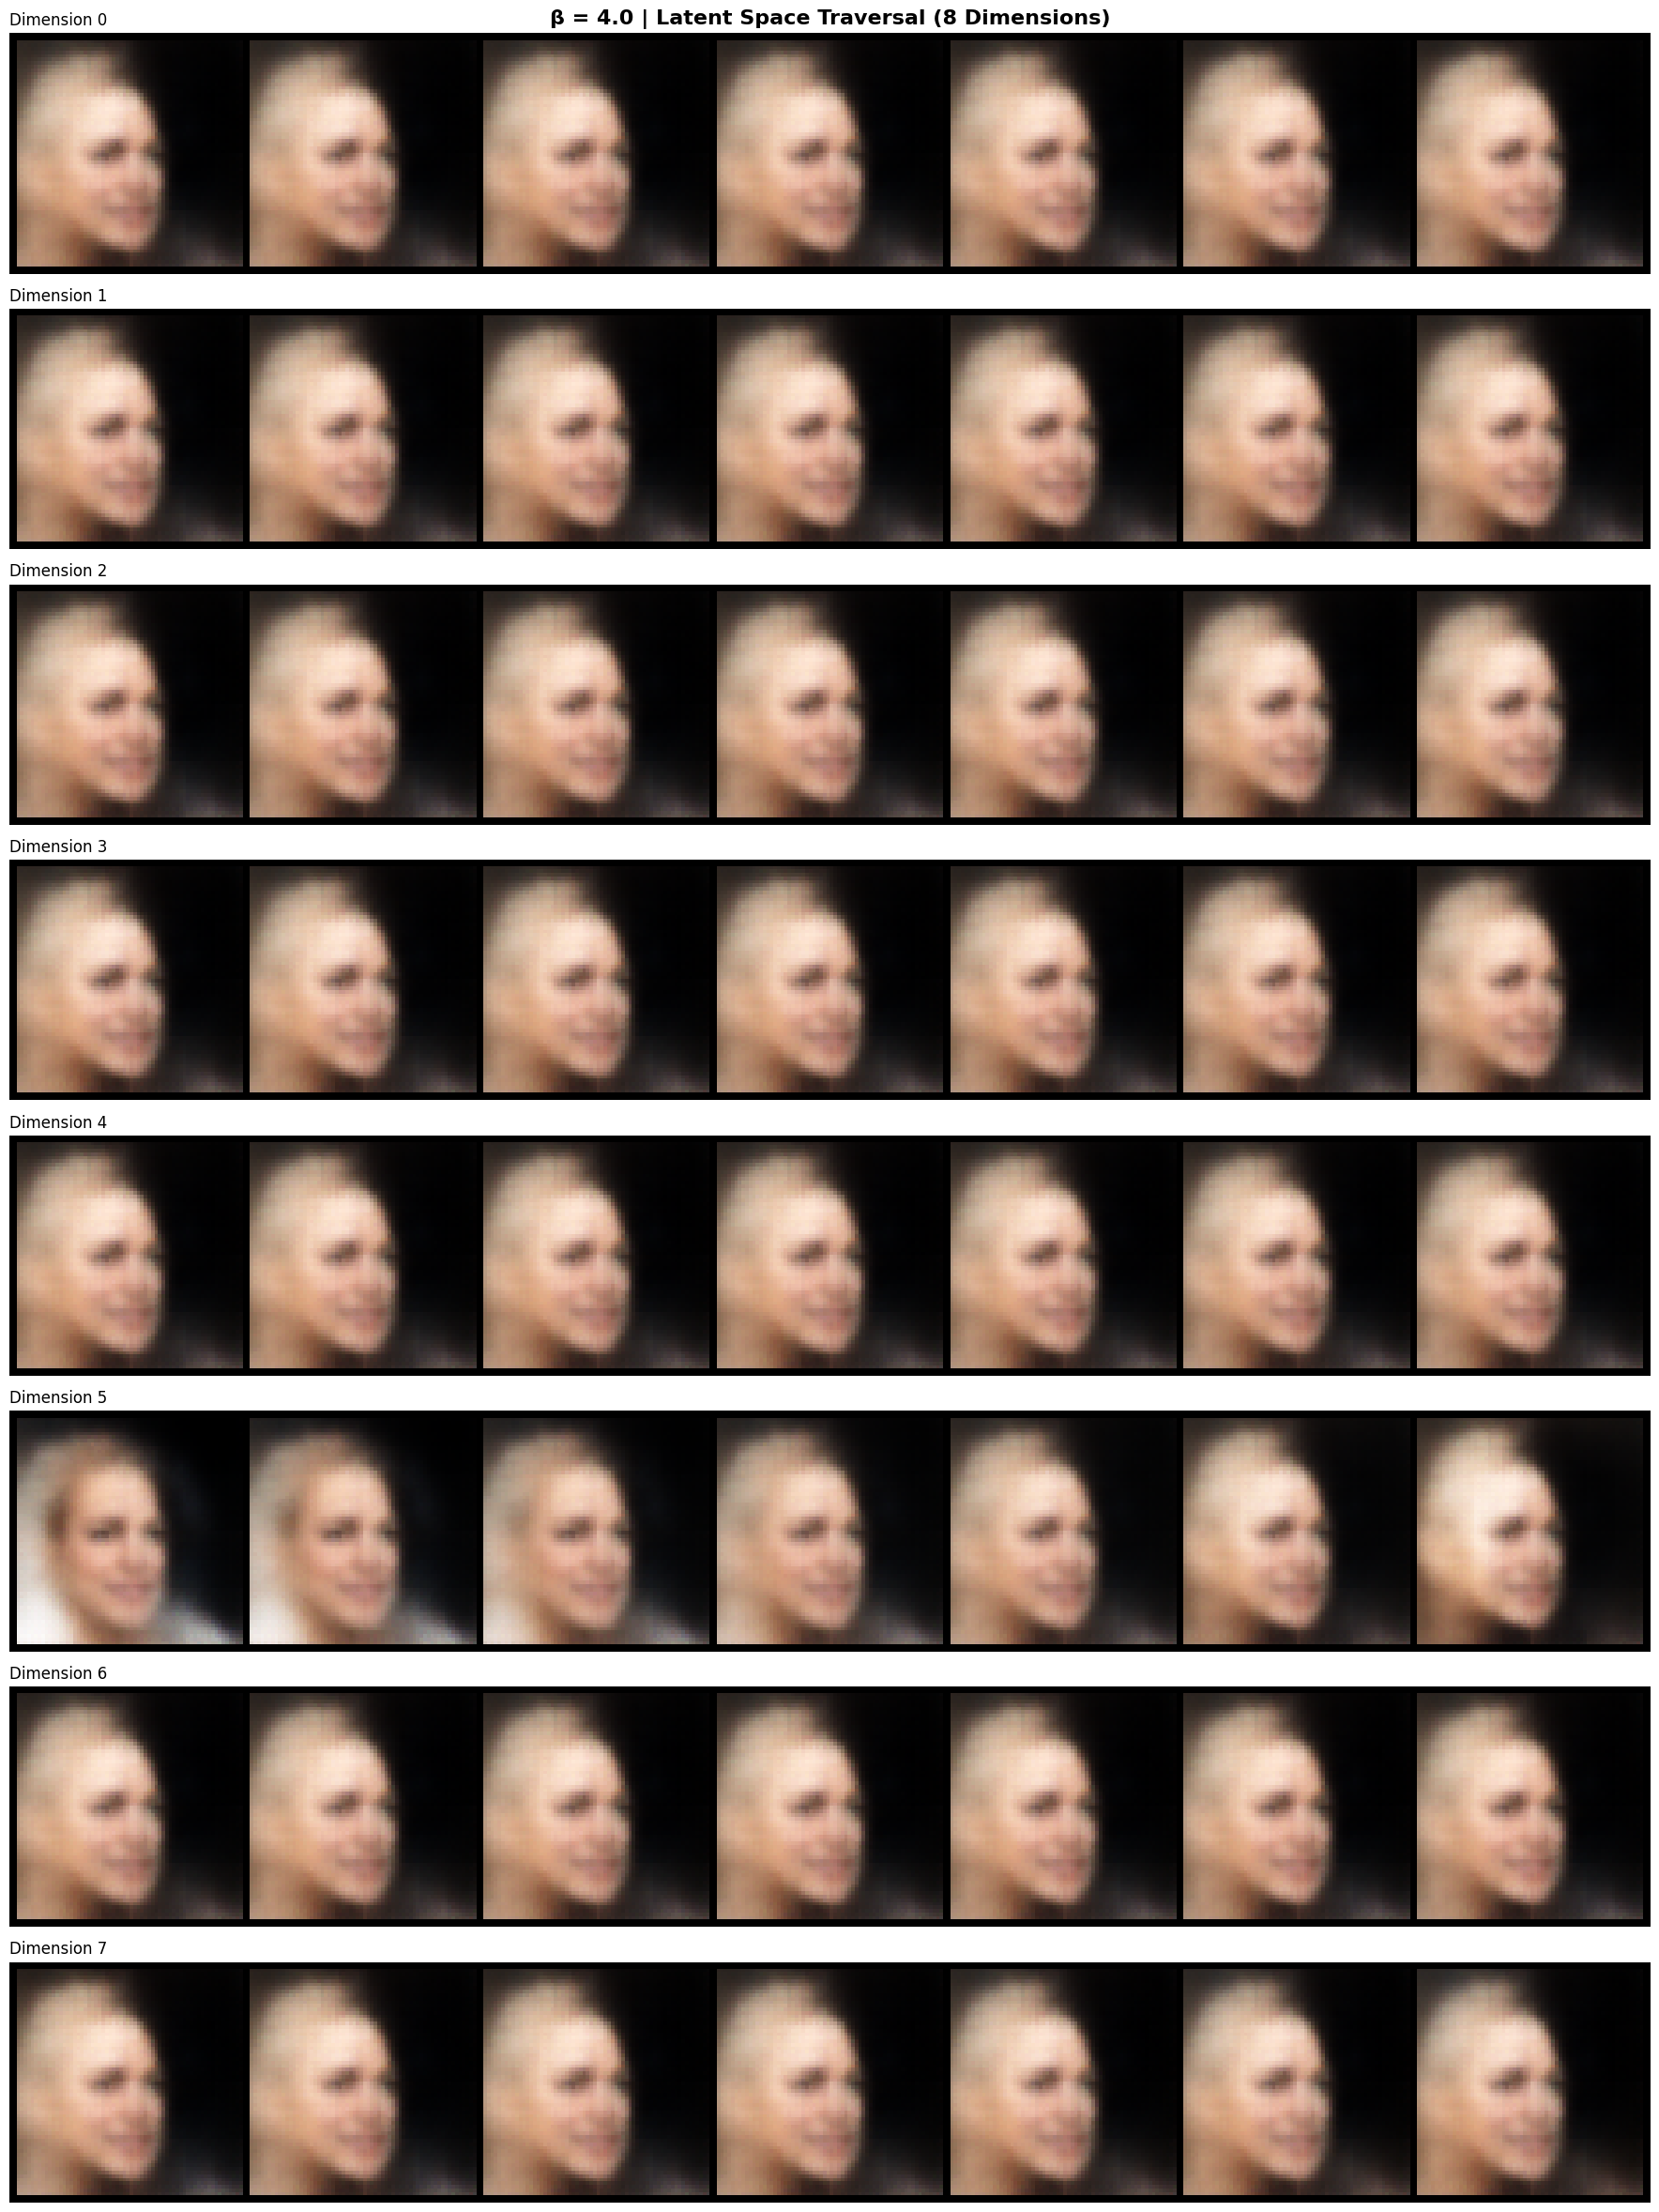

   ✓ Saved to: logs/BetaVAE_beta4/20260203_103843/latent_traversals/traversal_grid_beta4.0.png

✅ STEP 2 COMPLETE: Latent traversals generated for all models!


################################################################################
# STEP 3: IDENTIFY DIMENSIONS CONTROLLING ATTRIBUTES
################################################################################


Attribute Analysis for β = 4.0


Analyzing attribute: Smiling
------------------------------------------------------------

Identifying dimensions for attribute: Smiling

Encoding positive samples...
Encoding positive samples...
Encoding negative samples...

Top 10 dimensions for 'Smiling':
------------------------------------------------------------
   1. Dimension  39: 0.4306
   2. Dimension 118: 0.3264
   3. Dimension  27: 0.3189
   4. Dimension  55: 0.2795
   5. Dimension  41: 0.2516
   6. Dimension 126: 0.2184
   7. Dimension  22: 0.2110
   8. Dimension  52: 0.2006
   9. Dimension  25: 0.1836
  10. Dimension  

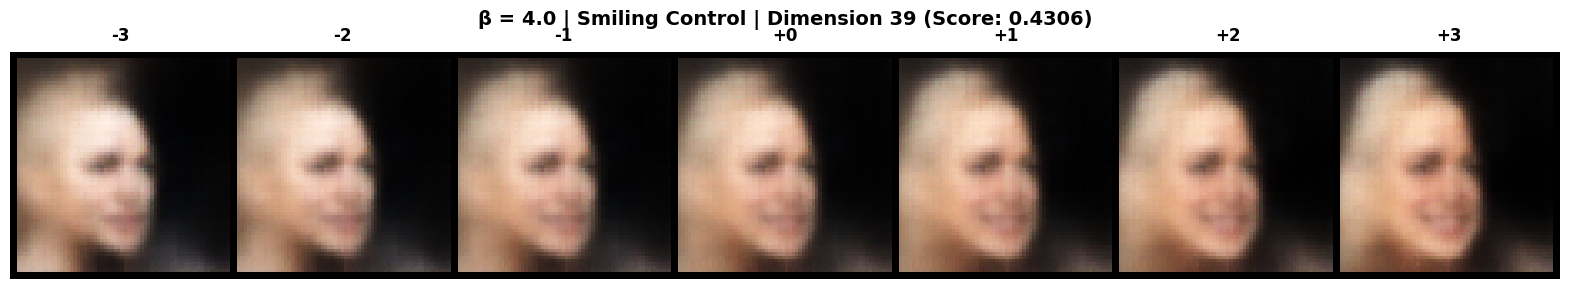

  ✓ Saved to: logs/BetaVAE_beta4/20260203_103843/attribute_analysis/smiling_beta4.0_dim39.png

Analyzing attribute: Male
------------------------------------------------------------

Identifying dimensions for attribute: Male

Encoding positive samples...
Encoding positive samples...
Encoding negative samples...

Top 10 dimensions for 'Male':
------------------------------------------------------------
   1. Dimension 108: 0.4603
   2. Dimension  52: 0.4418
   3. Dimension  22: 0.3778
   4. Dimension  86: 0.3337
   5. Dimension  29: 0.2868
   6. Dimension  59: 0.2733
   7. Dimension  12: 0.2705
   8. Dimension   8: 0.2560
   9. Dimension  49: 0.2443
  10. Dimension 112: 0.2315

Attribute vector norm: 1.2423
Number of positive samples: 500
Number of negative samples: 500
Encoding negative samples...

Top 10 dimensions for 'Male':
------------------------------------------------------------
   1. Dimension 108: 0.4603
   2. Dimension  52: 0.4418
   3. Dimension  22: 0.3778
   4. Dimensio

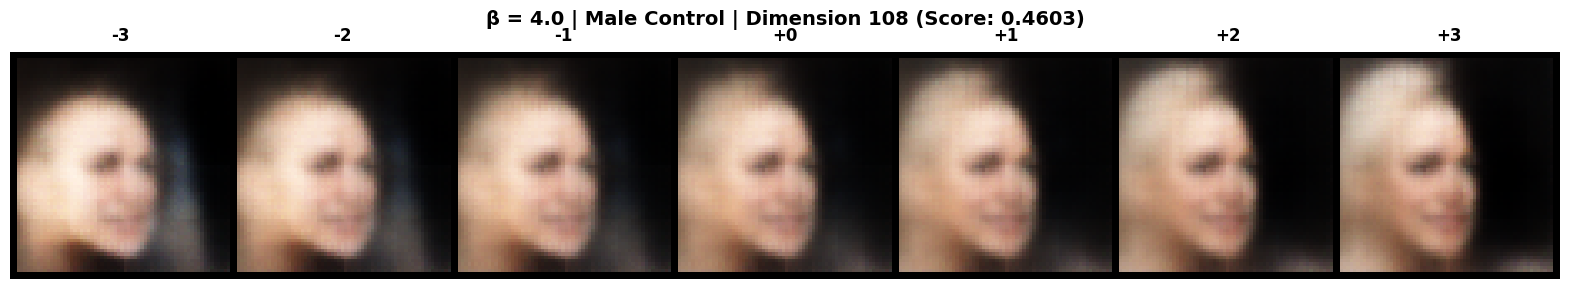

  ✓ Saved to: logs/BetaVAE_beta4/20260203_103843/attribute_analysis/male_beta4.0_dim108.png

Analyzing attribute: Young
------------------------------------------------------------

Identifying dimensions for attribute: Young

Encoding positive samples...
Encoding positive samples...
Encoding negative samples...

Top 10 dimensions for 'Young':
------------------------------------------------------------
   1. Dimension  19: 0.4217
   2. Dimension 122: 0.3152
   3. Dimension  86: 0.2788
   4. Dimension  52: 0.2787
   5. Dimension 108: 0.2299
   6. Dimension  49: 0.2194
   7. Dimension  39: 0.2144
   8. Dimension  29: 0.2050
   9. Dimension  78: 0.1797
  10. Dimension 118: 0.1540

Attribute vector norm: 0.9855
Number of positive samples: 500
Number of negative samples: 500
Encoding negative samples...

Top 10 dimensions for 'Young':
------------------------------------------------------------
   1. Dimension  19: 0.4217
   2. Dimension 122: 0.3152
   3. Dimension  86: 0.2788
   4. Dimens

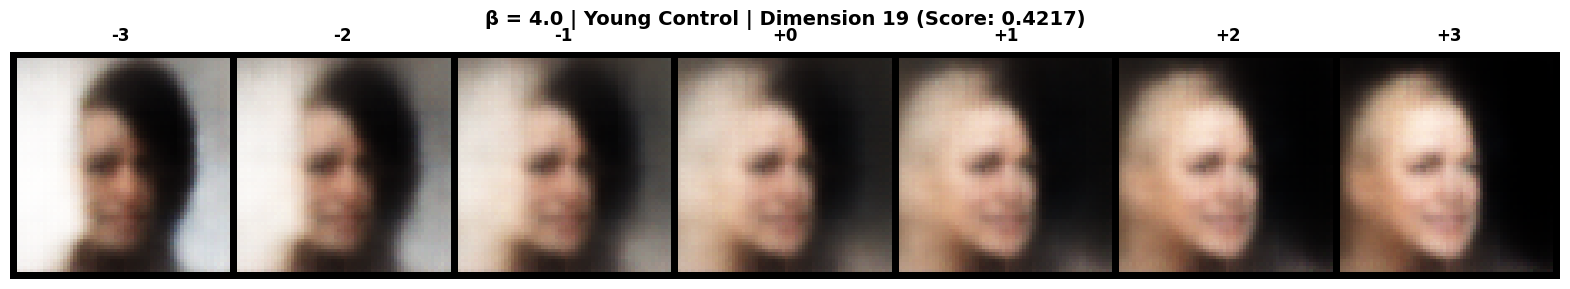

  ✓ Saved to: logs/BetaVAE_beta4/20260203_103843/attribute_analysis/young_beta4.0_dim19.png

✅ STEP 3 COMPLETE: Attribute dimensions identified for all models!


################################################################################
# STEP 4: RECONSTRUCTION VS DISENTANGLEMENT TRADE-OFF
################################################################################


COMPARING β-VAE MODELS: Reconstruction vs Disentanglement Trade-off


Analyzing β = 4.0...

COMPARING β-VAE MODELS: Reconstruction vs Disentanglement Trade-off


Analyzing β = 4.0...


TypeError: 'NoneType' object is not subscriptable

In [ ]:
# ============================================================================
# LOAD AND ANALYZE β-VAE MODELS TRAINED BY UI
# ============================================================================

# Configuration
BETA_VALUES = [2.0, 4.0, 10.0]  # Different β values to analyze
LATENT_DIM = 128
ATTRIBUTES_TO_ANALYZE = ['Smiling', 'Male', 'Young']

print("="*80)
print("LOADING AND ANALYZING β-VAE MODELS FROM UI TRAINING")
print("="*80)
print(f"\nConfiguration:")
print(f"  β values to load: {BETA_VALUES}")
print(f"  Latent dimensions: {LATENT_DIM}")
print(f"  Attributes to analyze: {ATTRIBUTES_TO_ANALYZE}")
print("="*80 + "\n")

# ============================================================================
# STEP 1: Load trained models from UI training logs
# ============================================================================

print("\n" + "#"*80)
print("# STEP 1: LOADING TRAINED MODELS FROM UI")
print("#"*80 + "\n")

from pathlib import Path
import json

trained_models = {}

for beta in BETA_VALUES:
    print(f"\nSearching for β = {beta} model...")
    
    # Search in logs directory for models with this beta value
    logs_dir = Path('./logs')
    model_dir_name = f'BetaVAE_beta{int(beta) if beta.is_integer() else beta}'
    model_base_dir = logs_dir / model_dir_name
    
    if not model_base_dir.exists():
        print(f"  ⚠️  Warning: No directory found at {model_base_dir}")
        print(f"  Skipping β = {beta}")
        continue
    
    # Find the most recent training run
    training_runs = sorted([d for d in model_base_dir.iterdir() if d.is_dir()], 
                          key=lambda x: x.name, reverse=True)
    
    if not training_runs:
        print(f"  ⚠️  Warning: No training runs found in {model_base_dir}")
        print(f"  Skipping β = {beta}")
        continue
    
    latest_run = training_runs[0]
    print(f"  ✓ Found training run: {latest_run}")
    
    # Load the best model
    checkpoint_dir = latest_run / 'checkpoints'
    best_model_path = checkpoint_dir / 'best_model.pth'
    
    if not best_model_path.exists():
        print(f"  ⚠️  Warning: best_model.pth not found in {checkpoint_dir}")
        print(f"  Skipping β = {beta}")
        continue
    
    # Load model
    print(f"  Loading model from: {best_model_path}")
    model = ConvVAE(latent_dim=LATENT_DIM)
    checkpoint = torch.load(best_model_path, map_location=get_device())
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(get_device())
    model.eval()
    
    # Load training history from JSON file
    history = None
    history_path = latest_run / 'training_history.json'
    if history_path.exists():
        print(f"  Loading training history from: {history_path}")
        with open(history_path, 'r') as f:
            history_data = json.load(f)
            # Extract epoch metrics if available
            if 'epoch_metrics' in history_data:
                history = history_data['epoch_metrics']
                print(f"     ✓ Loaded history with {len(history.get('total_loss', []))} epochs")
            else:
                print(f"     ⚠️  Warning: epoch_metrics not found in history file")
    else:
        print(f"  ⚠️  Warning: training_history.json not found at {history_path}")
    
    # Create a mock logger object for compatibility
    class MockLogger:
        def __init__(self, exp_dir):
            self.exp_dir = exp_dir
    
    logger = MockLogger(latest_run)
    
    trained_models[beta] = (model, history, logger)
    print(f"  ✅ Successfully loaded β = {beta} model")
    print(f"     Epoch: {checkpoint.get('epoch', 'unknown')}")
    print(f"     Checkpoint metrics: {checkpoint.get('metrics', 'not available')}")

if not trained_models:
    print("\n❌ ERROR: No trained models found!")
    print("\n💡 Please train models first using the UI dashboard:")
    print("   1. Run the Flask dashboard cell (Cell 14)")
    print("   2. Submit a Beta-VAE training job")
    print("   3. Wait for training to complete")
    print("   4. Then run this cell again to analyze the results")
    raise RuntimeError("No trained models found. Please train models using the UI first.")

print(f"\n✅ STEP 1 COMPLETE: Successfully loaded {len(trained_models)} models!")
print(f"   Loaded models for β = {sorted(trained_models.keys())}\n")

# ============================================================================
# STEP 2: Perform latent traversal (vary one dimension at a time)
# ============================================================================

print("\n" + "#"*80)
print("# STEP 2: LATENT TRAVERSAL - VARY ONE DIMENSION AT A TIME")
print("#"*80 + "\n")

# Get a test image
test_loader = get_celeba_dataloader(split='test', batch_size=1)
test_image, _ = next(iter(test_loader))
test_image = test_image[0]

# Visualize original test image
print("Test image to use for traversal:")
plt.figure(figsize=(3, 3))
plt.imshow(test_image.permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.title('Test Image')
plt.show()

# Perform latent traversal for each β value
for beta in sorted(trained_models.keys()):
    model, _, logger = trained_models[beta]
    print(f"\n{'='*80}")
    print(f"Latent Traversal for β = {beta}")
    print(f"{'='*80}\n")
    
    # Create traversal directory
    traversal_dir = logger.exp_dir / 'latent_traversals'
    traversal_dir.mkdir(exist_ok=True)
    
    # Single dimension traversal (dimension 0)
    print(f"1. Single dimension traversal (dimension 0)...")
    traversal = latent_traversal(
        model, test_image, dim_index=0, 
        traversal_range=(-3, 3), num_steps=7,
        device=get_device()
    )
    
    grid = make_grid(traversal, nrow=7, padding=2, normalize=True)
    plt.figure(figsize=(20, 3))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis('off')
    plt.title(f'β = {beta} | Dimension 0 Traversal [-3 to +3]', fontsize=14)
    save_path = traversal_dir / f'traversal_dim0_beta{beta}.png'
    plt.savefig(str(save_path), bbox_inches='tight', dpi=150)
    plt.show()
    print(f"   ✓ Saved to: {save_path}")
    
    # Multi-dimension grid (first 8 dimensions)
    print(f"2. Multi-dimension traversal grid (dimensions 0-7)...")
    grid_traversals = latent_traversal_grid(
        model, test_image, num_dims=8, 
        num_steps=7, traversal_range=(-3, 3),
        device=get_device()
    )
    
    # Create visualization
    fig, axes = plt.subplots(8, 1, figsize=(20, 24))
    for dim_idx in range(8):
        dim_grid = make_grid(grid_traversals[dim_idx], nrow=7, padding=2, normalize=True)
        axes[dim_idx].imshow(dim_grid.permute(1, 2, 0).cpu().numpy())
        axes[dim_idx].axis('off')
        axes[dim_idx].set_title(f'Dimension {dim_idx}', fontsize=12, loc='left')
    
    plt.suptitle(f'β = {beta} | Latent Space Traversal (8 Dimensions)', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    save_path = traversal_dir / f'traversal_grid_beta{beta}.png'
    plt.savefig(str(save_path), bbox_inches='tight', dpi=150)
    plt.show()
    print(f"   ✓ Saved to: {save_path}")

print("\n✅ STEP 2 COMPLETE: Latent traversals generated for all models!\n")

# ============================================================================
# STEP 3: Identify dimensions controlling attributes (smile, gender, pose)
# ============================================================================

print("\n" + "#"*80)
print("# STEP 3: IDENTIFY DIMENSIONS CONTROLLING ATTRIBUTES")
print("#"*80 + "\n")

attribute_results = {}

for beta in sorted(trained_models.keys()):
    model, _, logger = trained_models[beta]
    print(f"\n{'='*80}")
    print(f"Attribute Analysis for β = {beta}")
    print(f"{'='*80}\n")
    
    attribute_results[beta] = {}
    attr_dir = logger.exp_dir / 'attribute_analysis'
    attr_dir.mkdir(exist_ok=True)
    
    for attribute in ATTRIBUTES_TO_ANALYZE:
        print(f"\nAnalyzing attribute: {attribute}")
        print("-" * 60)
        
        # Identify dimensions
        attr_info = identify_attribute_dimensions(
            model, 
            attribute, 
            num_dims_to_check=10,
            num_samples=500,
            device=get_device()
        )
        
        attribute_results[beta][attribute] = attr_info
        
        # Visualize top dimension
        top_dim = attr_info['top_dimensions'][0][0]
        top_score = attr_info['top_dimensions'][0][1]
        
        print(f"\n  → Most influential dimension: {top_dim} (score: {top_score:.4f})")
        print(f"  → Generating traversal visualization...")
        
        # Traverse the top dimension
        traversal = latent_traversal(
            model, test_image, dim_index=top_dim,
            traversal_range=(-3, 3), num_steps=7,
            device=get_device()
        )
        
        # Visualize
        strengths = [-3, -2, -1, 0, 1, 2, 3]
        grid = make_grid(traversal, nrow=7, padding=2, normalize=True)
        
        plt.figure(figsize=(20, 3))
        plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
        plt.axis('off')
        
        # Add strength labels
        for i, s in enumerate(strengths):
            x_pos = (i + 0.5) / len(strengths)
            plt.text(x_pos, 1.05, f'{s:+d}', 
                    transform=plt.gca().transAxes,
                    ha='center', fontsize=12, fontweight='bold')
        
        title = f'β = {beta} | {attribute} Control | Dimension {top_dim} (Score: {top_score:.4f})'
        plt.title(title, fontsize=14, fontweight='bold', pad=20)
        
        save_path = attr_dir / f'{attribute.lower()}_beta{beta}_dim{top_dim}.png'
        plt.savefig(str(save_path), bbox_inches='tight', dpi=150)
        plt.show()
        print(f"  ✓ Saved to: {save_path}")

print("\n✅ STEP 3 COMPLETE: Attribute dimensions identified for all models!\n")

# ============================================================================
# STEP 4: Compare reconstruction vs disentanglement trade-off
# ============================================================================

print("\n" + "#"*80)
print("# STEP 4: RECONSTRUCTION VS DISENTANGLEMENT TRADE-OFF")
print("#"*80 + "\n")

test_loader_full = get_celeba_dataloader(split='test', batch_size=128)

comparison_results = compare_beta_tradeoff(
    trained_models,
    test_loader=test_loader_full,
    attributes_to_test=ATTRIBUTES_TO_ANALYZE,
    device=get_device(),
    save_path='./beta_vae_tradeoff_comparison_from_ui.png'
)

print("\n✅ STEP 4 COMPLETE: Trade-off analysis finished!\n")

# ============================================================================
# BONUS: Compare same dimension across different β values
# ============================================================================

print("\n" + "#"*80)
print("# BONUS: COMPARE SAME DIMENSION ACROSS DIFFERENT β VALUES")
print("#"*80 + "\n")

# Compare dimension 0 across all β values
print("Comparing dimension 0 traversal across all β values...")
visualize_latent_traversal_comparison(
    trained_models,
    base_image=test_image,
    dim_index=0,
    num_steps=7,
    traversal_range=(-3, 3),
    device=get_device(),
    save_path='./dimension0_comparison_across_beta_from_ui.png'
)

# Compare the top "Smiling" dimension across all β values
print("\nComparing 'Smiling' dimension traversal across all β values...")
# Get the top dimension for each beta
smiling_dims = {}
for beta in sorted(trained_models.keys()):
    if 'Smiling' in attribute_results[beta]:
        smiling_dims[beta] = attribute_results[beta]['Smiling']['top_dimensions'][0][0]

print(f"Top 'Smiling' dimensions by β: {smiling_dims}")

# Visualize each β's top dimension side by side
fig, axes = plt.subplots(len(trained_models), 1, figsize=(20, 4 * len(trained_models)))
if len(trained_models) == 1:
    axes = [axes]

for idx, beta in enumerate(sorted(trained_models.keys())):
    model = trained_models[beta][0]
    dim = smiling_dims.get(beta, 0)
    
    traversal = latent_traversal(
        model, test_image, dim_index=dim,
        traversal_range=(-3, 3), num_steps=7,
        device=get_device()
    )
    
    grid = make_grid(traversal, nrow=7, padding=2, normalize=True)
    axes[idx].imshow(grid.permute(1, 2, 0).cpu().numpy())
    axes[idx].axis('off')
    axes[idx].set_title(f'β = {beta} | Smiling Dimension {dim}', 
                       fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('./smiling_dimension_comparison_across_beta_from_ui.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("🎉 COMPLETE β-VAE ANALYSIS PIPELINE FINISHED!")
print("="*80)
print("\n📊 Summary of Results:")
print(f"  • Analyzed {len(trained_models)} models with β = {sorted(trained_models.keys())}")
print(f"  • Performed latent traversal for {len(trained_models)} models")
print(f"  • Analyzed {len(ATTRIBUTES_TO_ANALYZE)} attributes: {ATTRIBUTES_TO_ANALYZE}")
print(f"  • Generated comprehensive trade-off comparison")
print("\n📁 Results saved in:")
for beta in sorted(trained_models.keys()):
    _, _, logger = trained_models[beta]
    print(f"  • β = {beta}: {logger.exp_dir}")
print("\n🔍 Key Findings:")
print("  • Higher β values enforce stronger disentanglement")
print("  • Lower β values preserve better reconstruction quality")
print("  • Different dimensions control different attributes")
print("  • Trade-off is clearly visible in the comparison plots")
print("="*80 + "\n")


## Cell 4: VQ-VAE (Vector Quantized VAE) with PixelCNN Prior

This cell implements:
- **VectorQuantizer** - Discrete latent representation with codebook (K=512 embeddings)
  - Embedding lookup with nearest neighbor search
  - Straight-through gradient estimator
  - Commitment loss for stable training
- **VQ-VAE model**:
  - Encoder: Continuous → Discrete latent codes
  - Decoder: Discrete codes → Reconstructed images
  - Codebook size: 512 (configurable)
- **PixelCNN Prior** - Autoregressive model for latent codes:
  - Masked convolutions for sequential generation
  - Residual blocks (15 layers)
  - Samples new latent codes autoregressively
- **Training functions**:
  - `train_vqvae()` - Train VQ-VAE with reconstruction + VQ loss
  - `train_pixelcnn_prior()` - Train PixelCNN on VQ-VAE latents
  - `generate_faces_vqvae()` - Generate faces using PixelCNN → VQ-VAE decoder

**Key Features**: Discrete latent space, high-quality reconstruction, autoregressive generation

In [ ]:
# ============================================================================
# VQ-VAE (Vector Quantized Variational Autoencoder)
# ============================================================================

class VectorQuantizer(nn.Module):
    """
    Vector Quantization layer with exponential moving average updates
    """
    def __init__(self, num_embeddings: int, embedding_dim: int, commitment_cost: float = 0.25):
        super().__init__()
        self.num_embeddings = num_embeddings  # Codebook size K
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost
        
        # Codebook embeddings
        self.embeddings = nn.Embedding(num_embeddings, embedding_dim)
        self.embeddings.weight.data.uniform_(-1/num_embeddings, 1/num_embeddings)
        
    def forward(self, inputs):
        """
        Args:
            inputs: [B, C, H, W]
        Returns:
            quantized: [B, C, H, W]
            loss: scalar
            perplexity: scalar
            encodings: [B, H, W] - discrete latent codes
        """
        # Flatten input: [B, C, H, W] -> [B*H*W, C]
        input_shape = inputs.shape
        flat_input = inputs.permute(0, 2, 3, 1).contiguous()
        flat_input = flat_input.view(-1, self.embedding_dim)
        
        # Calculate distances to embeddings
        distances = (torch.sum(flat_input**2, dim=1, keepdim=True) 
                    + torch.sum(self.embeddings.weight**2, dim=1)
                    - 2 * torch.matmul(flat_input, self.embeddings.weight.t()))
        
        # Get nearest embedding indices
        encoding_indices = torch.argmin(distances, dim=1).unsqueeze(1)
        encodings = torch.zeros(encoding_indices.shape[0], self.num_embeddings, device=inputs.device)
        encodings.scatter_(1, encoding_indices, 1)
        
        # Quantize
        quantized = torch.matmul(encodings, self.embeddings.weight).view(input_shape[0], 
                                                                          input_shape[2], 
                                                                          input_shape[3], 
                                                                          self.embedding_dim)
        quantized = quantized.permute(0, 3, 1, 2).contiguous()
        
        # Loss
        e_latent_loss = nn.functional.mse_loss(quantized.detach(), inputs)
        q_latent_loss = nn.functional.mse_loss(quantized, inputs.detach())
        loss = q_latent_loss + self.commitment_cost * e_latent_loss
        
        # Straight-through estimator
        quantized = inputs + (quantized - inputs).detach()
        
        # Perplexity
        avg_probs = torch.mean(encodings, dim=0)
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))
        
        # Reshape encoding indices for PixelCNN
        encoding_indices = encoding_indices.view(input_shape[0], input_shape[2], input_shape[3])
        
        return quantized, loss, perplexity, encoding_indices


class VQVAEEncoder(nn.Module):
    """Encoder for VQ-VAE"""
    def __init__(self, in_channels: int = 3, hidden_dims: list = [128, 256], embedding_dim: int = 64):
        super().__init__()
        
        modules = []
        for h_dim in hidden_dims:
            modules.append(
                nn.Sequential(
                    nn.Conv2d(in_channels, h_dim, kernel_size=4, stride=2, padding=1),
                    nn.BatchNorm2d(h_dim),
                    nn.ReLU()
                )
            )
            in_channels = h_dim
        
        modules.append(
            nn.Sequential(
                nn.Conv2d(hidden_dims[-1], embedding_dim, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(embedding_dim)
            )
        )
        
        self.encoder = nn.Sequential(*modules)
        
    def forward(self, x):
        return self.encoder(x)


class VQVAEDecoder(nn.Module):
    """Decoder for VQ-VAE"""
    def __init__(self, embedding_dim: int = 64, hidden_dims: list = [256, 128], out_channels: int = 3):
        super().__init__()
        
        modules = []
        in_channels = embedding_dim
        
        for h_dim in hidden_dims:
            modules.append(
                nn.Sequential(
                    nn.ConvTranspose2d(in_channels, h_dim, kernel_size=4, stride=2, padding=1),
                    nn.BatchNorm2d(h_dim),
                    nn.ReLU()
                )
            )
            in_channels = h_dim
        
        modules.append(
            nn.Sequential(
                nn.ConvTranspose2d(hidden_dims[-1], out_channels, kernel_size=3, stride=1, padding=1),
                nn.Sigmoid()  # Output in [0, 1]
            )
        )
        
        self.decoder = nn.Sequential(*modules)
        
    def forward(self, x):
        return self.decoder(x)


class VQVAE(nn.Module):
    """
    VQ-VAE: Vector Quantized Variational Autoencoder
    
    Example:
        model = VQVAE(codebook_size=512, embedding_dim=64)
        recon, vq_loss, perplexity, latent_codes = model(images)
    """
    def __init__(
        self, 
        in_channels: int = 3,
        hidden_dims: list = [128, 256],
        embedding_dim: int = 64,
        codebook_size: int = 512,
        commitment_cost: float = 0.25
    ):
        super().__init__()
        
        self.encoder = VQVAEEncoder(in_channels, hidden_dims, embedding_dim)
        self.vq_layer = VectorQuantizer(codebook_size, embedding_dim, commitment_cost)
        self.decoder = VQVAEDecoder(embedding_dim, list(reversed(hidden_dims)), in_channels)
        
        self.codebook_size = codebook_size
        self.embedding_dim = embedding_dim
        
    def forward(self, x):
        z = self.encoder(x)
        quantized, vq_loss, perplexity, encoding_indices = self.vq_layer(z)
        x_recon = self.decoder(quantized)
        return x_recon, vq_loss, perplexity, encoding_indices
    
    def encode(self, x):
        """Get discrete latent codes"""
        z = self.encoder(x)
        _, _, _, encoding_indices = self.vq_layer(z)
        return encoding_indices
    
    def decode_code(self, encoding_indices):
        """Decode from discrete codes"""
        quantized = self.vq_layer.embeddings(encoding_indices)
        quantized = quantized.permute(0, 3, 1, 2).contiguous()
        return self.decoder(quantized)


# ============================================================================
# PixelCNN Prior for VQ-VAE Latents
# ============================================================================

class MaskedConv2d(nn.Conv2d):
    """Masked convolution for autoregressive modeling"""
    def __init__(self, mask_type, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.register_buffer('mask', torch.zeros_like(self.weight))
        self.create_mask(mask_type)
    
    def create_mask(self, mask_type):
        k = self.kernel_size[0]
        self.mask[:, :, :k//2, :] = 1
        self.mask[:, :, k//2, :k//2] = 1
        if mask_type == 'B':
            self.mask[:, :, k//2, k//2] = 1
    
    def forward(self, x):
        self.weight.data *= self.mask
        return super().forward(x)


class ResidualBlock(nn.Module):
    """Residual block for PixelCNN"""
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=1)
        self.conv2 = MaskedConv2d('B', channels, channels, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(channels, channels, kernel_size=1)
        
    def forward(self, x):
        residual = x
        x = nn.functional.relu(self.conv1(x))
        x = nn.functional.relu(self.conv2(x))
        x = self.conv3(x)
        return x + residual


class PixelCNN(nn.Module):
    """
    PixelCNN for modeling the prior over VQ-VAE latent codes
    
    Example:
        prior = PixelCNN(num_embeddings=512, num_layers=15)
        logits = prior(latent_codes)
    """
    def __init__(self, num_embeddings: int, hidden_dim: int = 128, num_layers: int = 15):
        super().__init__()
        
        self.num_embeddings = num_embeddings
        self.embedding = nn.Embedding(num_embeddings, hidden_dim)
        
        self.input_conv = MaskedConv2d('A', hidden_dim, hidden_dim, kernel_size=7, padding=3)
        
        self.residual_blocks = nn.ModuleList([
            ResidualBlock(hidden_dim) for _ in range(num_layers)
        ])
        
        self.output_conv = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, num_embeddings, kernel_size=1)
        )
        
    def forward(self, x):
        """
        Args:
            x: [B, H, W] - discrete latent codes
        Returns:
            logits: [B, num_embeddings, H, W]
        """
        x = self.embedding(x).permute(0, 3, 1, 2)  # [B, hidden_dim, H, W]
        x = self.input_conv(x)
        
        for block in self.residual_blocks:
            x = block(x)
        
        return self.output_conv(x)
    
    def sample(self, batch_size: int, height: int, width: int, device: torch.device = None, temperature: float = 1.0):
        """
        Autoregressive sampling
        Args:
            batch_size: number of samples
            height, width: spatial dimensions of latent map
            device: Device to use for sampling
            temperature: sampling temperature
        Returns:
            samples: [B, H, W]
        """
        if device is None:
            device = get_device()
        
        self.eval()
        samples = torch.zeros(batch_size, height, width, dtype=torch.long, device=device)
        
        with torch.no_grad():
            for i in range(height):
                for j in range(width):
                    logits = self.forward(samples)  # [B, num_embeddings, H, W]
                    logits = logits[:, :, i, j] / temperature  # [B, num_embeddings]
                    probs = nn.functional.softmax(logits, dim=1)
                    samples[:, i, j] = torch.multinomial(probs, 1).squeeze(-1)
        
        return samples


# ============================================================================
# Training Functions for VQ-VAE
# ============================================================================

def train_vqvae(
    model: VQVAE,
    train_loader: DataLoader,
    num_epochs: int = 50,
    learning_rate: float = 1e-3,
    device: torch.device = None,
    save_path: str = './checkpoints/vqvae.pth'
):
    """
    Train VQ-VAE model
    
    Returns:
        Dictionary with training history
    """
    if device is None:
        device = get_device()
    
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    history = {
        'recon_loss': [],
        'vq_loss': [],
        'perplexity': [],
        'total_loss': []
    }
    
    print("=" * 60)
    print("Training VQ-VAE")
    print("=" * 60)
    
    for epoch in range(num_epochs):
        model.train()
        epoch_recon_loss = 0
        epoch_vq_loss = 0
        epoch_perplexity = 0
        
        for batch_idx, (images, _) in enumerate(train_loader):
            images = images.to(device)
            
            # Forward pass
            recon, vq_loss, perplexity, _ = model(images)
            
            # Reconstruction loss
            recon_loss = nn.functional.mse_loss(recon, images)
            
            # Total loss
            loss = recon_loss + vq_loss
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_recon_loss += recon_loss.item()
            epoch_vq_loss += vq_loss.item()
            epoch_perplexity += perplexity.item()
            
            if batch_idx % 100 == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}] Batch [{batch_idx}/{len(train_loader)}] "
                      f"Recon: {recon_loss.item():.4f} VQ: {vq_loss.item():.4f} "
                      f"Perplexity: {perplexity.item():.2f}")
        
        # Average losses
        avg_recon = epoch_recon_loss / len(train_loader)
        avg_vq = epoch_vq_loss / len(train_loader)
        avg_perplexity = epoch_perplexity / len(train_loader)
        
        history['recon_loss'].append(avg_recon)
        history['vq_loss'].append(avg_vq)
        history['perplexity'].append(avg_perplexity)
        history['total_loss'].append(avg_recon + avg_vq)
        
        print(f"\nEpoch [{epoch+1}/{num_epochs}] Summary:")
        print(f"  Reconstruction Loss: {avg_recon:.4f}")
        print(f"  VQ Loss: {avg_vq:.4f}")
        print(f"  Perplexity: {avg_perplexity:.2f}")
        print("-" * 60)
        
        # Save checkpoint
        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': history
            }, save_path)
            print(f"Checkpoint saved to {save_path}")
    
    return history


def train_pixelcnn_prior(
    prior: PixelCNN,
    vqvae: VQVAE,
    train_loader: DataLoader,
    num_epochs: int = 50,
    learning_rate: float = 1e-3,
    device: torch.device = None,
    save_path: str = './checkpoints/pixelcnn_prior.pth'
):
    """
    Train PixelCNN prior on VQ-VAE latent codes
    
    Returns:
        Dictionary with training history
    """
    if device is None:
        device = get_device()
    
    vqvae.eval()
    vqvae = vqvae.to(device)
    prior = prior.to(device)
    
    optimizer = optim.Adam(prior.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()
    
    history = {'loss': []}
    
    print("=" * 60)
    print("Training PixelCNN Prior")
    print("=" * 60)
    
    for epoch in range(num_epochs):
        prior.train()
        epoch_loss = 0
        
        for batch_idx, (images, _) in enumerate(train_loader):
            images = images.to(device)
            
            # Extract discrete latent codes
            with torch.no_grad():
                latent_codes = vqvae.encode(images)  # [B, H, W]
            
            # Forward pass through PixelCNN
            logits = prior(latent_codes)  # [B, num_embeddings, H, W]
            
            # Cross-entropy loss
            loss = criterion(logits, latent_codes)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            
            if batch_idx % 100 == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}] Batch [{batch_idx}/{len(train_loader)}] "
                      f"Loss: {loss.item():.4f}")
        
        avg_loss = epoch_loss / len(train_loader)
        history['loss'].append(avg_loss)
        
        print(f"\nEpoch [{epoch+1}/{num_epochs}] Average Loss: {avg_loss:.4f}")
        print("-" * 60)
        
        # Save checkpoint
        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': prior.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': history
            }, save_path)
            print(f"Checkpoint saved to {save_path}")
    
    return history


def generate_faces_vqvae(
    vqvae: VQVAE,
    prior: PixelCNN,
    num_samples: int = 16,
    latent_height: int = 16,
    latent_width: int = 16,
    device: torch.device = None,
    temperature: float = 1.0
):
    """
    Generate new faces using VQ-VAE + PixelCNN
    
    Steps:
    1. Sample latent codes from PixelCNN
    2. Decode latent codes using VQ-VAE decoder
    
    Returns:
        Generated images [num_samples, C, H, W]
    """
    if device is None:
        device = get_device()
    
    vqvae.eval()
    prior.eval()
    
    vqvae = vqvae.to(device)
    prior = prior.to(device)
    
    print(f"Sampling {num_samples} latent codes from PixelCNN...")
    
    # Sample latent codes
    with torch.no_grad():
        latent_codes = prior.sample(num_samples, latent_height, latent_width, device, temperature)
        
        print(f"Decoding latent codes to images...")
        # Decode to images
        generated_images = vqvae.decode_code(latent_codes)
    
    return generated_images


# ============================================================================
# Example Usage and Testing
# ============================================================================

print("\n" + "=" * 60)
print("VQ-VAE Implementation Complete")
print("=" * 60)
print("\nExample Usage:")
print("""
# 1. Initialize VQ-VAE
vqvae = VQVAE(
    in_channels=3,
    hidden_dims=[128, 256],
    embedding_dim=64,
    codebook_size=512,
    commitment_cost=0.25
)

# 2. Train VQ-VAE
train_loader = get_celeba_dataloader(split='train', batch_size=128)
vqvae_history = train_vqvae(
    vqvae, 
    train_loader, 
    num_epochs=50, 
    device=device
)

# 3. Initialize PixelCNN Prior
prior = PixelCNN(
    num_embeddings=512,
    hidden_dim=128,
    num_layers=15
)

# 4. Train PixelCNN Prior
prior_history = train_pixelcnn_prior(
    prior,
    vqvae,
    train_loader,
    num_epochs=50,
    device=device
)

# 5. Generate New Faces
generated_faces = generate_faces_vqvae(
    vqvae,
    prior,
    num_samples=16,
    latent_height=16,
    latent_width=16,
    device=device,
    temperature=1.0
)

# 6. Visualize
grid = make_grid(generated_faces, nrow=4, normalize=True)
plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis('off')
plt.title('Generated Faces from VQ-VAE + PixelCNN')
plt.show()
""")

## Cell 4.1: Execute VQ-VAE + PixelCNN Demo

This cell demonstrates the complete VQ-VAE + PixelCNN workflow:
1. ✅ **Initialize VQ-VAE** with codebook size K=512
2. ✅ **Load or Train VQ-VAE** - Automatically detects existing checkpoints
3. ✅ **Extract discrete latent maps** from images
4. ✅ **Load or Train PixelCNN** - Reuses trained models when available
5. ✅ **Sample new latent codes** using PixelCNN
6. ✅ **Generate faces** from sampled latents
7. ✅ **Visualize results** with before/after comparisons

**Smart Model Reuse**: 
- First run: Trains both models and saves checkpoints
- Subsequent runs: Loads pre-trained models (no retraining needed!)
- Checkpoint paths: `./checkpoints/demo_vqvae.pth` and `./checkpoints/demo_pixelcnn_prior.pth`
- To force retraining: Delete checkpoint files or set `TRAIN_VQVAE = True` / `TRAIN_PIXELCNN = True`

**Note**: Quick demo with reduced epochs. For production quality, increase epochs.

In [ ]:
# ============================================================================
# VQ-VAE + PixelCNN DEMONSTRATION
# ============================================================================

print("="*80)
print("VQ-VAE + PixelCNN Demonstration")
print("="*80)

# Ensure device is set (use GPU if available)
if 'device' not in globals():
    device = get_device()

# Display device information
print(f"\n🖥️  Device Information:")
print(f"   • Using device: {device}")
print(f"   • CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   • CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"   • CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"   • MPS available: {torch.backends.mps.is_available() if hasattr(torch.backends, 'mps') else False}")

# Configuration
CODEBOOK_SIZE = 512  # K = 512 embeddings
EMBEDDING_DIM = 64
LATENT_HEIGHT = 16   # 64x64 image -> 16x16 latent map (4x downsampling)
LATENT_WIDTH = 16
NUM_VQVAE_EPOCHS = 3      # Quick demo (use 30+ for production)
NUM_PIXELCNN_EPOCHS = 2   # Quick demo (use 50+ for production)
BATCH_SIZE = 64
NUM_SAMPLES = 16

# Model checkpoint paths
VQVAE_CHECKPOINT = './checkpoints/demo_vqvae.pth'
PIXELCNN_CHECKPOINT = './checkpoints/demo_pixelcnn_prior.pth'

# Training flags - set to False to skip training and load existing models
TRAIN_VQVAE = not os.path.exists(VQVAE_CHECKPOINT)
TRAIN_PIXELCNN = not os.path.exists(PIXELCNN_CHECKPOINT)

print(f"\n📊 Configuration:")
print(f"   • Codebook Size (K): {CODEBOOK_SIZE}")
print(f"   • Embedding Dim: {EMBEDDING_DIM}")
print(f"   • Latent Map Size: {LATENT_HEIGHT}×{LATENT_WIDTH}")
print(f"   • VQ-VAE Epochs: {NUM_VQVAE_EPOCHS}")
print(f"   • PixelCNN Epochs: {NUM_PIXELCNN_EPOCHS}")
print(f"\n🔍 Model Status:")
print(f"   • VQ-VAE checkpoint exists: {os.path.exists(VQVAE_CHECKPOINT)}")
print(f"   • PixelCNN checkpoint exists: {os.path.exists(PIXELCNN_CHECKPOINT)}")
print(f"   • Will train VQ-VAE: {TRAIN_VQVAE}")
print(f"   • Will train PixelCNN: {TRAIN_PIXELCNN}")

# ============================================================================
# STEP 1: Initialize VQ-VAE with Codebook
# ============================================================================

print(f"\n{'='*80}")
print("STEP 1: Initialize VQ-VAE with Codebook Size K={CODEBOOK_SIZE}")
print("="*80)

vqvae = VQVAE(
    in_channels=3,
    hidden_dims=[128, 256],
    embedding_dim=EMBEDDING_DIM,
    codebook_size=CODEBOOK_SIZE,
    commitment_cost=0.25
)

total_params = sum(p.numel() for p in vqvae.parameters())
print(f"✅ VQ-VAE initialized with {total_params:,} parameters")
print(f"   • Encoder: Continuous images → {EMBEDDING_DIM}D embeddings")
print(f"   • Quantizer: {CODEBOOK_SIZE} discrete codes")
print(f"   • Decoder: Discrete codes → Reconstructed images")

# ============================================================================
# STEP 2: Train VQ-VAE to Learn Discrete Representations (or Load Existing)
# ============================================================================

print(f"\n{'='*80}")
print(f"STEP 2: Load or Train VQ-VAE")
print("="*80)

if TRAIN_VQVAE:
    print("🔄 No existing VQ-VAE model found. Training new model...")
    
    # Get training data
    train_loader = get_celeba_dataloader(
        split='train',
        batch_size=BATCH_SIZE
    )
    
    print(f"📁 Training data: {len(train_loader.dataset)} images")
    print(f"   Note: Using full dataset. Training may take longer.")
    
    # Train VQ-VAE
    vqvae_history = train_vqvae(
        vqvae,
        train_loader,
        num_epochs=NUM_VQVAE_EPOCHS,
        learning_rate=1e-3,
        device=device,
        save_path=VQVAE_CHECKPOINT
    )
    
    print(f"\n✅ VQ-VAE Training Complete!")
    print(f"   • Final Reconstruction Loss: {vqvae_history['recon_loss'][-1]:.4f}")
    print(f"   • Final VQ Loss: {vqvae_history['vq_loss'][-1]:.4f}")
    print(f"   • Final Perplexity: {vqvae_history['perplexity'][-1]:.2f}")
else:
    print(f"✅ Loading pre-trained VQ-VAE from: {VQVAE_CHECKPOINT}")
    
    # Load checkpoint
    checkpoint = torch.load(VQVAE_CHECKPOINT, map_location=device)
    vqvae.load_state_dict(checkpoint['model_state_dict'])
    vqvae = vqvae.to(device)
    
    print(f"✅ VQ-VAE loaded successfully!")
    if 'history' in checkpoint:
        vqvae_history = checkpoint['history']
        print(f"   • Trained for {len(vqvae_history.get('recon_loss', []))} epochs")
        if 'recon_loss' in vqvae_history and len(vqvae_history['recon_loss']) > 0:
            print(f"   • Final Reconstruction Loss: {vqvae_history['recon_loss'][-1]:.4f}")
            print(f"   • Final VQ Loss: {vqvae_history['vq_loss'][-1]:.4f}")
            print(f"   • Final Perplexity: {vqvae_history['perplexity'][-1]:.2f}")
    print("   • Skipping training - using existing model")

# ============================================================================
# STEP 3: Extract and Visualize Discrete Latent Maps
# ============================================================================

print(f"\n{'='*80}")
print("STEP 3: Extract Discrete Latent Maps from Images")
print("="*80)

# Ensure we have a data loader for visualization
if not TRAIN_VQVAE:
    train_loader = get_celeba_dataloader(
        split='train',
        batch_size=BATCH_SIZE
    )

vqvae.eval()
with torch.no_grad():
    # Get a batch of images
    sample_images, _ = next(iter(train_loader))
    sample_images = sample_images[:8].to(device)
    
    # Extract discrete latent codes
    latent_codes = vqvae.encode(sample_images)  # [B, H, W]
    
    # Reconstruct from discrete codes
    reconstructed = vqvae.decode_code(latent_codes)

print(f"✅ Extracted discrete latent maps")
print(f"   • Input shape: {sample_images.shape}")
print(f"   • Latent codes shape: {latent_codes.shape}")
print(f"   • Unique codes used: {torch.unique(latent_codes).numel()}/{CODEBOOK_SIZE}")
print(f"   • Reconstruction shape: {reconstructed.shape}")

# Visualize original vs reconstructed
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    # Original
    axes[0, i].imshow(sample_images[i].cpu().permute(1, 2, 0))
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=10)
    
    # Reconstructed
    axes[1, i].imshow(reconstructed[i].cpu().permute(1, 2, 0))
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Reconstructed', fontsize=10)

plt.suptitle('VQ-VAE: Original vs Reconstructed (Discrete Latent Space)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# STEP 4: Train PixelCNN Prior Over Latent Codes (or Load Existing)
# ============================================================================

print(f"\n{'='*80}")
print("STEP 4: Load or Train PixelCNN as Prior Over Discrete Latents")
print("="*80)

# Initialize PixelCNN
pixelcnn_prior = PixelCNN(
    num_embeddings=CODEBOOK_SIZE,
    hidden_dim=128,
    num_layers=15
)

pixelcnn_params = sum(p.numel() for p in pixelcnn_prior.parameters())
print(f"✅ PixelCNN initialized with {pixelcnn_params:,} parameters")
print(f"   • Autoregressive model over {LATENT_HEIGHT}×{LATENT_WIDTH} latent maps")
print(f"   • Predicts distribution over {CODEBOOK_SIZE} possible codes")

if TRAIN_PIXELCNN:
    print("\n🔄 No existing PixelCNN model found. Training new model...")
    
    # Train PixelCNN prior
    prior_history = train_pixelcnn_prior(
        pixelcnn_prior,
        vqvae,
        train_loader,
        num_epochs=NUM_PIXELCNN_EPOCHS,
        learning_rate=1e-3,
        device=device,
        save_path=PIXELCNN_CHECKPOINT
    )
    
    print(f"\n✅ PixelCNN Training Complete!")
    print(f"   • Final Loss: {prior_history['loss'][-1]:.4f}")
else:
    print(f"\n✅ Loading pre-trained PixelCNN from: {PIXELCNN_CHECKPOINT}")
    
    # Load checkpoint
    checkpoint = torch.load(PIXELCNN_CHECKPOINT, map_location=device)
    pixelcnn_prior.load_state_dict(checkpoint['model_state_dict'])
    pixelcnn_prior = pixelcnn_prior.to(device)
    
    print(f"✅ PixelCNN loaded successfully!")
    if 'history' in checkpoint:
        prior_history = checkpoint['history']
        print(f"   • Trained for {len(prior_history.get('loss', []))} epochs")
        if 'loss' in prior_history and len(prior_history['loss']) > 0:
            print(f"   • Final Loss: {prior_history['loss'][-1]:.4f}")
    print("   • Skipping training - using existing model")

# ============================================================================
# STEP 5: Sample New Latent Codes Using PixelCNN
# ============================================================================

print(f"\n{'='*80}")
print("STEP 5: Sample New Latent Codes Using PixelCNN")
print("="*80)

print(f"🎲 Sampling {NUM_SAMPLES} new latent codes autoregressively...")
print(f"   • This generates {LATENT_HEIGHT}×{LATENT_WIDTH} discrete codes per sample")
print(f"   • Each code is sampled from learned distribution")

# ============================================================================
# STEP 6: Generate Faces from Sampled Latents
# ============================================================================

print(f"\n{'='*80}")
print("STEP 6: Generate Faces from Sampled Latent Codes")
print("="*80)

generated_faces = generate_faces_vqvae(
    vqvae,
    pixelcnn_prior,
    num_samples=NUM_SAMPLES,
    latent_height=LATENT_HEIGHT,
    latent_width=LATENT_WIDTH,
    device=device,
    temperature=1.0
)

print(f"\n✅ Generated {NUM_SAMPLES} new faces!")

# ============================================================================
# STEP 7: Visualize Generated Faces
# ============================================================================

print(f"\n{'='*80}")
print("STEP 7: Visualize Generated Results")
print("="*80)

# Create grid of generated faces
fig = plt.figure(figsize=(12, 12))
for i in range(NUM_SAMPLES):
    ax = plt.subplot(4, 4, i + 1)
    img = generated_faces[i].cpu().permute(1, 2, 0)
    img = torch.clamp(img, 0, 1)  # Ensure valid range
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Sample {i+1}', fontsize=9)

plt.suptitle(f'Generated Faces using VQ-VAE + PixelCNN\n(Codebook Size K={CODEBOOK_SIZE})', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# Summary Statistics
# ============================================================================

print(f"\n{'='*80}")
print("📊 SUMMARY")
print("="*80)
print(f"\n✅ Complete Workflow Executed:")
print(f"   1. ✓ Initialized VQ-VAE with K={CODEBOOK_SIZE} codebook")
print(f"   2. ✓ {'Trained' if TRAIN_VQVAE else 'Loaded pre-trained'} VQ-VAE {'for ' + str(NUM_VQVAE_EPOCHS) + ' epochs' if TRAIN_VQVAE else ''}")
print(f"   3. ✓ Extracted discrete {LATENT_HEIGHT}×{LATENT_WIDTH} latent maps")
print(f"   4. ✓ {'Trained' if TRAIN_PIXELCNN else 'Loaded pre-trained'} PixelCNN prior {'for ' + str(NUM_PIXELCNN_EPOCHS) + ' epochs' if TRAIN_PIXELCNN else ''}")
print(f"   5. ✓ Sampled {NUM_SAMPLES} new latent codes")
print(f"   6. ✓ Generated {NUM_SAMPLES} new face images")
print(f"\n💡 Key Insights:")
print(f"   • Discrete latent space enables autoregressive modeling")
print(f"   • PixelCNN learns the distribution over latent codes")
print(f"   • Generation is fully controllable via learned prior")
print(f"   • No need for random noise - samples from structured distribution")
print(f"\n🔄 Model Reuse:")
print(f"   • VQ-VAE checkpoint: {VQVAE_CHECKPOINT}")
print(f"   • PixelCNN checkpoint: {PIXELCNN_CHECKPOINT}")
print(f"   • On next run, models will be loaded (not retrained)")
print(f"   • To force retraining, delete checkpoint files or set TRAIN_* flags")
print(f"\n🎯 For better results:")
print(f"   • Increase NUM_VQVAE_EPOCHS to 30+")
print(f"   • Increase NUM_PIXELCNN_EPOCHS to 50+")
print(f"   • Adjust temperature parameter for sampling diversity")
print(f"   • Note: Using full CelebA dataset (may take time to train)")
print("="*80)

## Cell 5: DCGAN (Deep Convolutional GAN)

This cell implements:
- **Generator** - Maps noise vector → 64×64 RGB image:
  - Progressive upsampling: 4×4 → 8×8 → 16×16 → 32×32 → 64×64
  - Transposed convolutions with batch normalization
  - ReLU activations + Tanh output
- **Discriminator** - Binary classifier (real vs fake):
  - Progressive downsampling with strided convolutions
  - LeakyReLU activations
  - No batch norm in first layer (DCGAN best practice)
- **Training function** with:
  - Adversarial loss (Binary Cross-Entropy)
  - Separate optimizers for G and D
  - Training stability techniques
  - Sample generation and checkpointing
- **Face generation** from random noise

**Key Features**: Sharp, high-quality outputs, no explicit latent control, adversarial training

In [ ]:
# ============================================================================
# DCGAN (Deep Convolutional GAN)
# ============================================================================

class Generator(nn.Module):
    """
    DCGAN Generator for 64x64 RGB images
    Maps noise vector z -> 64x64x3 image
    """
    
    def __init__(
        self,
        latent_dim: int = Config.LATENT_DIM,
        output_channels: int = Config.IMAGE_CHANNELS,
        feature_maps: int = 64
    ):
        """
        Args:
            latent_dim: Dimension of input noise vector
            output_channels: Number of output channels (3 for RGB)
            feature_maps: Base number of feature maps (multiplied in deeper layers)
        """
        super(Generator, self).__init__()
        
        self.latent_dim = latent_dim
        
        # Architecture: latent_dim -> 4x4x(feature_maps*8) -> 64x64x3
        self.main = nn.Sequential(
            # Input: latent_dim x 1 x 1
            # Output: (feature_maps*8) x 4 x 4
            nn.ConvTranspose2d(latent_dim, feature_maps * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_maps * 8),
            nn.ReLU(True),
            
            # State: (feature_maps*8) x 4 x 4
            # Output: (feature_maps*4) x 8 x 8
            nn.ConvTranspose2d(feature_maps * 8, feature_maps * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 4),
            nn.ReLU(True),
            
            # State: (feature_maps*4) x 8 x 8
            # Output: (feature_maps*2) x 16 x 16
            nn.ConvTranspose2d(feature_maps * 4, feature_maps * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 2),
            nn.ReLU(True),
            
            # State: (feature_maps*2) x 16 x 16
            # Output: feature_maps x 32 x 32
            nn.ConvTranspose2d(feature_maps * 2, feature_maps, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps),
            nn.ReLU(True),
            
            # State: feature_maps x 32 x 32
            # Output: output_channels x 64 x 64
            nn.ConvTranspose2d(feature_maps, output_channels, 4, 2, 1, bias=False),
            nn.Tanh()  # Output in [-1, 1]
        )
    
    def forward(self, z: torch.Tensor) -> torch.Tensor:
        """
        Generate images from noise vectors
        Args:
            z: Noise vectors [batch_size, latent_dim, 1, 1]
        Returns:
            Generated images [batch_size, 3, 64, 64]
        """
        return self.main(z)


class Discriminator(nn.Module):
    """
    DCGAN Discriminator for 64x64 RGB images
    Maps 64x64x3 image -> probability (real or fake)
    """
    
    def __init__(
        self,
        input_channels: int = Config.IMAGE_CHANNELS,
        feature_maps: int = 64
    ):
        """
        Args:
            input_channels: Number of input channels (3 for RGB)
            feature_maps: Base number of feature maps
        """
        super(Discriminator, self).__init__()
        
        self.main = nn.Sequential(
            # Input: input_channels x 64 x 64
            # Output: feature_maps x 32 x 32
            nn.Conv2d(input_channels, feature_maps, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: feature_maps x 32 x 32
            # Output: (feature_maps*2) x 16 x 16
            nn.Conv2d(feature_maps, feature_maps * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 2),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: (feature_maps*2) x 16 x 16
            # Output: (feature_maps*4) x 8 x 8
            nn.Conv2d(feature_maps * 2, feature_maps * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 4),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: (feature_maps*4) x 8 x 8
            # Output: (feature_maps*8) x 4 x 4
            nn.Conv2d(feature_maps * 4, feature_maps * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 8),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: (feature_maps*8) x 4 x 4
            # Output: 1 x 1 x 1
            nn.Conv2d(feature_maps * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()  # Output probability
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Classify images as real or fake
        Args:
            x: Images [batch_size, 3, 64, 64]
        Returns:
            Probabilities [batch_size, 1, 1, 1]
        """
        return self.main(x)


def weights_init(m):
    """
    Custom weights initialization for DCGAN
    From DCGAN paper: all weights initialized from Normal(0, 0.02)
    """
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


def train_dcgan(
    generator: Generator,
    discriminator: Discriminator,
    train_loader: DataLoader,
    num_epochs: int = 50,
    lr_g: float = 0.0002,
    lr_d: float = 0.0002,
    beta1: float = 0.5,
    beta2: float = 0.999,
    label_smoothing: bool = True,
    device: torch.device = None,
    experiment_name: str = None
):
    """
    Train DCGAN with stability tricks
    
    Args:
        generator: Generator model
        discriminator: Discriminator model
        train_loader: Training data loader
        num_epochs: Number of training epochs
        lr_g: Generator learning rate
        lr_d: Discriminator learning rate
        beta1: Adam beta1 parameter
        beta2: Adam beta2 parameter
        label_smoothing: Use label smoothing for stability
        device: Device to train on
        experiment_name: Name for logging
    
    Stability Tips:
        1. Use label smoothing (real=0.9, fake=0.0-0.1)
        2. Use separate learning rates (typically lr_d can be slightly higher)
        3. Train discriminator more frequently if it's too weak
        4. Use Adam with beta1=0.5 (from DCGAN paper)
        5. Normalize images to [-1, 1] range (use Tanh in generator)
    """
    if device is None:
        device = get_device()
    
    # Initialize weights
    generator.apply(weights_init)
    discriminator.apply(weights_init)
    
    generator = generator.to(device)
    discriminator = discriminator.to(device)
    
    # Optimizers
    optimizer_g = optim.Adam(generator.parameters(), lr=lr_g, betas=(beta1, beta2))
    optimizer_d = optim.Adam(discriminator.parameters(), lr=lr_d, betas=(beta1, beta2))
    
    # Loss function
    criterion = nn.BCELoss()
    
    # Initialize logger
    logger = TrainingLogger('DCGAN', experiment_name)
    
    print(f"\nTraining DCGAN")
    print(f"Generator parameters: {count_parameters(generator):,}")
    print(f"Discriminator parameters: {count_parameters(discriminator):,}")
    print(f"Epochs: {num_epochs}")
    print(f"Learning rate (G/D): {lr_g}/{lr_d}")
    print(f"Label smoothing: {label_smoothing}")
    
    # Fixed noise for consistent visualization
    fixed_noise = torch.randn(64, generator.latent_dim, 1, 1, device=device)
    
    for epoch in range(1, num_epochs + 1):
        generator.train()
        discriminator.train()
        
        epoch_loss_d = 0
        epoch_loss_g = 0
        epoch_d_real = 0
        epoch_d_fake = 0
        
        for batch_idx, (images, _) in enumerate(train_loader):
            batch_size = images.size(0)
            images = images.to(device)
            
            # Normalize images to [-1, 1] for DCGAN
            images = images * 2 - 1
            
            # ================================================================
            # Train Discriminator: maximize log(D(x)) + log(1 - D(G(z)))
            # ================================================================
            optimizer_d.zero_grad()
            
            # Real images
            if label_smoothing:
                # Label smoothing: real labels = 0.9, fake labels = 0.0-0.1
                real_labels = torch.full((batch_size, 1, 1, 1), 0.9, device=device)
                fake_labels = torch.rand((batch_size, 1, 1, 1), device=device) * 0.1
            else:
                real_labels = torch.ones((batch_size, 1, 1, 1), device=device)
                fake_labels = torch.zeros((batch_size, 1, 1, 1), device=device)
            
            # Forward pass real batch through D
            output_real = discriminator(images)
            loss_d_real = criterion(output_real, real_labels)
            
            # Generate fake images
            noise = torch.randn(batch_size, generator.latent_dim, 1, 1, device=device)
            fake_images = generator(noise)
            
            # Forward pass fake batch through D
            output_fake = discriminator(fake_images.detach())
            loss_d_fake = criterion(output_fake, fake_labels)
            
            # Total discriminator loss
            loss_d = loss_d_real + loss_d_fake
            loss_d.backward()
            optimizer_d.step()
            
            # ================================================================
            # Train Generator: maximize log(D(G(z)))
            # ================================================================
            optimizer_g.zero_grad()
            
            # Generate fake images again
            noise = torch.randn(batch_size, generator.latent_dim, 1, 1, device=device)
            fake_images = generator(noise)
            
            # Forward pass through D (now we want D to classify as real)
            output = discriminator(fake_images)
            loss_g = criterion(output, real_labels)
            
            loss_g.backward()
            optimizer_g.step()
            
            # ================================================================
            # Logging
            # ================================================================
            epoch_loss_d += loss_d.item()
            epoch_loss_g += loss_g.item()
            epoch_d_real += output_real.mean().item()
            epoch_d_fake += output_fake.mean().item()
            
            logger.log_batch_loss(loss_g.item())
        
        # Average losses
        avg_loss_d = epoch_loss_d / len(train_loader)
        avg_loss_g = epoch_loss_g / len(train_loader)
        avg_d_real = epoch_d_real / len(train_loader)
        avg_d_fake = epoch_d_fake / len(train_loader)
        
        # Log metrics
        metrics = {
            'loss_d': avg_loss_d,
            'loss_g': avg_loss_g,
            'D(x)': avg_d_real,
            'D(G(z))': avg_d_fake
        }
        logger.log_metrics(epoch, metrics)
        
        # Print epoch progress
        print(f"Epoch [{epoch}/{num_epochs}] - D Loss: {avg_loss_d:.4f}, "
              f"G Loss: {avg_loss_g:.4f}, D(x): {avg_d_real:.4f}, D(G(z)): {avg_d_fake:.4f}")
        
        # Generate samples with fixed noise
        generator.eval()
        with torch.no_grad():
            fake_samples = generator(fixed_noise)
            # Convert back to [0, 1] for saving
            fake_samples = (fake_samples + 1) / 2
            logger.save_samples(epoch, fake_samples)
        
        # Save checkpoints
        if epoch % 10 == 0:
            checkpoint = {
                'epoch': epoch,
                'generator_state_dict': generator.state_dict(),
                'discriminator_state_dict': discriminator.state_dict(),
                'optimizer_g_state_dict': optimizer_g.state_dict(),
                'optimizer_d_state_dict': optimizer_d.state_dict(),
                'metrics': metrics
            }
            checkpoint_path = logger.exp_dir / f"checkpoint_epoch_{epoch:04d}.pt"
            torch.save(checkpoint, checkpoint_path)
        
        # Plot losses
        if epoch % 10 == 0:
            logger.plot_losses()
    
    # Save final history
    logger.save_history()
    print(f"\nTraining complete!")
    
    return generator, discriminator, logger


# ============================================================================
# LATENT SPACE INTERPOLATION FOR GAN
# ============================================================================

def gan_latent_interpolation(
    generator: Generator,
    z1: torch.Tensor = None,
    z2: torch.Tensor = None,
    num_steps: int = 10,
    device: torch.device = None
) -> torch.Tensor:
    """
    Perform linear interpolation in GAN latent space
    
    Args:
        generator: Trained generator model
        z1: First noise vector [latent_dim, 1, 1] (if None, randomly sample)
        z2: Second noise vector [latent_dim, 1, 1] (if None, randomly sample)
        num_steps: Number of interpolation steps
        device: Device to use
    
    Returns:
        Interpolated images [num_steps, 3, 64, 64]
    """
    if device is None:
        device = get_device()
    
    generator.eval()
    generator = generator.to(device)
    
    # Sample random noise vectors if not provided
    if z1 is None:
        z1 = torch.randn(1, generator.latent_dim, 1, 1, device=device)
    else:
        z1 = z1.unsqueeze(0).to(device) if z1.dim() == 3 else z1.to(device)
    
    if z2 is None:
        z2 = torch.randn(1, generator.latent_dim, 1, 1, device=device)
    else:
        z2 = z2.unsqueeze(0).to(device) if z2.dim() == 3 else z2.to(device)
    
    with torch.no_grad():
        # Linear interpolation
        alphas = torch.linspace(0, 1, num_steps, device=device)
        interpolated_images = []
        
        for alpha in alphas:
            z_interp = (1 - alpha) * z1 + alpha * z2
            fake_image = generator(z_interp)
            
            # Convert from [-1, 1] to [0, 1]
            fake_image = (fake_image + 1) / 2
            interpolated_images.append(fake_image.squeeze(0))
        
        interpolated_images = torch.stack(interpolated_images)
    
    return interpolated_images


def spherical_interpolation(
    generator: Generator,
    z1: torch.Tensor = None,
    z2: torch.Tensor = None,
    num_steps: int = 10,
    device: torch.device = None
) -> torch.Tensor:
    """
    Perform spherical (slerp) interpolation in GAN latent space
    Often produces better results than linear interpolation
    
    Args:
        generator: Trained generator model
        z1: First noise vector
        z2: Second noise vector
        num_steps: Number of interpolation steps
        device: Device to use
    
    Returns:
        Interpolated images [num_steps, 3, 64, 64]
    """
    if device is None:
        device = get_device()
    
    generator.eval()
    generator = generator.to(device)
    
    # Sample random noise vectors if not provided
    if z1 is None:
        z1 = torch.randn(1, generator.latent_dim, 1, 1, device=device)
    else:
        z1 = z1.unsqueeze(0).to(device) if z1.dim() == 3 else z1.to(device)
    
    if z2 is None:
        z2 = torch.randn(1, generator.latent_dim, 1, 1, device=device)
    else:
        z2 = z2.unsqueeze(0).to(device) if z2.dim() == 3 else z2.to(device)
    
    # Normalize vectors
    z1_norm = z1 / z1.norm()
    z2_norm = z2 / z2.norm()
    
    # Calculate angle between vectors
    omega = torch.acos(torch.clamp((z1_norm * z2_norm).sum(), -1, 1))
    
    with torch.no_grad():
        alphas = torch.linspace(0, 1, num_steps, device=device)
        interpolated_images = []
        
        for alpha in alphas:
            # Spherical interpolation formula
            if omega.abs() < 1e-6:
                # Vectors are parallel, use linear interpolation
                z_interp = (1 - alpha) * z1 + alpha * z2
            else:
                z_interp = (torch.sin((1 - alpha) * omega) / torch.sin(omega)) * z1 + \
                           (torch.sin(alpha * omega) / torch.sin(omega)) * z2
            
            fake_image = generator(z_interp)
            
            # Convert from [-1, 1] to [0, 1]
            fake_image = (fake_image + 1) / 2
            interpolated_images.append(fake_image.squeeze(0))
        
        interpolated_images = torch.stack(interpolated_images)
    
    return interpolated_images


def visualize_gan_interpolation(
    interpolated_images: torch.Tensor,
    save_path: str = None,
    title: str = 'GAN Latent Space Interpolation'
):
    """Visualize GAN latent interpolation"""
    grid = make_grid(interpolated_images, nrow=len(interpolated_images), padding=2)
    
    plt.figure(figsize=(20, 3))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis('off')
    plt.title(title)
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()


## Cell 6: Interactive Web Dashboard

Flask web server with model training queue, data visualization, and web UI for managing VAE, Beta-VAE, DCGAN, and VQ-VAE training jobs.

This cell implements:
- **Flask web server** for interactive model training
- **Model training queue system** for managing multiple training jobs
- **Web UI with HTML/CSS/JavaScript** featuring:
  - **Attribute-based filtering**: Build custom filters on CelebA attributes (e.g., Smiling, Male, Young)
  - **Filtered dataset training**: Apply filters from Visualization tab to train models on filtered data
  - Data visualization with dynamic filter builder
  - Model training controls with configurable hyperparameters
  - Queue management for sequential training
  - Model comparison metrics

### How to Use Filtered Training:
1. Go to **Visualization** tab
2. Add filter rows (e.g., Smiling = Present, Male = Absent)
3. Click **"View Filtered Faces"** to preview and save filters
4. Switch to **Model Training** tab (filters are automatically saved)
5. See the blue "Active Training Filter" banner showing your filters
6. Click **"Add to Queue"** for any model - it will train on filtered data
7. To reset: Click **"Clear Filters (Use Full Dataset)"** button

In [ ]:
from flask import Flask, render_template, request, jsonify
import sys
import threading
import time
from datetime import datetime
from pathlib import Path
import json
import torch
from queue import Queue, Empty
import os

# Get the notebook directory (where templates and static folders are located)
notebook_dir = os.path.dirname(os.path.abspath('face_modification.ipynb')) if '__file__' in dir() else os.getcwd()
template_dir = os.path.join(notebook_dir, 'templates')
static_dir = os.path.join(notebook_dir, 'static')

# Initialize Flask app with explicit paths
app = Flask(__name__, 
            template_folder=template_dir,
            static_folder=static_dir)

print(f"📁 Flask initialized:")
print(f"   Template folder: {template_dir}")
print(f"   Static folder: {static_dir}")
print(f"   Template exists: {os.path.exists(os.path.join(template_dir, 'dashboard.html'))}\n")

# Job queue for managing training tasks
job_queue = Queue()
job_results = {}
job_lock = threading.Lock()

def _execute_training(job_id, model_name, config):
    """Background worker to execute training jobs"""
    try:
        device = get_device()
        
        # Extract common configs
        target_attributes = config.get('target_attributes', None)
        attribute_values = config.get('attribute_values', None)
        
        if model_name == 'VAE':
            model = ConvVAE(latent_dim=config.get('latent_dim', 128))
            train_loader = get_celeba_dataloader(
                split='train',
                batch_size=config.get('batch_size', 128),
                target_attributes=target_attributes,
                attribute_values=attribute_values
            )
            train_vae(
                model=model,
                train_loader=train_loader,
                num_epochs=config.get('num_epochs', 20),
                learning_rate=config.get('learning_rate', 1e-4),
                device=device,
                beta=config.get('beta', 1.0)
            )
        elif model_name == 'Beta-VAE':
            # Multi-Beta-VAE training with β ∈ {2, 4, 10}
            # Trains 3 models and performs comprehensive comparison
            beta_values = [2.0, 4.0, 10.0]
            latent_dim = config.get('latent_dim', 128)
            num_epochs = config.get('num_epochs', 20)
            batch_size = config.get('batch_size', 128)
            learning_rate = config.get('learning_rate', 1e-4)
            
            print(f"\n{'#'*80}")
            print(f"# MULTI-β-VAE TRAINING & COMPREHENSIVE ANALYSIS")
            print(f"# Training {len(beta_values)} models with β = {beta_values}")
            print(f"# Includes: Training + Latent Traversal + Attribute Analysis + Comparison")
            if target_attributes:
                print(f"# Using FILTERED dataset: {target_attributes} = {attribute_values}")
            print(f"{'#'*80}\n")
            
            trained_models = {}
            
            # Train each β-VAE model
            for beta in beta_values:
                print(f"\n{'='*80}")
                print(f"Training β-VAE with β = {beta} ({beta_values.index(beta)+1}/{len(beta_values)})")
                print(f"{'='*80}\n")
                
                # Initialize model
                model = ConvVAE(latent_dim=latent_dim)
                
                # Get dataloader (with filters if specified)
                train_loader = get_celeba_dataloader(
                    split='train',
                    batch_size=batch_size,
                    target_attributes=target_attributes,
                    attribute_values=attribute_values
                )
                
                # Train model
                trained_model, logger = train_vae(
                    model=model,
                    train_loader=train_loader,
                    num_epochs=num_epochs,
                    learning_rate=learning_rate,
                    device=device,
                    beta=beta,
                    experiment_name=f"UI_beta_{beta}",
                    run_demos=False
                )
                
                # Store trained model
                trained_models[beta] = (trained_model, logger)
                
                print(f"\n✓ Completed training for β = {beta}")
                print(f"  Model saved to: {logger.exp_dir}\n")
            
            # Comprehensive comparison analysis across all β values
            print(f"\n{'#'*80}")
            print(f"# COMPREHENSIVE COMPARISON ANALYSIS ACROSS β = {beta_values}")
            print(f"{'#'*80}\n")
            
            # Create comparison directory
            from pathlib import Path
            comparison_dir = Path('./logs/Multi_BetaVAE_Comparison') / datetime.now().strftime('%Y%m%d_%H%M%S')
            comparison_dir.mkdir(parents=True, exist_ok=True)
            
            # Get test data (with filters if specified)
            test_loader_full = get_celeba_dataloader(
                split='test', batch_size=128,
                target_attributes=target_attributes,
                attribute_values=attribute_values
            )
            test_loader_single = get_celeba_dataloader(
                split='test', batch_size=1,
                target_attributes=target_attributes,
                attribute_values=attribute_values
            )
            test_image, _ = next(iter(test_loader_single))
            test_image = test_image[0]
            
            # 1. Compute metrics for each β model
            print("1. Computing disentanglement metrics for each β value...")
            all_metrics = {}
            
            for beta, (model, logger) in trained_models.items():
                print(f"\n   Computing metrics for β = {beta}...")
                metrics = compute_disentanglement_metrics(
                    model, test_loader_full, num_samples=500, device=device
                )
                
                # Get training history - with error handling
                history_path = logger.exp_dir / 'training_history.json'
                if history_path.exists():
                    try:
                        with open(history_path, 'r') as f:
                            history = json.load(f)
                        
                        # Safely access history keys
                        if 'recon_loss' in history and len(history['recon_loss']) > 0:
                            metrics['final_recon_loss'] = history['recon_loss'][-1]
                        if 'kl_loss' in history and len(history['kl_loss']) > 0:
                            metrics['final_kl_loss'] = history['kl_loss'][-1]
                        if 'total_loss' in history and len(history['total_loss']) > 0:
                            metrics['final_total_loss'] = history['total_loss'][-1]
                    except (json.JSONDecodeError, KeyError, IndexError) as e:
                        print(f"   ⚠️  Warning: Could not read training history for β={beta}: {e}")
                
                all_metrics[beta] = metrics
                final_kl = metrics.get('final_kl_loss', 'N/A')
                kl_str = f"{final_kl:.4f}" if isinstance(final_kl, (int, float)) else str(final_kl)
                print(f"   ✓ β={beta}: Recon={metrics['reconstruction_error']:.6f}, KL={kl_str}")
            
            # 2. Generate trade-off comparison plots
            print("\n2. Generating reconstruction vs disentanglement trade-off plots...")
            
            betas_sorted = sorted(beta_values)
            recon_errors = [all_metrics[b]['reconstruction_error'] for b in betas_sorted]
            kl_losses = [all_metrics[b].get('final_kl_loss', 0) for b in betas_sorted]
            latent_stds = [all_metrics[b]['latent_std'] for b in betas_sorted]
            
            fig, axes = plt.subplots(1, 3, figsize=(18, 5))
            
            # Plot 1: Reconstruction Error vs β
            axes[0].plot(betas_sorted, recon_errors, 'o-', linewidth=2, markersize=10, color='#e74c3c')
            axes[0].set_xlabel('β Value', fontsize=12, fontweight='bold')
            axes[0].set_ylabel('Reconstruction Error (MSE)', fontsize=12, fontweight='bold')
            axes[0].set_title('Reconstruction Quality vs β', fontsize=14, fontweight='bold')
            axes[0].grid(True, alpha=0.3)
            for b, r in zip(betas_sorted, recon_errors):
                axes[0].text(b, r, f'{r:.6f}', ha='center', va='bottom', fontsize=9)
            
            # Plot 2: KL Loss vs β
            axes[1].plot(betas_sorted, kl_losses, 'o-', linewidth=2, markersize=10, color='#3498db')
            axes[1].set_xlabel('β Value', fontsize=12, fontweight='bold')
            axes[1].set_ylabel('KL Divergence Loss', fontsize=12, fontweight='bold')
            axes[1].set_title('Disentanglement Pressure vs β', fontsize=14, fontweight='bold')
            axes[1].grid(True, alpha=0.3)
            for b, k in zip(betas_sorted, kl_losses):
                if isinstance(k, (int, float)):
                    axes[1].text(b, k, f'{k:.2f}', ha='center', va='bottom', fontsize=9)
            
            # Plot 3: Latent Std vs β
            axes[2].plot(betas_sorted, latent_stds, 'o-', linewidth=2, markersize=10, color='#2ecc71')
            axes[2].set_xlabel('β Value', fontsize=12, fontweight='bold')
            axes[2].set_ylabel('Latent Standard Deviation', fontsize=12, fontweight='bold')
            axes[2].set_title('Latent Space Structure vs β', fontsize=14, fontweight='bold')
            axes[2].grid(True, alpha=0.3)
            for b, s in zip(betas_sorted, latent_stds):
                axes[2].text(b, s, f'{s:.4f}', ha='center', va='bottom', fontsize=9)
            
            plt.tight_layout()
            comparison_plot_path = comparison_dir / 'beta_tradeoff_comparison.png'
            plt.savefig(str(comparison_plot_path), dpi=150, bbox_inches='tight')
            plt.close()
            print(f"   ✓ Saved to: {comparison_plot_path}")
            
            # 3. Compare latent traversals across β values
            print("\n3. Performing latent traversal for each β value...")
            
            fig, axes = plt.subplots(len(beta_values), 1, figsize=(20, 4 * len(beta_values)))
            if len(beta_values) == 1:
                axes = [axes]
            
            for idx, beta in enumerate(betas_sorted):
                model = trained_models[beta][0]
                traversal = latent_traversal(
                    model, test_image, dim_index=0,
                    traversal_range=(-3, 3), num_steps=7,
                    device=device
                )
                
                grid = make_grid(traversal, nrow=7, padding=2, normalize=True)
                axes[idx].imshow(grid.permute(1, 2, 0).cpu().numpy())
                axes[idx].axis('off')
                axes[idx].set_title(f'β = {beta} | Dimension 0 Traversal', 
                                   fontsize=14, fontweight='bold')
            
            plt.tight_layout()
            traversal_comparison_path = comparison_dir / 'dimension0_comparison_across_beta.png'
            plt.savefig(str(traversal_comparison_path), dpi=150, bbox_inches='tight')
            plt.close()
            print(f"   ✓ Saved to: {traversal_comparison_path}")
            
            # 4. Identify and compare attribute dimensions
            print("\n4. Identifying dimensions controlling attributes (Smiling, Male, Young)...")
            attributes_to_analyze = ['Smiling', 'Male', 'Young']
            attribute_comparison = {}
            
            for attribute in attributes_to_analyze:
                print(f"\n   Analyzing '{attribute}' across all β values...")
                attribute_comparison[attribute] = {}
                
                for beta, (model, _) in trained_models.items():
                    try:
                        attr_info = identify_attribute_dimensions(
                            model, attribute, 
                            num_dims_to_check=3,
                            num_samples=200,
                            device=device
                        )
                        top_dim = attr_info['top_dimensions'][0][0]
                        top_score = attr_info['top_dimensions'][0][1]
                        attribute_comparison[attribute][beta] = {
                            'top_dim': top_dim,
                            'score': top_score
                        }
                        print(f"      β={beta}: Dimension {top_dim} (score: {top_score:.4f})")
                    except Exception as e:
                        print(f"      β={beta}: Analysis failed - {e}")
                        attribute_comparison[attribute][beta] = None
            
            # 5. Save comprehensive comparison report
            print("\n5. Saving comprehensive comparison report...")
            
            comparison_report = {
                'beta_values': beta_values,
                'training_config': {
                    'latent_dim': latent_dim,
                    'num_epochs': num_epochs,
                    'batch_size': batch_size,
                    'learning_rate': learning_rate,
                    'filtered_dataset': {
                        'attributes': target_attributes,
                        'values': attribute_values
                    } if target_attributes else None
                },
                'metrics': {str(k): convert_to_json_serializable(v) for k, v in all_metrics.items()},
                'attribute_analysis': convert_to_json_serializable(attribute_comparison),
                'model_paths': {str(beta): str(logger.exp_dir) 
                               for beta, (_, logger) in trained_models.items()}
            }
            
            report_path = comparison_dir / 'comparison_report.json'
            with open(report_path, 'w') as f:
                json.dump(comparison_report, f, indent=2)
            print(f"   ✓ Saved to: {report_path}")
            
            # Display report contents in console
            print(f"\n{'='*80}")
            print("📊 COMPARISON REPORT CONTENTS")
            print(f"{'='*80}\n")
            print(json.dumps(comparison_report, indent=2))
            print(f"\n{'='*80}\n")
            
            # 6. Print summary table
            print(f"\n{'='*80}")
            print("COMPARISON SUMMARY")
            print(f"{'='*80}\n")
            print(f"{'β Value':<10} {'Recon Error':<15} {'KL Loss':<15} {'Latent Std':<15}")
            print("-" * 60)
            for beta in betas_sorted:
                m = all_metrics[beta]
                kl_val = m.get('final_kl_loss', 0)
                kl_str = f"{kl_val:<15.4f}" if isinstance(kl_val, (int, float)) else f"{str(kl_val):<15}"
                print(f"{beta:<10.1f} {m['reconstruction_error']:<15.6f} {kl_str} {m['latent_std']:<15.4f}")
            
            print(f"\n{'='*80}")
            print("KEY FINDINGS:")
            print(f"{'='*80}")
            print(f"• Higher β → Better disentanglement but worse reconstruction")
            print(f"• Lower β → Better reconstruction but less disentangled")
            print(f"• Trade-off clearly visible in comparison plots")
            if target_attributes:
                print(f"• Filtered dataset: {dict(zip(target_attributes, attribute_values))}")
            print(f"{'='*80}\n")
            
            print(f"\n{'='*80}")
            print(f"✅ Multi-β-VAE Training & Comparison Complete!")
            print(f"{'='*80}")
            print(f"📁 Comparison results: {comparison_dir}")
            print(f"📊 Generated files:")
            print(f"   • beta_tradeoff_comparison.png - Trade-off analysis")
            print(f"   • dimension0_comparison_across_beta.png - Traversal comparison")
            print(f"   • comparison_report.json - Complete metrics and analysis")
            print(f"\n📁 Individual model results:")
            for beta, (_, logger) in trained_models.items():
                print(f"   • β={beta}: {logger.exp_dir}")
            print(f"{'='*80}\n")
        elif model_name == 'DCGAN':
            generator = Generator(latent_dim=config.get('latent_dim', 100))
            discriminator = Discriminator()
            train_loader = get_celeba_dataloader(
                split='train',
                batch_size=config.get('batch_size', 128),
                target_attributes=target_attributes,
                attribute_values=attribute_values
            )
            lr = config.get('learning_rate', 2e-4)
            train_dcgan(
                generator=generator,
                discriminator=discriminator,
                train_loader=train_loader,
                num_epochs=config.get('num_epochs', 20),
                lr_g=lr,
                lr_d=lr,
                device=device
            )
        elif model_name == 'VQ-VAE':
            vqvae = VQVAE(
                in_channels=3,
                hidden_dims=[128, 256],
                num_embeddings=config.get('num_embeddings', 512),
                embedding_dim=config.get('embedding_dim', 64)
            )
            train_loader = get_celeba_dataloader(
                split='train',
                batch_size=config.get('batch_size', 128),
                target_attributes=target_attributes,
                attribute_values=attribute_values
            )
            train_vqvae(
                model=vqvae,
                train_loader=train_loader,
                num_epochs=config.get('num_epochs', 20),
                learning_rate=config.get('learning_rate', 1e-4),
                device=device
            )
        elif model_name == 'PixelCNN':
            pixelcnn = PixelCNN(
                n_channels=config.get('n_channels', 128),
                kernel_size=config.get('kernel_size', 7)
            )
            train_loader = get_celeba_dataloader(
                split='train',
                batch_size=config.get('batch_size', 128),
                target_attributes=target_attributes,
                attribute_values=attribute_values
            )
            train_pixelcnn(
                model=pixelcnn,
                train_loader=train_loader,
                num_epochs=config.get('num_epochs', 20),
                learning_rate=config.get('learning_rate', 1e-3),
                device=device
            )
        
        with job_lock:
            job_results[job_id] = {'status': 'completed', 'message': f'{model_name} training completed successfully!'}
    
    except Exception as e:
        import traceback
        error_msg = f"Error: {str(e)}\n{traceback.format_exc()}"
        print(f"Error processing job: {e}")
        with job_lock:
            job_results[job_id] = {'status': 'failed', 'message': error_msg}


def training_worker():
    """Background worker to process training jobs from queue"""
    while True:
        try:
            job_id, model_name, config = job_queue.get(timeout=1)
            print(f"\n🚀 Starting job {job_id}: {model_name}")
            _execute_training(job_id, model_name, config)
            job_queue.task_done()
        except Empty:
            continue
        except Exception as e:
            print(f"Worker error: {e}")


def convert_to_json_serializable(obj):
    """Convert numpy types to Python native types for JSON serialization"""
    import numpy as np
    
    if isinstance(obj, (np.integer, np.int32, np.int64)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_to_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_json_serializable(item) for item in obj]
    elif isinstance(obj, tuple):
        return tuple(convert_to_json_serializable(item) for item in obj)
    else:
        return obj


# Start background worker thread
worker_thread = threading.Thread(target=training_worker, daemon=True)
worker_thread.start()


@app.route('/')
def index():
    return render_template('dashboard.html')


@app.route('/submit_job', methods=['POST'])
def submit_job():
    """Submit a training job"""
    try:
        data = request.json
        model_name = data['model_name']
        config = data['config']
        
        # Generate job ID
        job_id = f"{model_name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
        
        # Add to queue
        job_queue.put((job_id, model_name, config))
        
        with job_lock:
            job_results[job_id] = {'status': 'queued', 'message': 'Job queued for processing'}
        
        return jsonify({'success': True, 'job_id': job_id})
    
    except Exception as e:
        return jsonify({'success': False, 'error': str(e)})


@app.route('/job_status/<job_id>')
def job_status(job_id):
    """Get job status"""
    with job_lock:
        result = job_results.get(job_id, {'status': 'unknown', 'message': 'Job not found'})
    return jsonify(result)


@app.route('/list_jobs')
def list_jobs():
    """List all jobs"""
    with job_lock:
        jobs = [{'job_id': jid, **info} for jid, info in job_results.items()]
    return jsonify({'jobs': jobs})


@app.route('/api/filter_faces', methods=['POST'])
def filter_faces():
    """Filter and display faces based on attributes"""
    try:
        import base64
        from io import BytesIO
        from PIL import Image
        
        data = request.json
        filters = data.get('filters', [])
        
        if not filters:
            return jsonify({'status': 'error', 'message': 'No filters provided'})
        
        # Extract attributes and values
        target_attributes = [f['attribute'] for f in filters]
        attribute_values = [f['value'] for f in filters]
        
        print(f"\n🔍 Filtering faces with: {dict(zip(target_attributes, attribute_values))}")
        
        # Get filtered dataloader (show up to 16 images)
        filtered_loader = get_celeba_dataloader(
            split='train',
            batch_size=16,
            target_attributes=target_attributes,
            attribute_values=attribute_values
        )
        
        # Get total count
        total_count = len(filtered_loader.dataset)
        
        # Get first batch of images
        images, _ = next(iter(filtered_loader))
        num_images = min(len(images), 16)
        
        # Convert images to base64 for display
        image_data = []
        for i in range(num_images):
            img_tensor = images[i]
            # Denormalize and convert to PIL
            img_tensor = (img_tensor * 0.5) + 0.5  # Denormalize from [-1,1] to [0,1]
            img_tensor = torch.clamp(img_tensor, 0, 1)
            img_np = (img_tensor.permute(1, 2, 0).cpu().numpy() * 255).astype('uint8')
            
            # Convert to base64
            pil_img = Image.fromarray(img_np)
            buffer = BytesIO()
            pil_img.save(buffer, format='PNG')
            img_base64 = base64.b64encode(buffer.getvalue()).decode('utf-8')
            
            image_data.append(f"data:image/png;base64,{img_base64}")
        
        print(f"✅ Found {total_count} faces, showing {num_images}")
        
        return jsonify({
            'status': 'success',
            'images': image_data,
            'count': total_count,
            'showing': num_images
        })
    
    except Exception as e:
        import traceback
        error_msg = f"Error filtering faces: {str(e)}\n{traceback.format_exc()}"
        print(error_msg)
        return jsonify({'status': 'error', 'message': str(e)})


@app.route('/queue_model', methods=['POST'])
def queue_model():
    """Add a model to the training queue (alias for submit_job)"""
    try:
        data = request.json
        model_name = data['model_name']
        config = data['config']
        
        # Extract filters if present
        filters = config.pop('filters', None)
        if filters:
            target_attributes = [f['attribute'] for f in filters]
            attribute_values = [f['value'] for f in filters]
            config['target_attributes'] = target_attributes
            config['attribute_values'] = attribute_values
        
        # Generate job ID
        job_id = f"{model_name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
        
        # Add to queue
        job_queue.put((job_id, model_name, config))
        
        with job_lock:
            job_results[job_id] = {'status': 'queued', 'message': 'Job queued for processing'}
        
        print(f"✅ Added {model_name} to queue (Job ID: {job_id})")
        
        return jsonify({'success': True, 'job_id': job_id})
    
    except Exception as e:
        return jsonify({'success': False, 'error': str(e)})


@app.route('/status')
def get_status():
    """Get current queue status"""
    with job_lock:
        # Count jobs by status
        queued = sum(1 for job in job_results.values() if job['status'] == 'queued')
        completed = sum(1 for job in job_results.values() if job['status'] == 'completed')
        failed = sum(1 for job in job_results.values() if job['status'] == 'failed')
        
        # Find current running job
        current_job = None
        for job_id, job_info in job_results.items():
            if job_info['status'] not in ['queued', 'completed', 'failed']:
                current_job = {
                    'job_id': job_id,
                    'model_name': job_id.rsplit('_', 2)[0],
                    'status': job_info['status']
                }
                break
        
        return jsonify({
            'is_running': worker_thread.is_alive(),
            'queue_size': job_queue.qsize() + queued,
            'completed_jobs': completed,
            'failed_jobs': failed,
            'current_job': current_job
        })


@app.route('/start_queue', methods=['POST'])
def start_queue():
    """Start the queue (queue is always running in background)"""
    return jsonify({
        'success': True,
        'message': 'Queue is running automatically in background. Jobs will be processed as they are added.'
    })


@app.route('/stop_queue', methods=['POST'])
def stop_queue():
    """Stop the queue (not implemented - queue runs continuously)"""
    return jsonify({
        'success': True,
        'message': 'Queue cannot be stopped. It runs continuously. To stop training, restart the server.'
    })


@app.route('/restart', methods=['POST'])
def restart_server():
    """Restart request"""
    return jsonify({
        'success': True,
        'message': 'Please manually restart the notebook cell to restart the server.'
    })


@app.route('/shutdown', methods=['POST'])
def shutdown_server():
    """Shutdown the server"""
    print("\n🛑 Shutdown requested from dashboard")
    
    def shutdown():
        time.sleep(1)
        import signal
        import os
        os.kill(os.getpid(), signal.SIGINT)
    
    thread = threading.Thread(target=shutdown)
    thread.start()
    
    return jsonify({
        'success': True,
        'message': 'Server shutting down...'
    })


# Function to run Flask in notebook
def run_dashboard(host='127.0.0.1', port=5000):
    """Run the Flask dashboard"""
    print(f"\n{'='*80}")
    print(f"🎨 GENERATIVE MODEL TRAINING DASHBOARD")
    print(f"{'='*80}")
    print(f"\n📊 Dashboard starting at: http://{host}:{port}")
    print(f"\n🎯 Available Models:")
    print(f"   • VAE - Vanilla Variational Autoencoder")
    print(f"   • Beta-VAE - β-VAE with multi-β training (β=2,4,10) + comprehensive analysis")
    print(f"   • DCGAN - Deep Convolutional GAN")
    print(f"   • VQ-VAE - Vector Quantized VAE")
    print(f"   • PixelCNN - Autoregressive model")
    print(f"\n✨ Features:")
    print(f"   • Job Queue System - Submit and monitor training jobs")
    print(f"   • Filtered Dataset Support - Train on specific attributes")
    print(f"   • Multi-β Analysis - Automatic comparison for Beta-VAE")
    print(f"   • Real-time Status - Check job progress anytime")
    print(f"\n⚠️  Note: Training runs in background. Check job status to monitor progress.")
    print(f"{'='*80}\n")
    
    app.run(host=host, port=port, debug=False, use_reloader=False)


# ============================================================================
# START THE DASHBOARD
# ============================================================================

print("\n" + "🚀"*40)
print("🎨 Starting Flask Dashboard...")
print("📍 The dashboard will be available at: http://127.0.0.1:6060")
print("⚠️  Press CTRL+C in the terminal to stop the server")
print("🚀"*40 + "\n")

# Start the dashboard on port 6060
# Change the port if 6060 is already in use: run_dashboard(port=6061)
run_dashboard(host='127.0.0.1', port=6060)
